# Descrição das características


In [1]:
%%html
<link rel="stylesheet" href="./style.css">

In [2]:
from transformation.genis import (
    genis_df_for_test,
    genis_df_for_train,
    merged_transformed_genis_df,
)

In [3]:
from eda.dataset import (
    compile_dataset_statistics,
    display_dataset_statistics,
)
from eda.features import FrequencyAxisScale, NumericalAxisScale, display_feature
from schema.common import FeatureSpec
from transformation.genis import TRANSFORMED_GENIS_SCHEMA

In [4]:
genis_statistics = compile_dataset_statistics(
    data_partitions={
        "train": genis_df_for_train,
        "test": genis_df_for_test,
    },
    dataset_schema=TRANSFORMED_GENIS_SCHEMA,
)

display_dataset_statistics(genis_statistics)

,partition,rows,columns,predictors,identifiers,metadata,target
0,train,294844,68,67,0,0,category_label
1,test,73712,68,67,0,0,category_label


,partition,target,category,count,frequency
0,train,category_label,dos,236512,0.802160
1,train,category_label,recon,22186,0.075247
2,train,category_label,benign,21720,0.073666
3,train,category_label,bruteforce,14426,0.048928
4,test,category_label,dos,59128,0.802149
5,test,category_label,recon,5547,0.075252
6,test,category_label,benign,5430,0.073665
7,test,category_label,bruteforce,3607,0.048934


,feature,name,data_type,semantic_type,role,description
0,destination_port_category,Destination Port Category,string,categorical,predictor,Semantic category assigned to the destination ...
1,syn_ack_time,SYN-ACK Time,float,numeric,predictor,TCP connection setup time between the SYN and ...
2,maximum_duration,Maximum Duration,float,numeric,predictor,Maximum duration among the aggregated records.
3,source_hops,Source Hops,integer,numeric,predictor,Estimated number of IP hops from the source to...
4,tcp_rtt,TCP Round-Trip Time,float,numeric,predictor,"TCP connection setup round-trip time, equal to..."
...,...,...,...,...,...,...
63,state_fin,Transaction State: FIN,integer,binary,predictor,One-hot indicator for the FIN transaction state.
64,state_int,Transaction State: INT,integer,binary,predictor,One-hot indicator for the INT transaction state.
65,state_req,Transaction State: REQ,integer,binary,predictor,One-hot indicator for the REQ transaction state.
66,state_rst,Transaction State: RST,integer,binary,predictor,One-hot indicator for the RST transaction state.


,partition,feature,role,semantic_type,missing_count,missing_frequency,non_finite_count
0,train,destination_port_category,predictor,categorical,0,0.0,0
1,train,syn_ack_time,predictor,numeric,0,0.0,0
2,train,maximum_duration,predictor,numeric,0,0.0,0
3,train,source_hops,predictor,numeric,0,0.0,0
4,train,tcp_rtt,predictor,numeric,0,0.0,0
...,...,...,...,...,...,...,...
131,test,state_fin,predictor,binary,0,0.0,0
132,test,state_int,predictor,binary,0,0.0,0
133,test,state_req,predictor,binary,0,0.0,0
134,test,state_rst,predictor,binary,0,0.0,0


,partition,feature,minimum,maximum,mean,standard_deviation,percentile_05,percentile_25,percentile_50,percentile_75,percentile_95
0,train,syn_ack_time,0.0,3.114945e+00,0.000435,8.949855e-03,0.0,0.000000,0.000000,0.000191,0.000676
1,train,maximum_duration,0.0,5.999894e+01,40.129141,2.604119e+01,0.0,5.376626,59.357471,59.585792,59.835602
2,train,source_hops,0.0,2.700000e+01,1.200241,4.590192e+00,0.0,0.000000,0.000000,0.000000,12.000000
3,train,tcp_rtt,0.0,3.115158e+00,0.000457,8.954959e-03,0.0,0.000000,0.000000,0.000238,0.000789
4,train,destination_interpacket_time_minimum,0.0,1.148802e+05,240.690342,2.942385e+03,0.0,0.000000,0.000000,0.000000,214.144000
...,...,...,...,...,...,...,...,...,...,...,...
99,test,run_time,0.0,5.999928e+01,40.261680,2.598949e+01,0.0,5.830526,59.360008,59.582986,59.835629
100,test,destination_active_jitter,0.0,3.856008e+04,114.205211,4.039040e+02,0.0,0.000000,0.000000,0.000000,611.132403
101,test,source_interpacket_time_idle,0.0,1.125119e+05,3403.670602,1.177505e+04,0.0,0.000000,0.000000,590.012687,22289.383700
102,test,amount_of_source_packets_loss,0.0,2.000000e+01,0.767514,2.535864e+00,0.0,0.000000,0.000000,0.000000,8.000000


,partition,feature,value,count,frequency
0,train,protocol_arp,False,292192,0.991005
1,train,protocol_arp,True,2652,0.008995
2,train,protocol_icmp,False,241711,0.819793
3,train,protocol_icmp,True,53133,0.180207
4,train,protocol_tcp,True,171631,0.582108
5,train,protocol_tcp,False,123213,0.417892
6,train,protocol_udp,False,227416,0.771310
7,train,protocol_udp,True,67428,0.228690
8,train,flags_e,True,265180,0.899391
9,train,flags_e,False,29664,0.100609


,partition,feature,category,count,frequency
0,train,destination_port_category,http,184833,0.626884
1,train,destination_port_category,not_applicable,55785,0.189202
2,train,destination_port_category,registered,16435,0.055741
3,train,destination_port_category,dns,13555,0.045973
4,train,destination_port_category,smb,8026,0.027221
5,train,destination_port_category,https,4958,0.016816
6,train,destination_port_category,ssh,3826,0.012976
7,train,destination_port_category,well_known,3116,0.010568
8,train,destination_port_category,ftp,2700,0.009157
9,train,destination_port_category,dynamic,1126,0.003819


,partition,feature,minimum,maximum,missing_count,unique_count


In [5]:
target_feature_specification = TRANSFORMED_GENIS_SCHEMA.get_feature("category_label")


def display_genis_feature(
    feature_specification: FeatureSpec,
    frequency_axis_scale: FrequencyAxisScale = FrequencyAxisScale.CUBE_ROOT,
    numerical_axis_scale: NumericalAxisScale = NumericalAxisScale.CUBE_ROOT,
):
    display_feature(
        feature_specification,
        target_feature_specification,
        merged_transformed_genis_df,
        frequency_axis_scale=frequency_axis_scale,
        numerical_axis_scale=numerical_axis_scale,
    )

,name,label,semantic_type,role,description
0,Category Label,category_label,categorical,target,High-level traffic category identifying benign...


,category,count,frequency
0,benign,27150,0.073666
1,bruteforce,18033,0.048929
2,dos,295640,0.802158
3,recon,27733,0.075248


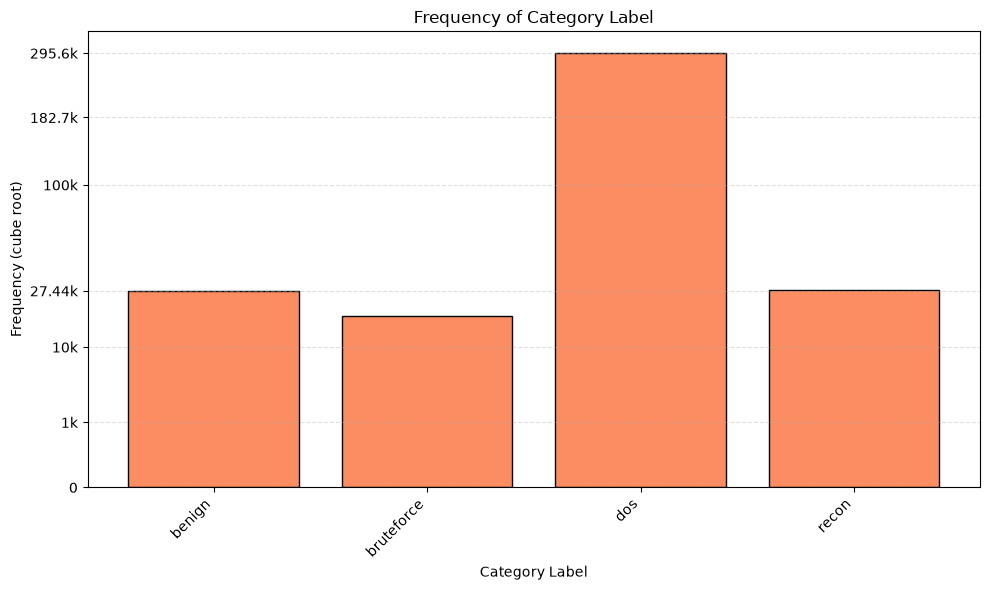

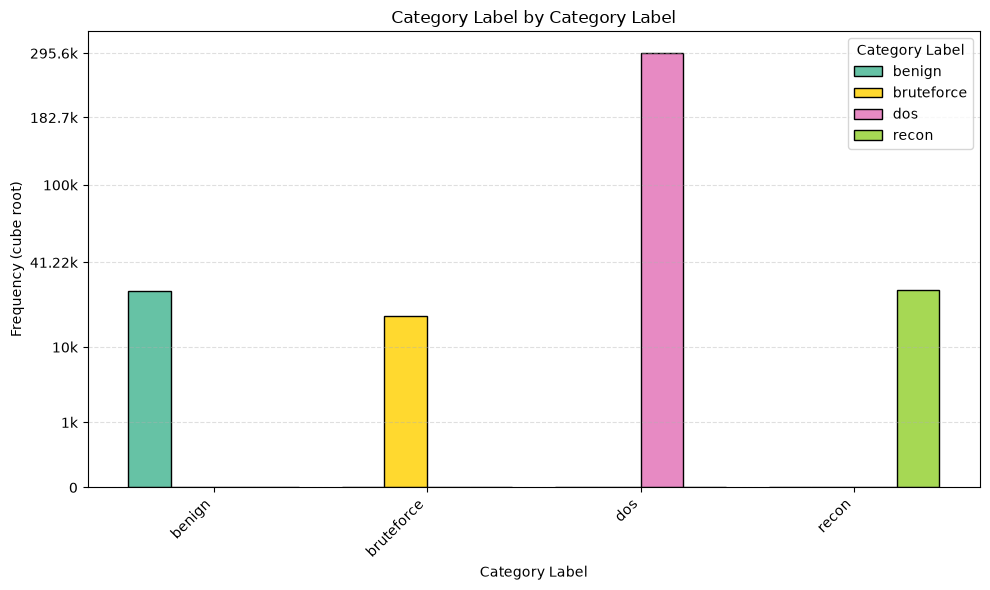

In [6]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("category_label"),
)

,name,label,semantic_type,role,description
0,Destination Port Category,destination_port_category,categorical,predictor,Semantic category assigned to the destination ...


,category,count,frequency
0,not_applicable,69757,0.189271
1,well_known,3874,0.010511
2,ftp,3373,0.009152
3,ssh,4775,0.012956
4,dns,16856,0.045735
5,http,231036,0.626868
6,netbios,441,0.001197
7,https,6238,0.016926
8,smb,10029,0.027212
9,smtps,40,0.000109


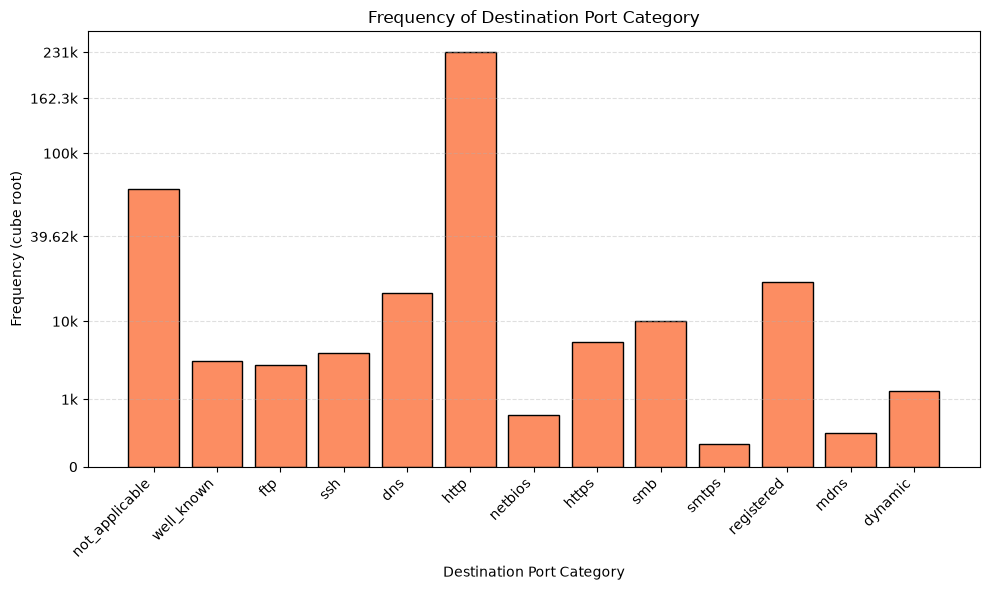

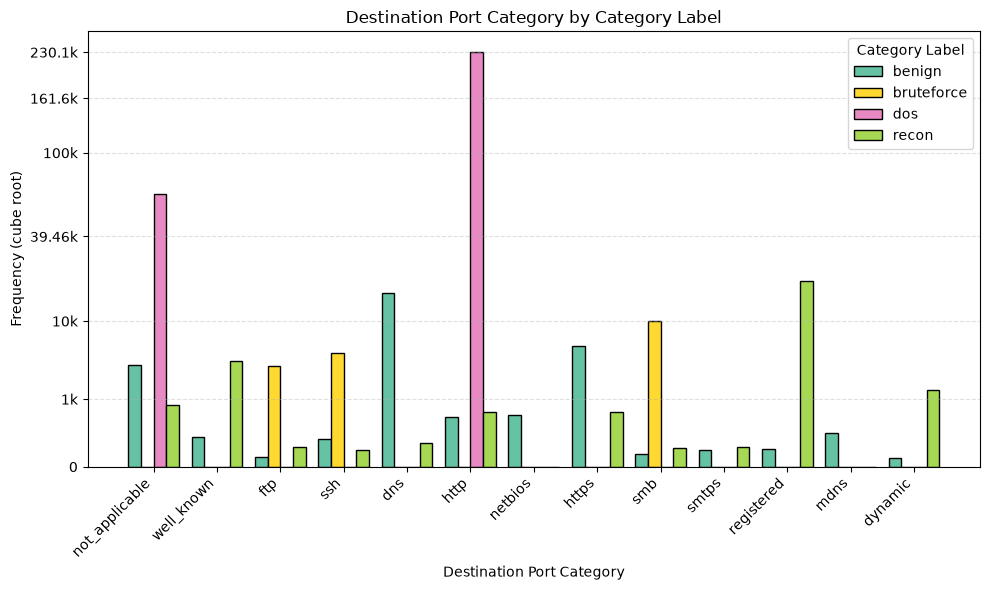

In [7]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_port_category"),
)

,name,label,semantic_type,role,description
0,SYN-ACK Time,syn_ack_time,numeric,predictor,TCP connection setup time between the SYN and ...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 3.11495]"
3,minimum,0.0
4,maximum,3.114945
5,mean,0.000431
6,standard_deviation,0.008254
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


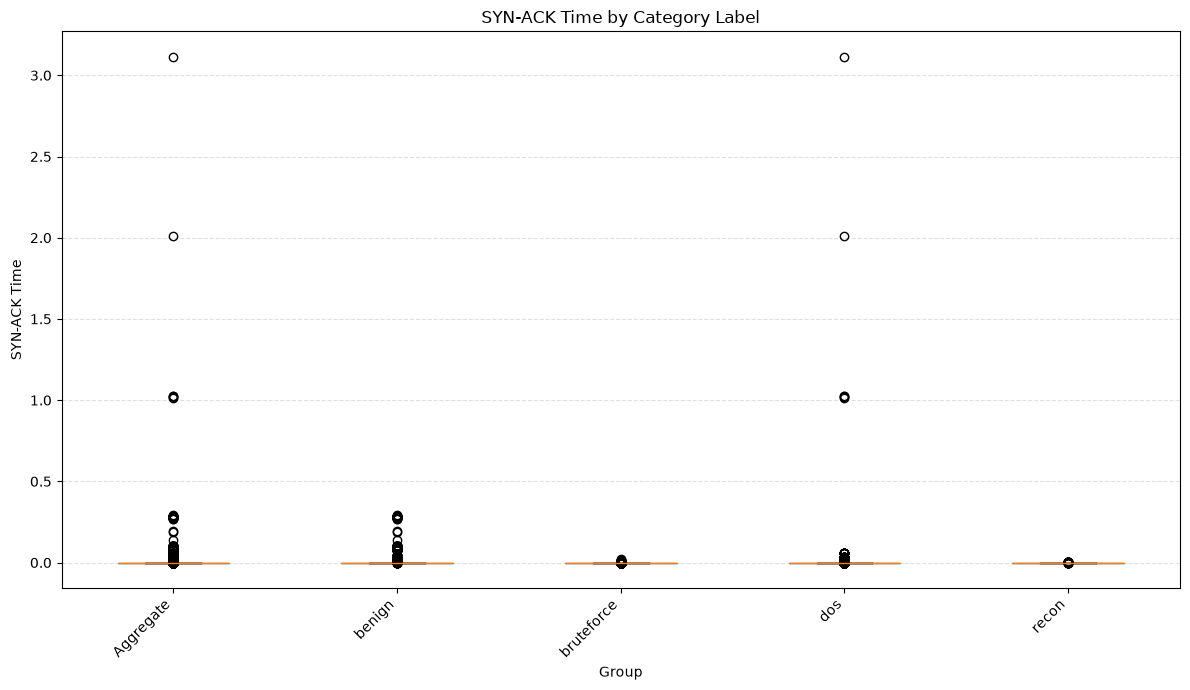

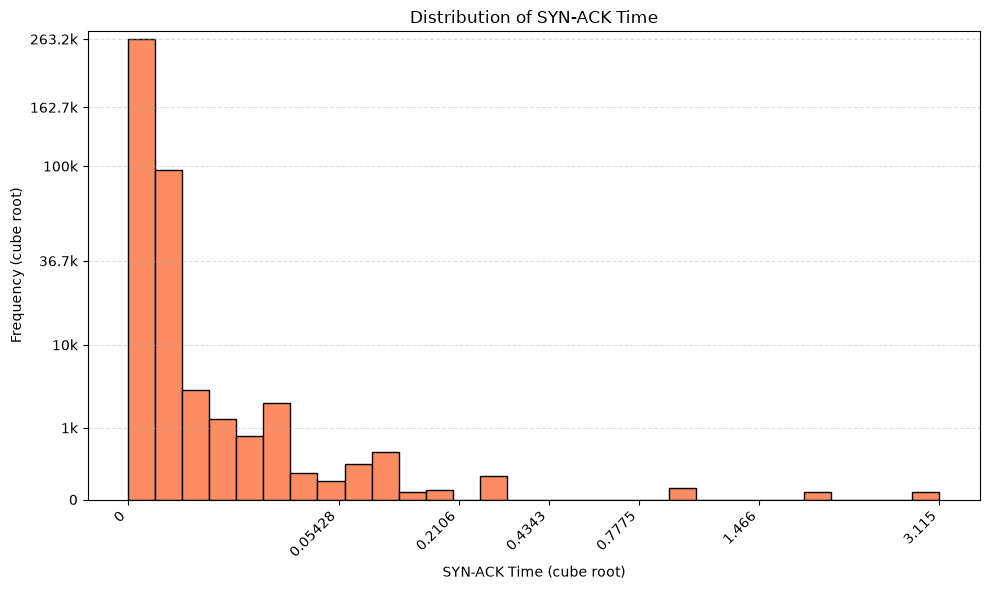

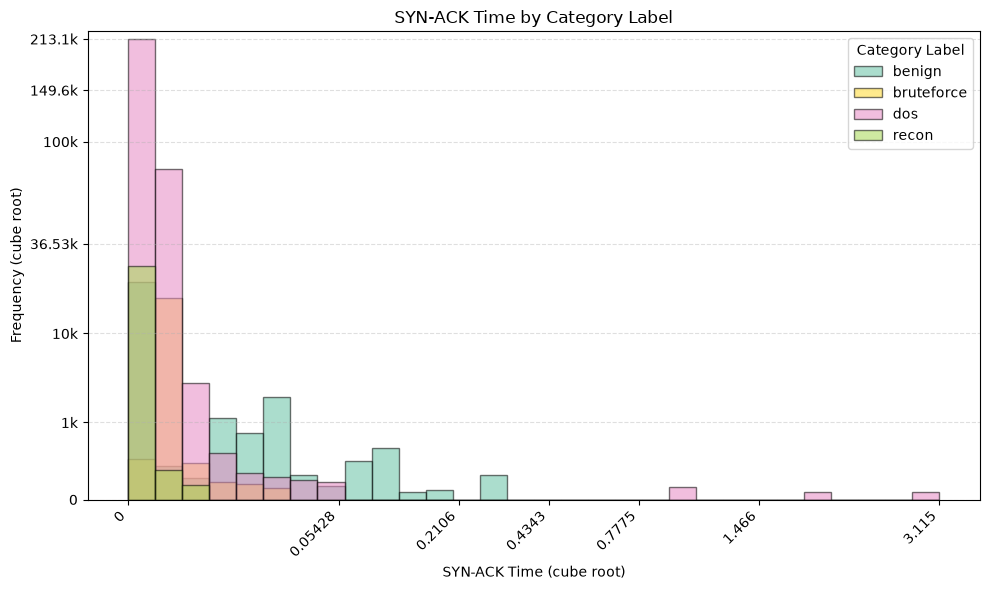

In [8]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("syn_ack_time"),
)

,name,label,semantic_type,role,description
0,Maximum Duration,maximum_duration,numeric,predictor,Maximum duration among the aggregated records.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 59.9993]"
3,minimum,0.0
4,maximum,59.999279
5,mean,40.15565
6,standard_deviation,26.030945
7,percentile_05,0.0
8,percentile_25,5.415242
9,percentile_50,59.357697


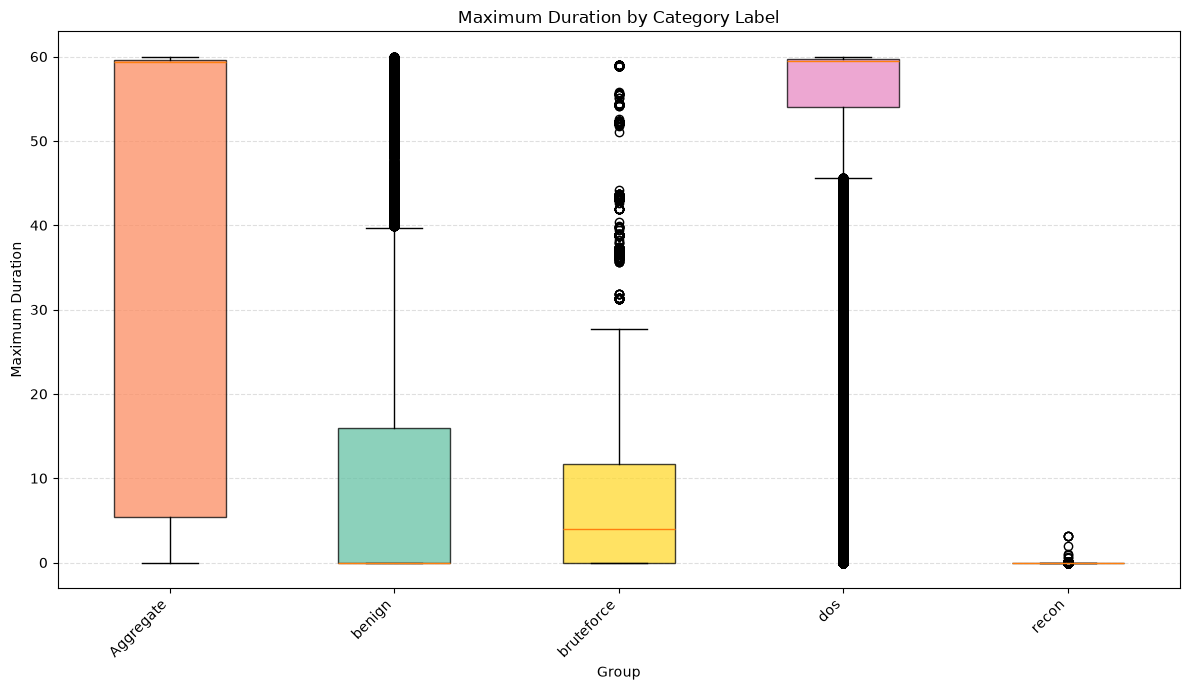

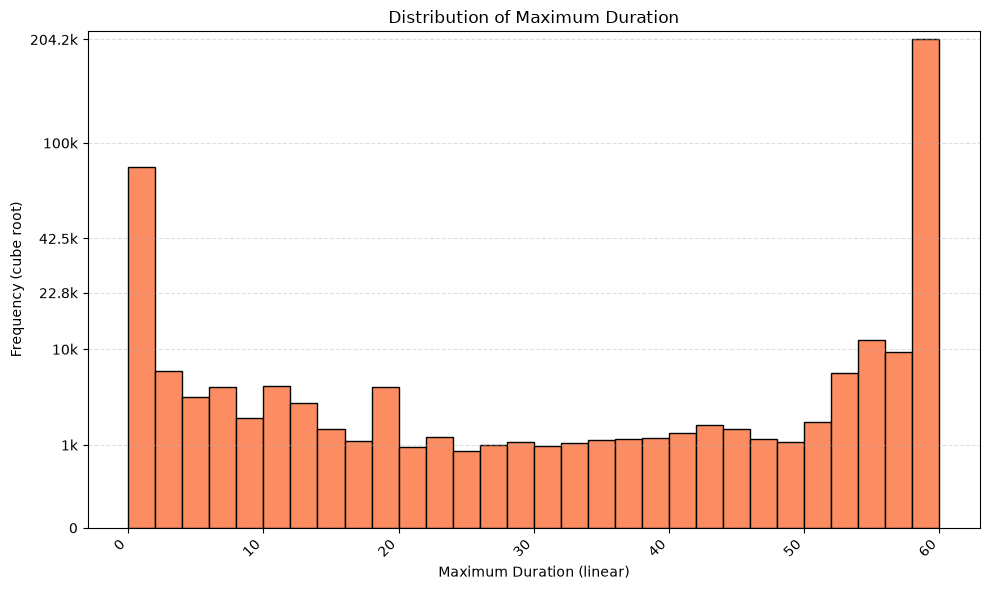

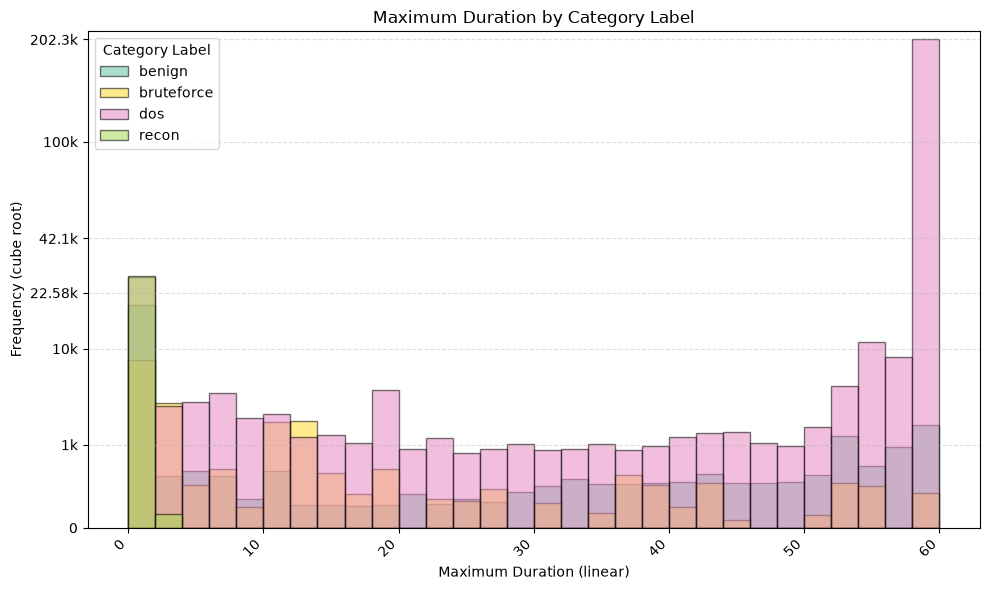

In [9]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("maximum_duration"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Source Hops,source_hops,numeric,predictor,Estimated number of IP hops from the source to...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 27]"
3,minimum,0.0
4,maximum,27.0
5,mean,1.198065
6,standard_deviation,4.582523
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


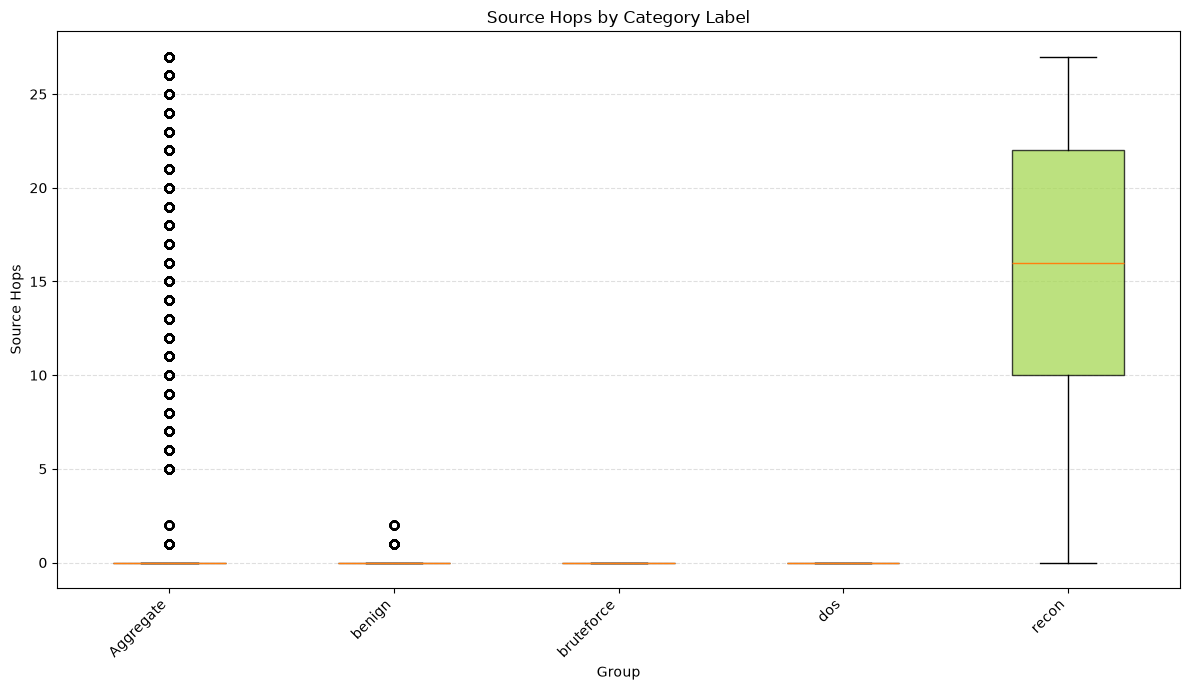

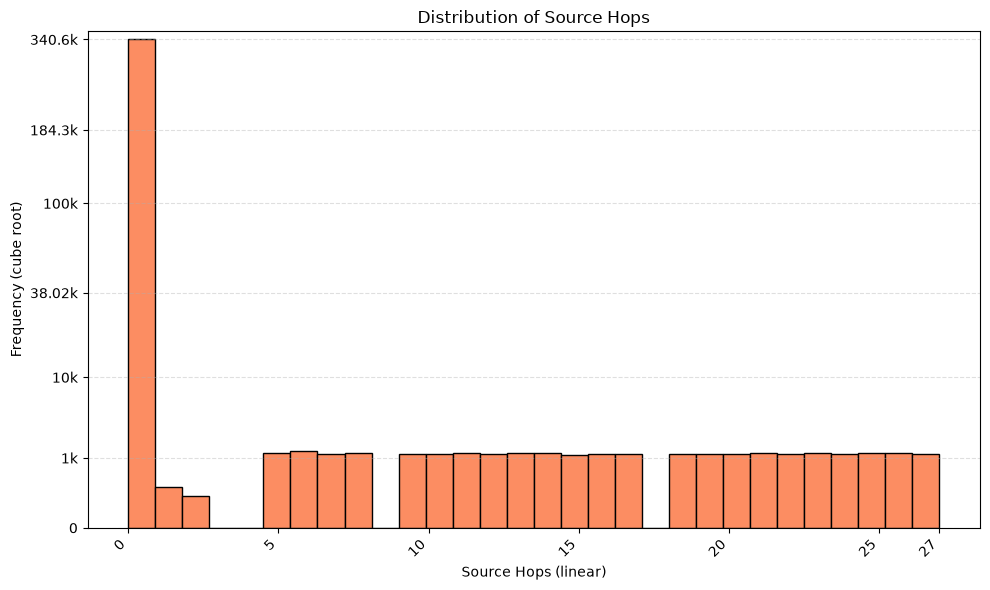

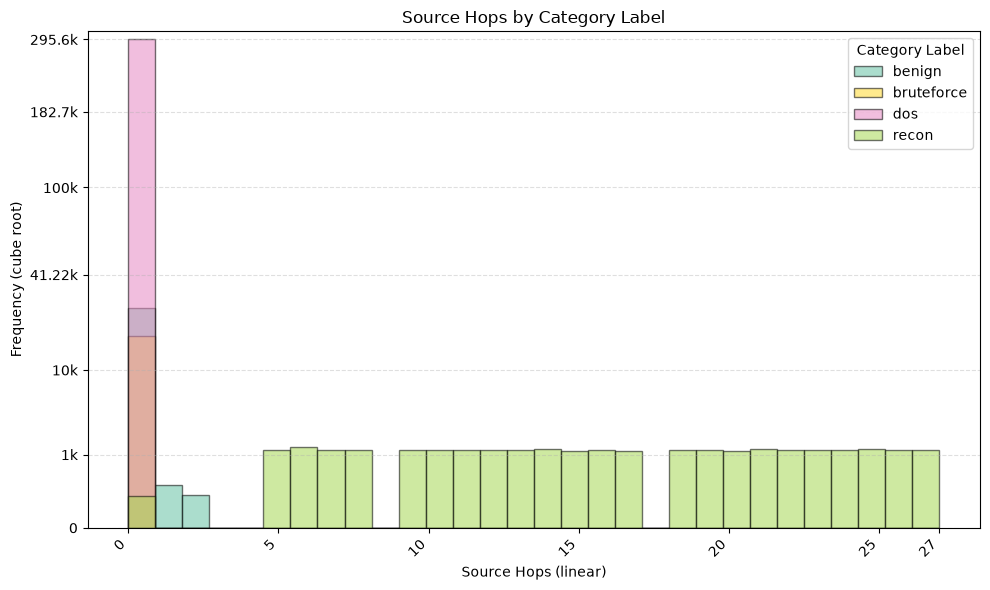

In [10]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_hops"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,TCP Round-Trip Time,tcp_rtt,numeric,predictor,"TCP connection setup round-trip time, equal to..."


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 3.11516]"
3,minimum,0.0
4,maximum,3.115158
5,mean,0.000452
6,standard_deviation,0.008259
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


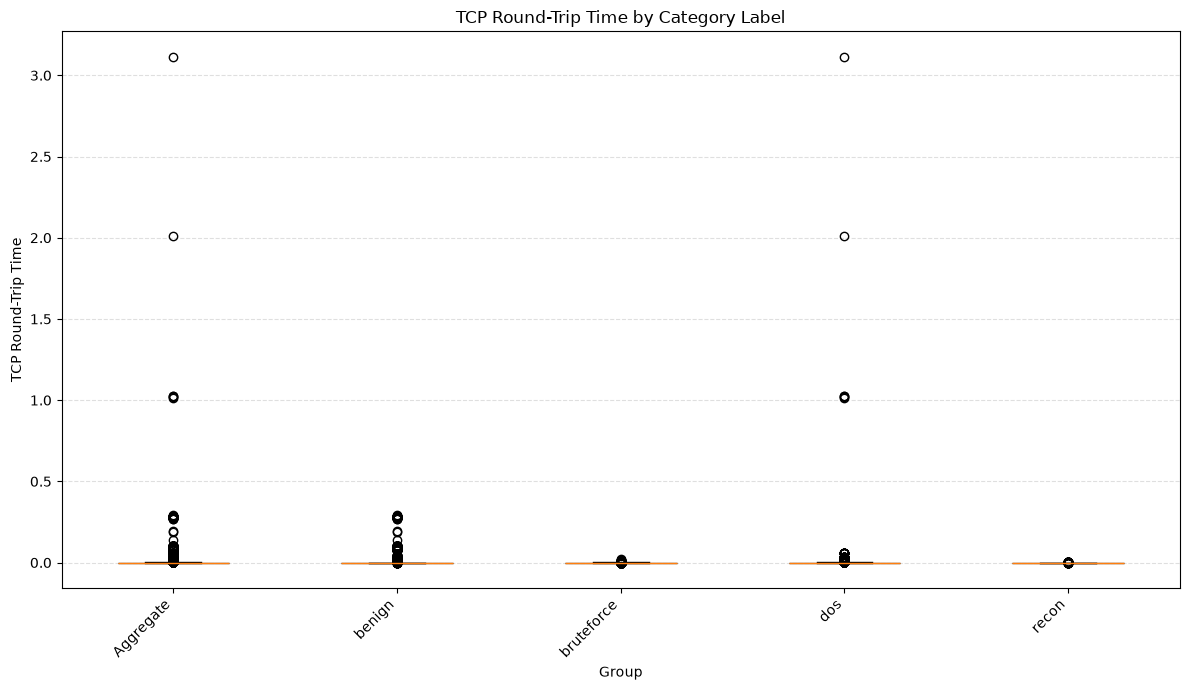

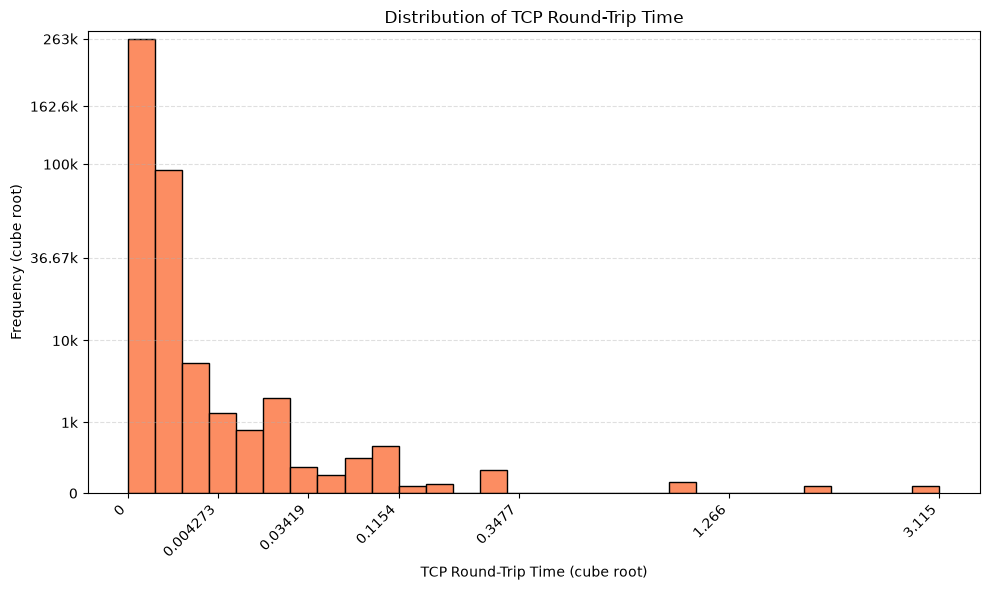

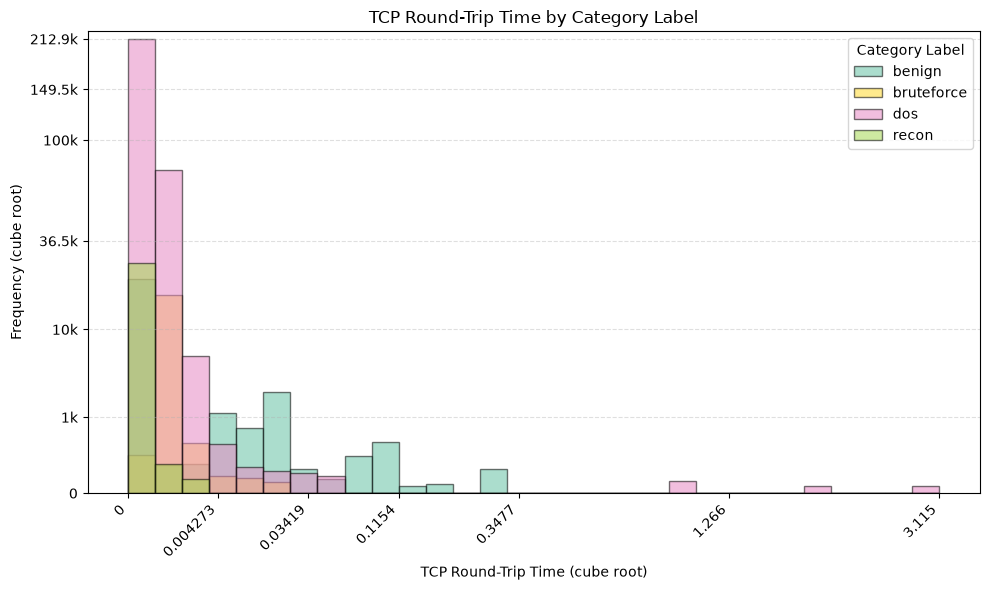

In [11]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("tcp_rtt"),
)

,name,label,semantic_type,role,description
0,Minimum Destination Inter-Packet Time,destination_interpacket_time_minimum,numeric,predictor,Minimum destination inter-packet arrival time ...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118160]"
3,minimum,0.0
4,maximum,118160.208
5,mean,240.183776
6,standard_deviation,2949.289735
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


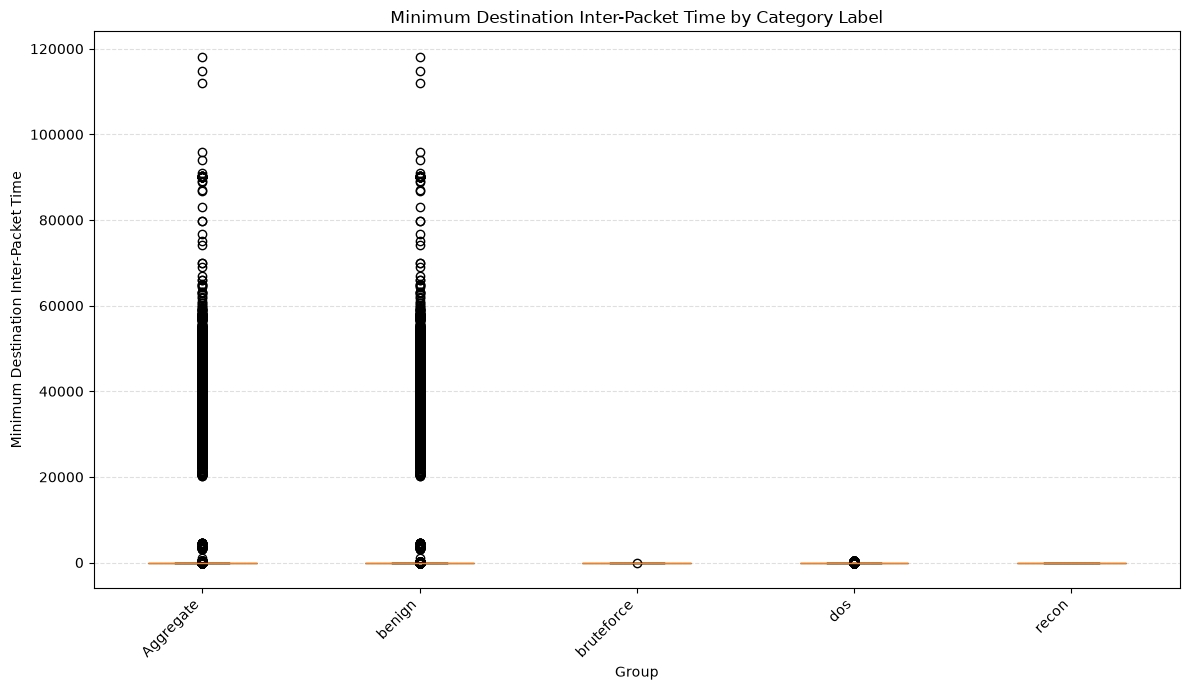

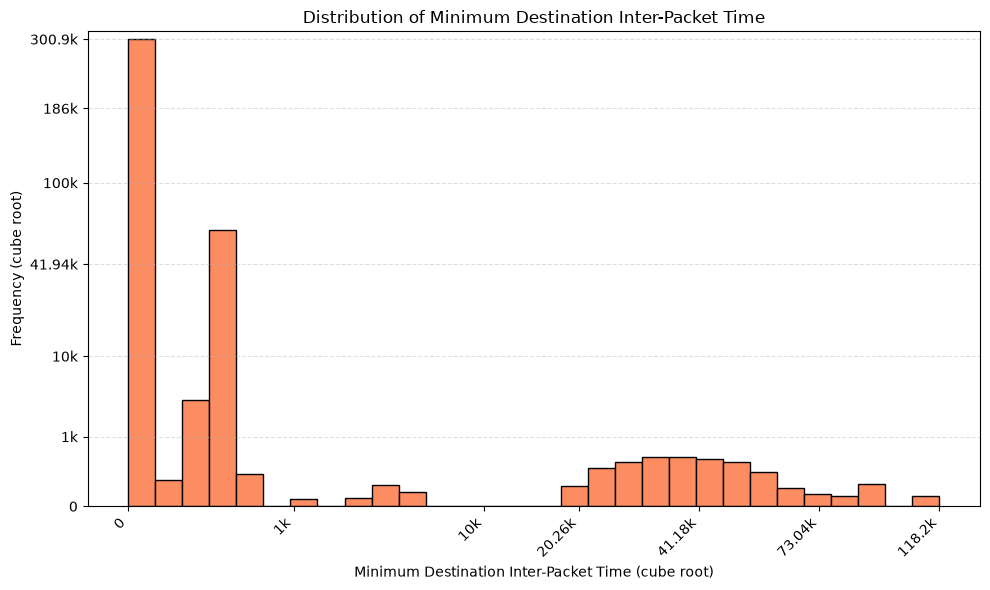

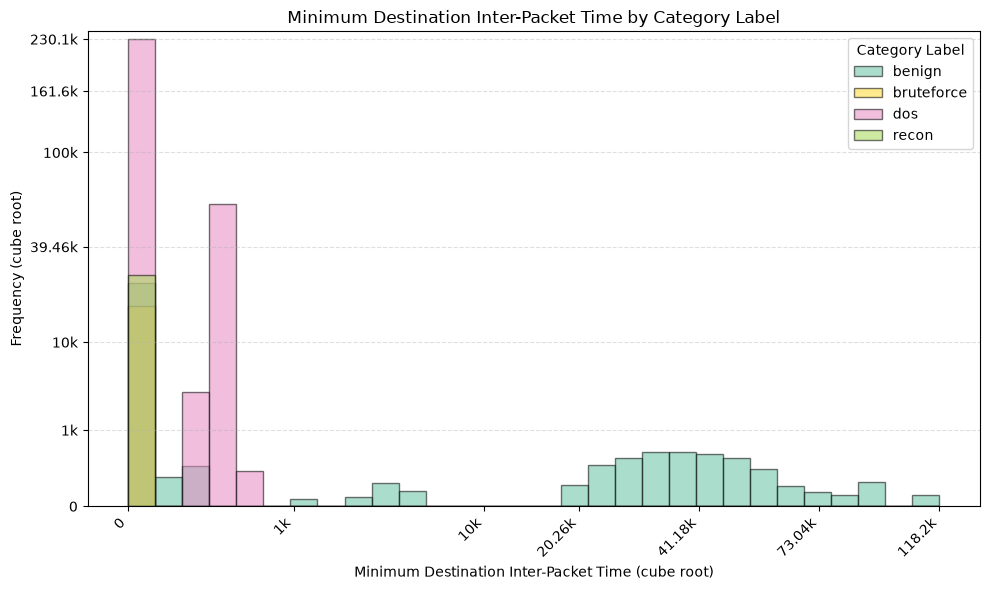

In [12]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_interpacket_time_minimum")
)

,name,label,semantic_type,role,description
0,Mean Duration,mean_duration,numeric,predictor,Average duration of the aggregated records.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 59.9993]"
3,minimum,0.0
4,maximum,59.999279
5,mean,40.15565
6,standard_deviation,26.030945
7,percentile_05,0.0
8,percentile_25,5.415242
9,percentile_50,59.357697


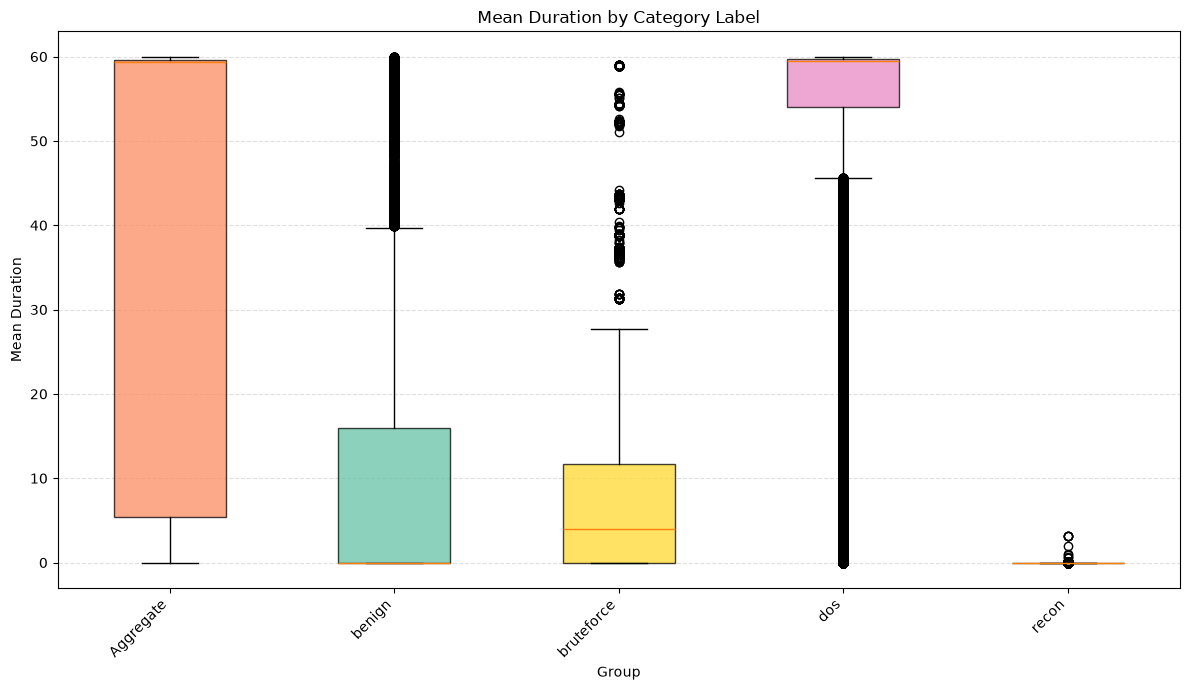

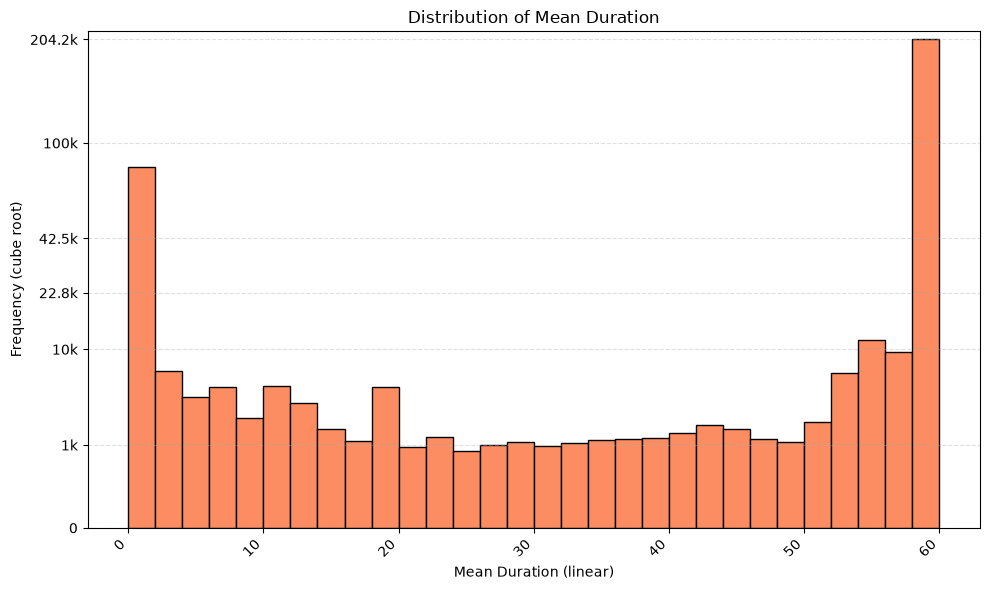

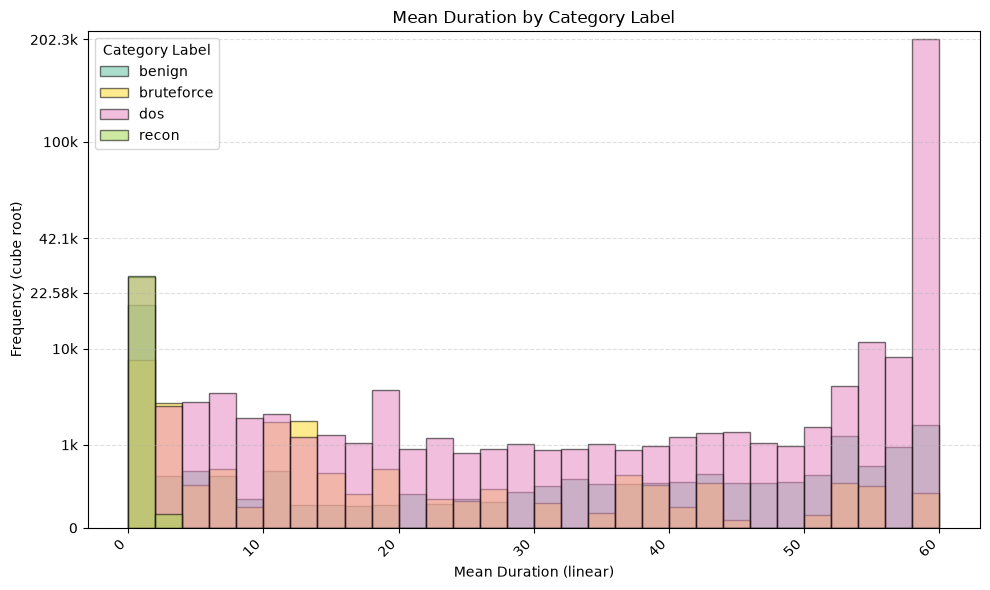

In [13]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("mean_duration"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Destination Packets,amount_of_destination_packets,numeric,predictor,Number of packets transmitted from destination...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 29039]"
3,minimum,0.0
4,maximum,29039.0
5,mean,25.963126
6,standard_deviation,77.647097
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,5.0


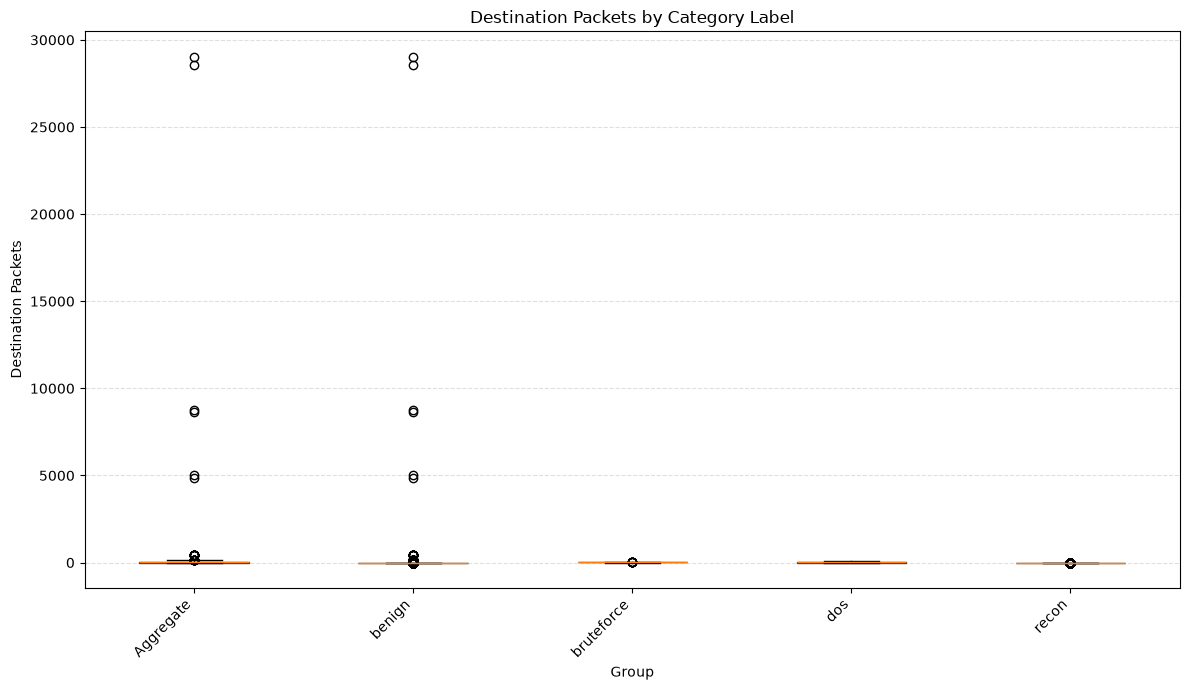

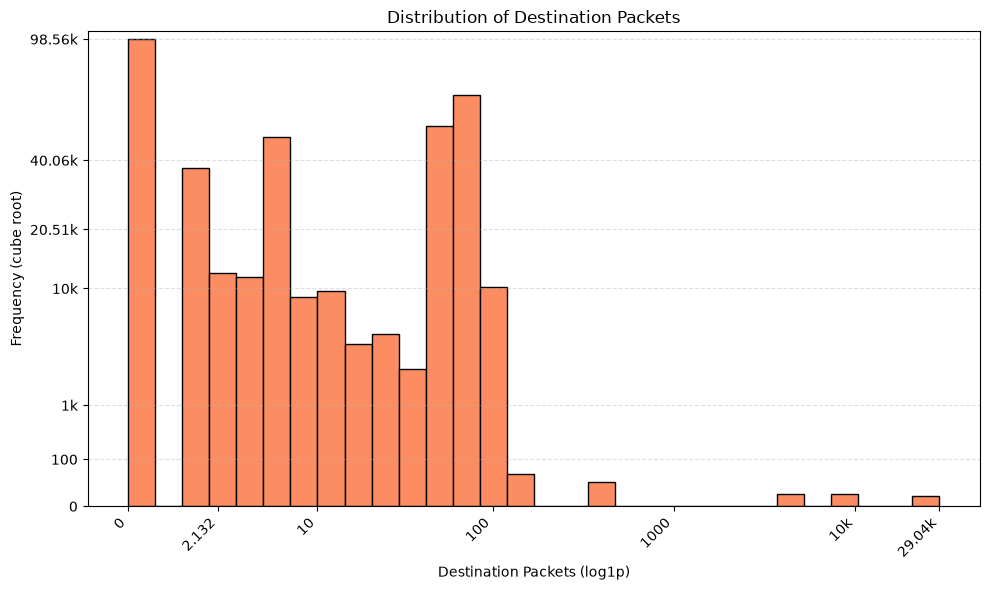

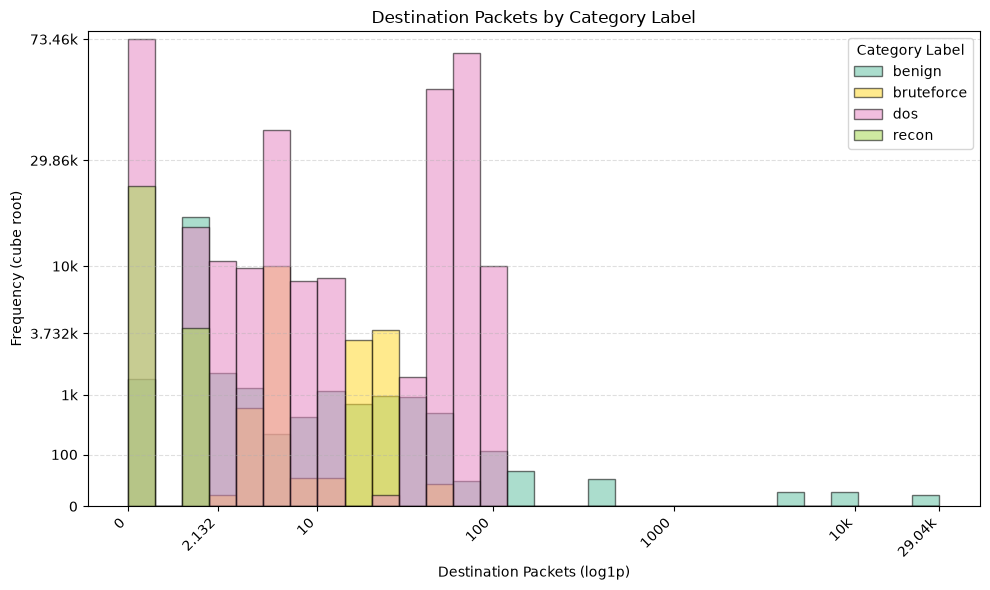

In [14]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("amount_of_destination_packets"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Source TTL,source_ttl,numeric,predictor,Source-to-destination TTL value.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 255]"
3,minimum,0.0
4,maximum,255.0
5,mean,62.39976
6,standard_deviation,9.04876
7,percentile_05,49.0
8,percentile_25,64.0
9,percentile_50,64.0


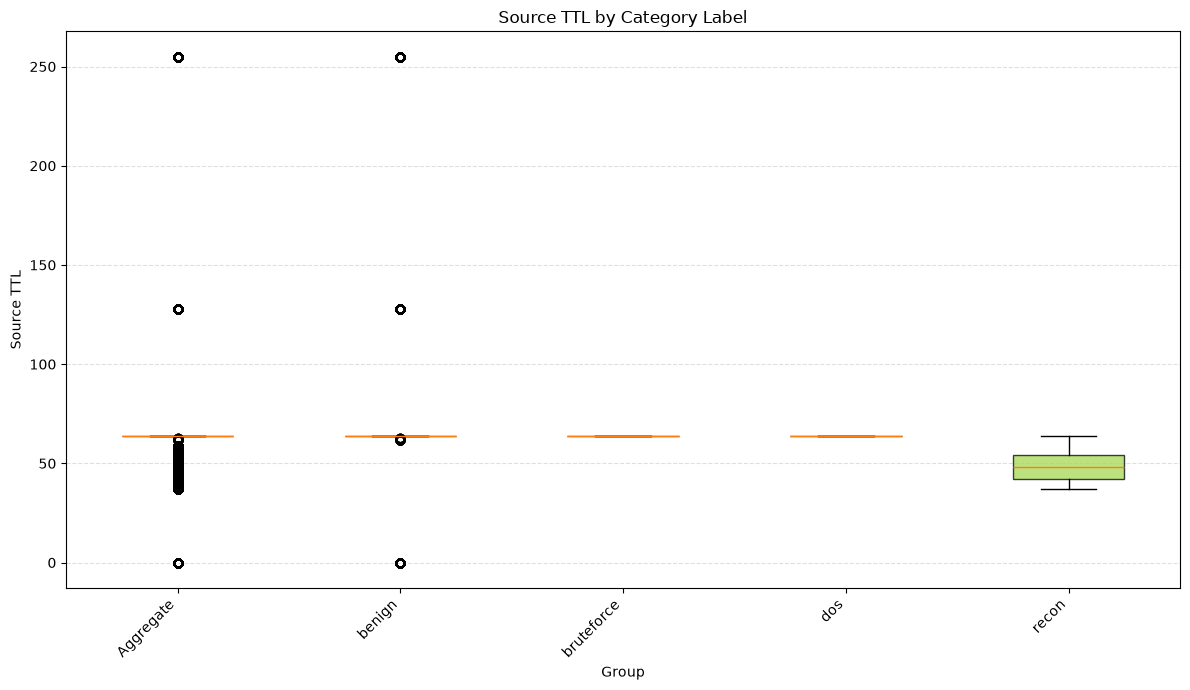

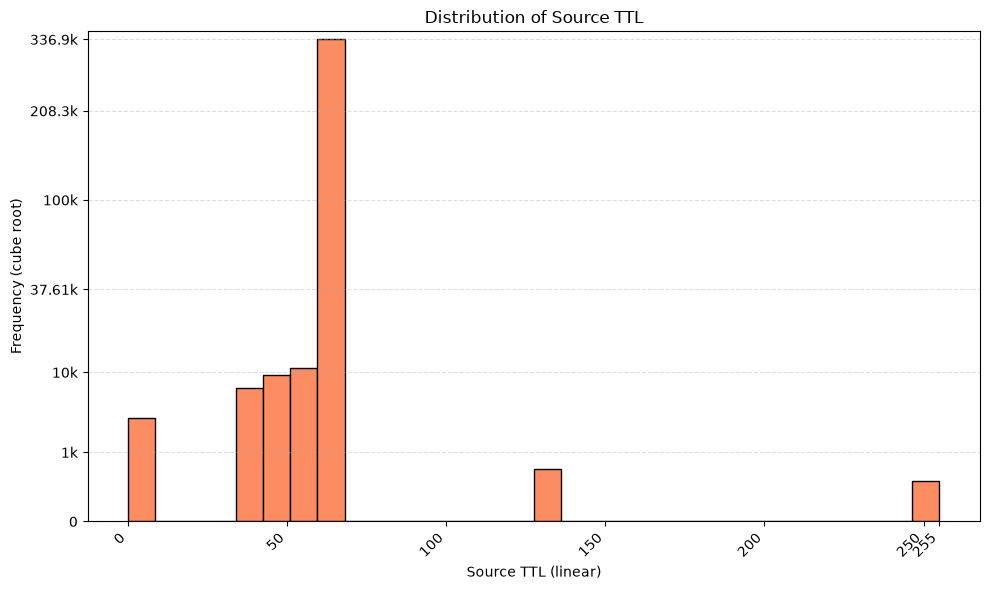

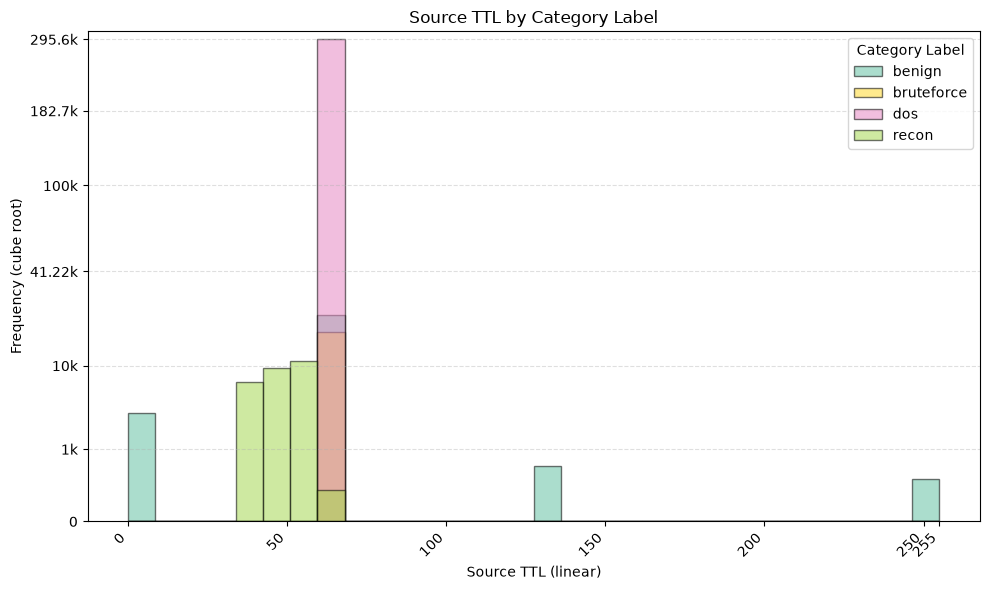

In [15]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_ttl"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Source Port Category,source_port_category,categorical,predictor,Semantic category assigned to the source port ...


,category,count,frequency
0,not_applicable,69685,0.189076
1,well_known,2033,0.005516
2,http,98,0.000266
3,netbios,445,0.001207
4,registered,183731,0.498516
5,mdns,130,0.000353
6,dynamic,112434,0.305066


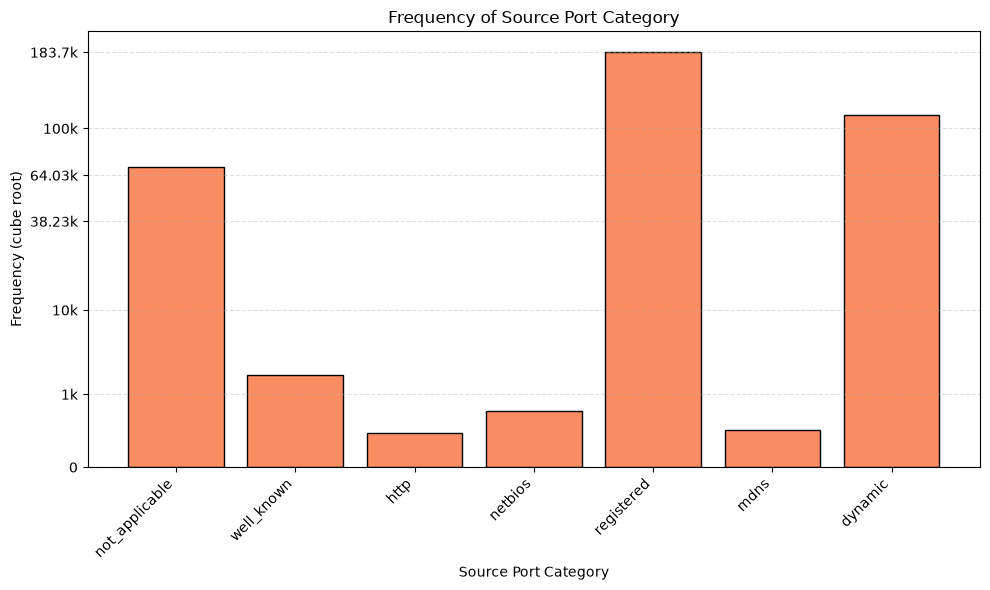

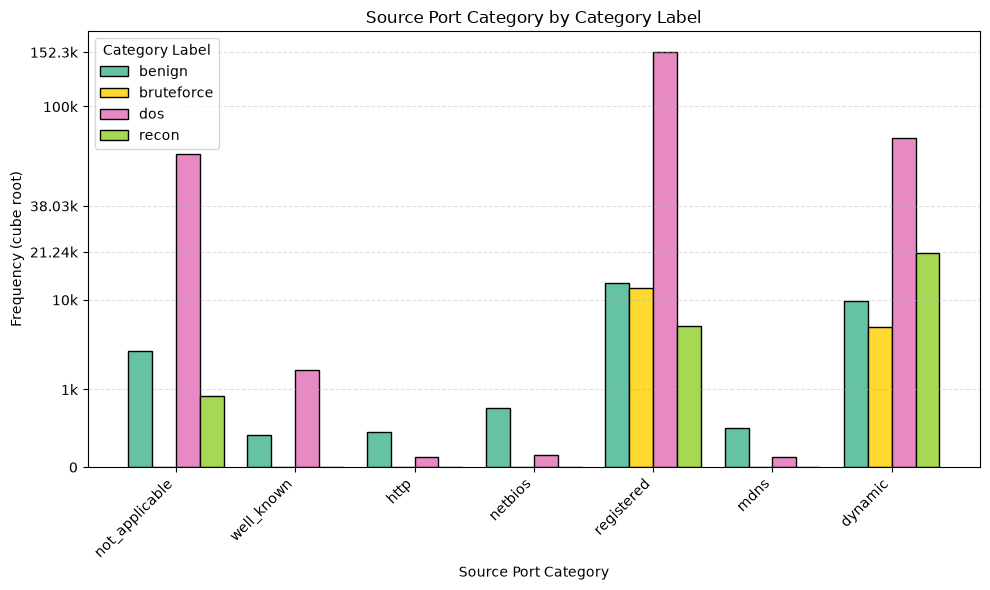

In [16]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_port_category"),
)

,name,label,semantic_type,role,description
0,Total Bytes,total_bytes,numeric,predictor,Total number of transaction bytes.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[60, 8.09804e+07]"
3,minimum,60.0
4,maximum,80980442.0
5,mean,7428.803826
6,standard_deviation,201925.272209
7,percentile_05,60.0
8,percentile_25,1244.0
9,percentile_50,9120.0


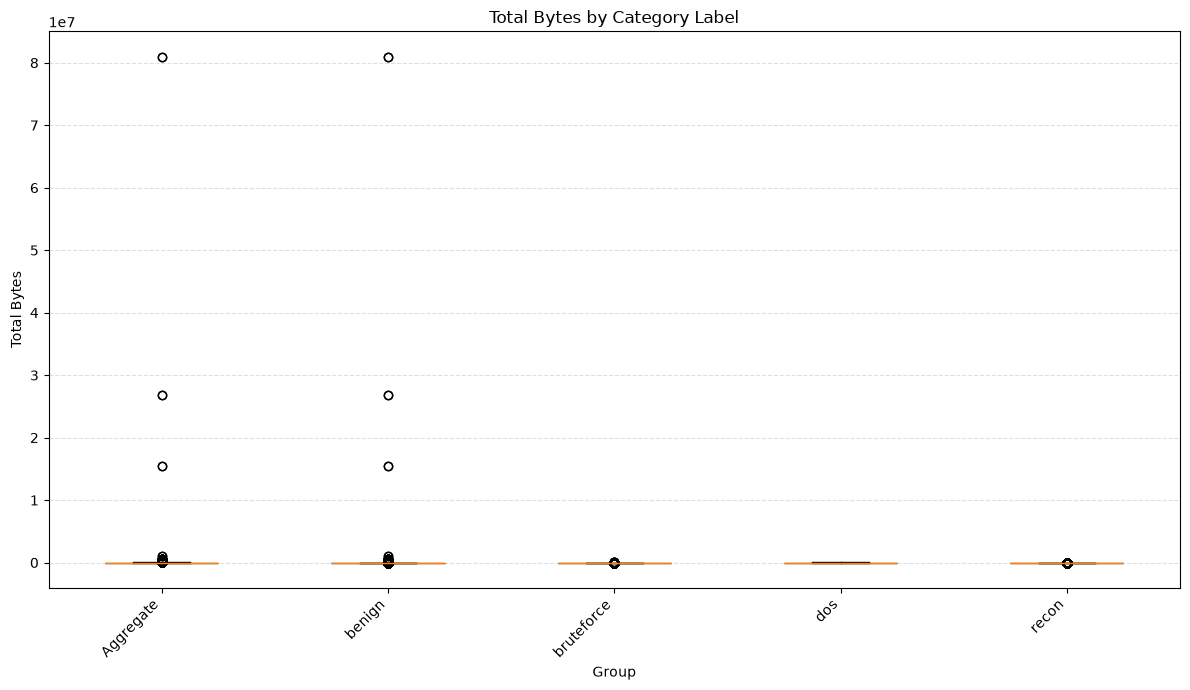

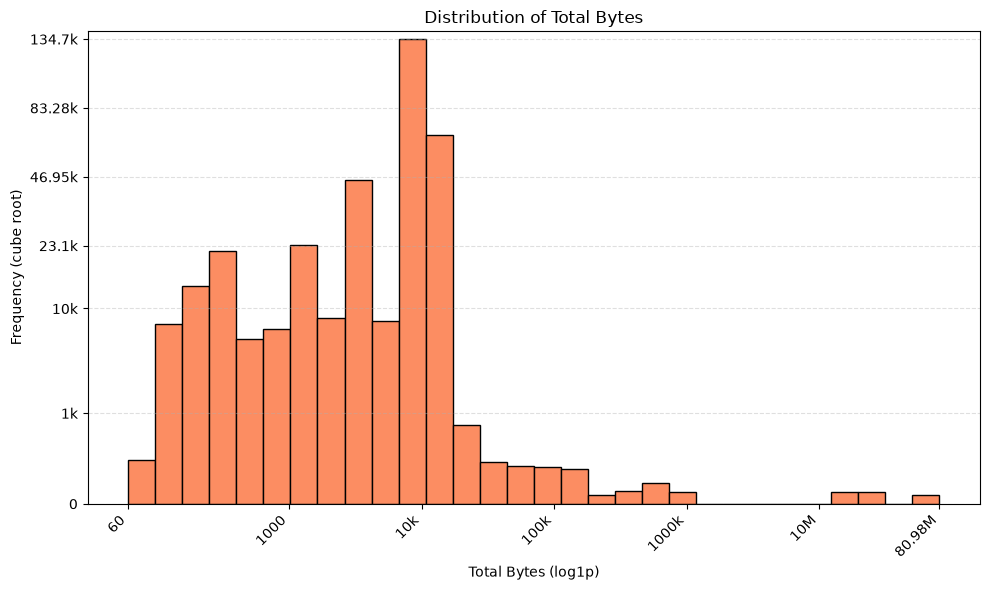

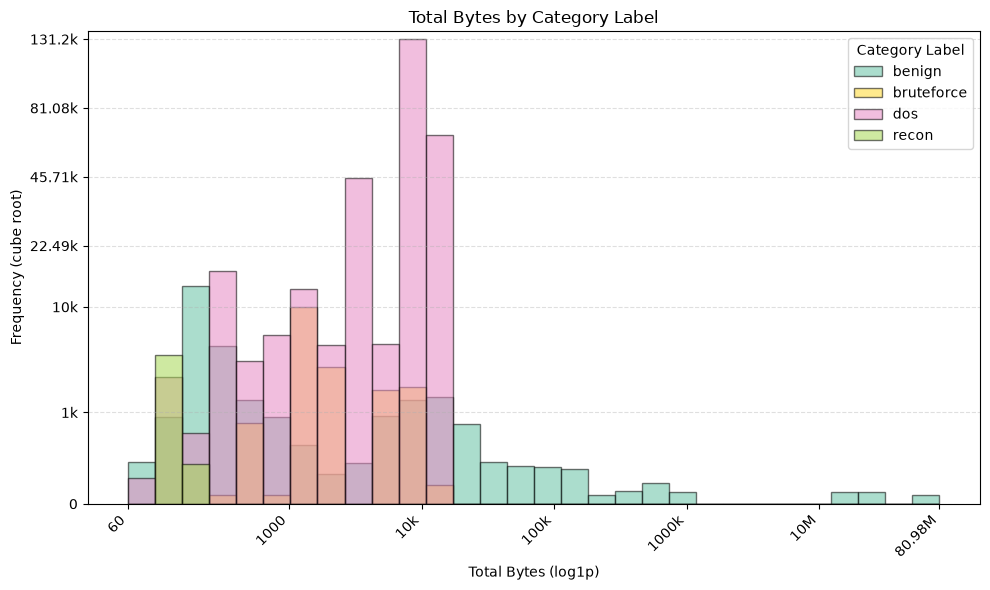

In [17]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("total_bytes"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Active Destination Inter-Packet Time,destination_interpacket_time_active,numeric,predictor,Destination active inter-packet arrival time i...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118160]"
3,minimum,0.0
4,maximum,118160.208
5,mean,350.272971
6,standard_deviation,3019.702366
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


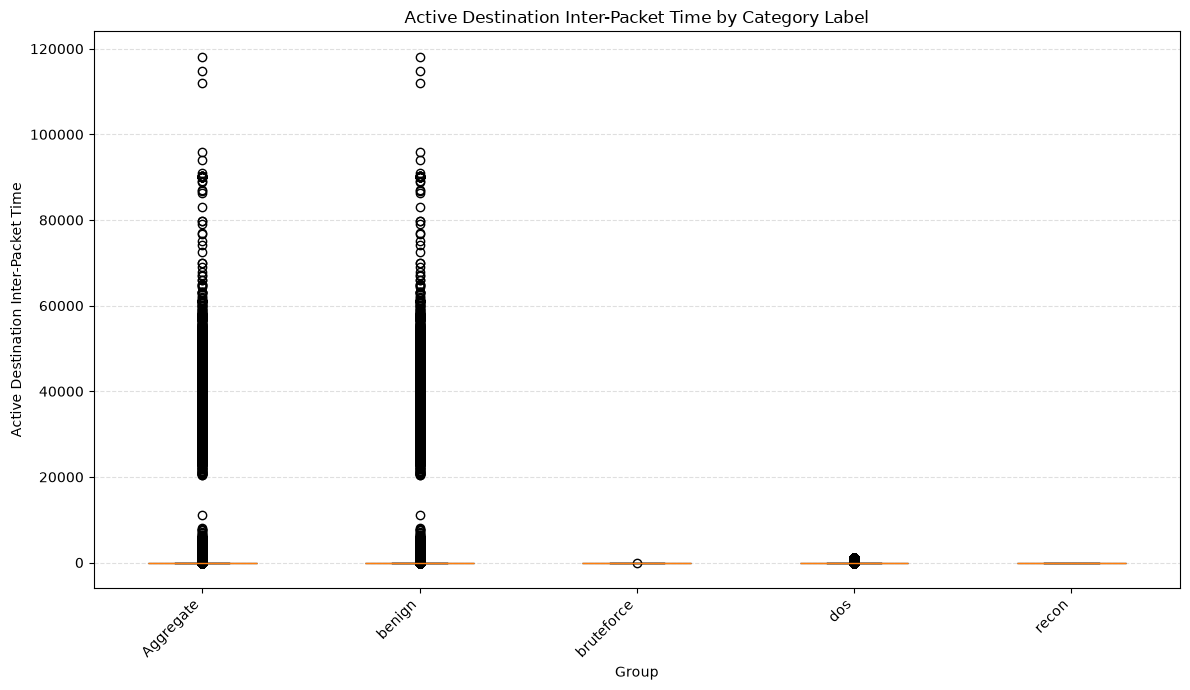

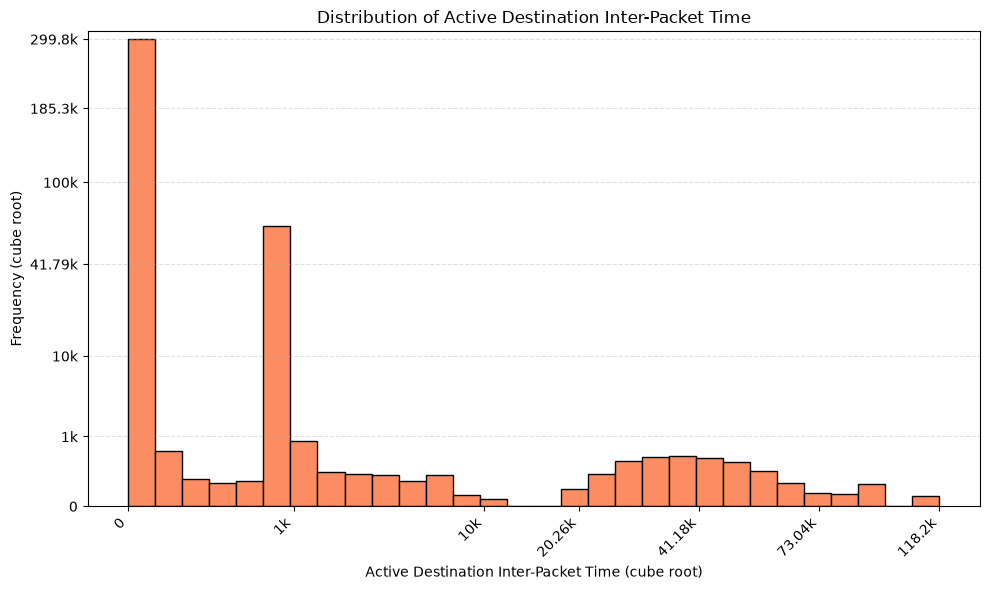

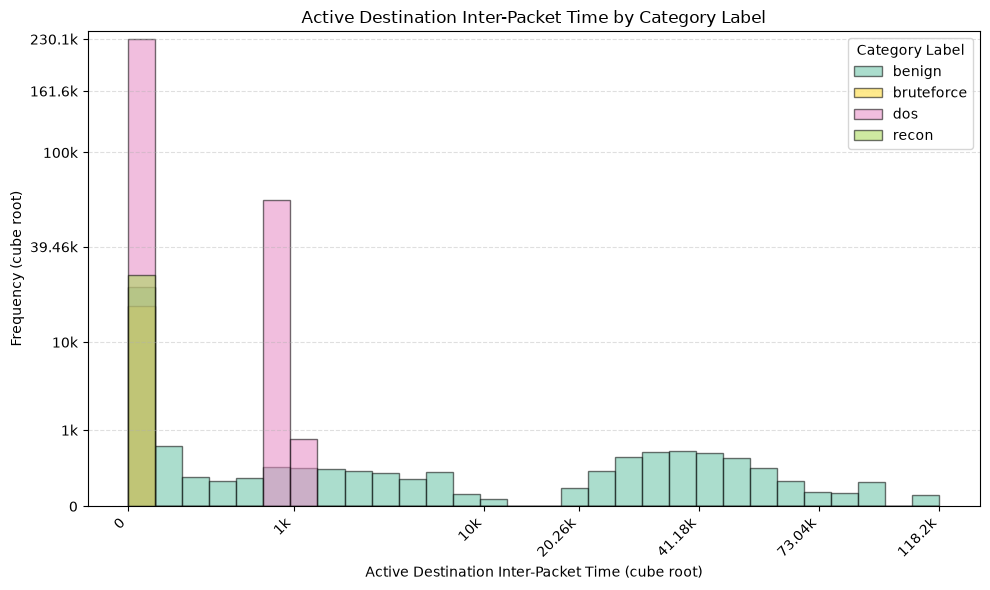

In [18]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_interpacket_time_active")
)

,name,label,semantic_type,role,description
0,Destination Loss,amount_of_destination_package_loss,numeric,predictor,Destination packets retransmitted or dropped.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 2023]"
3,minimum,0.0
4,maximum,2023.0
5,mean,0.187282
6,standard_deviation,4.638914
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


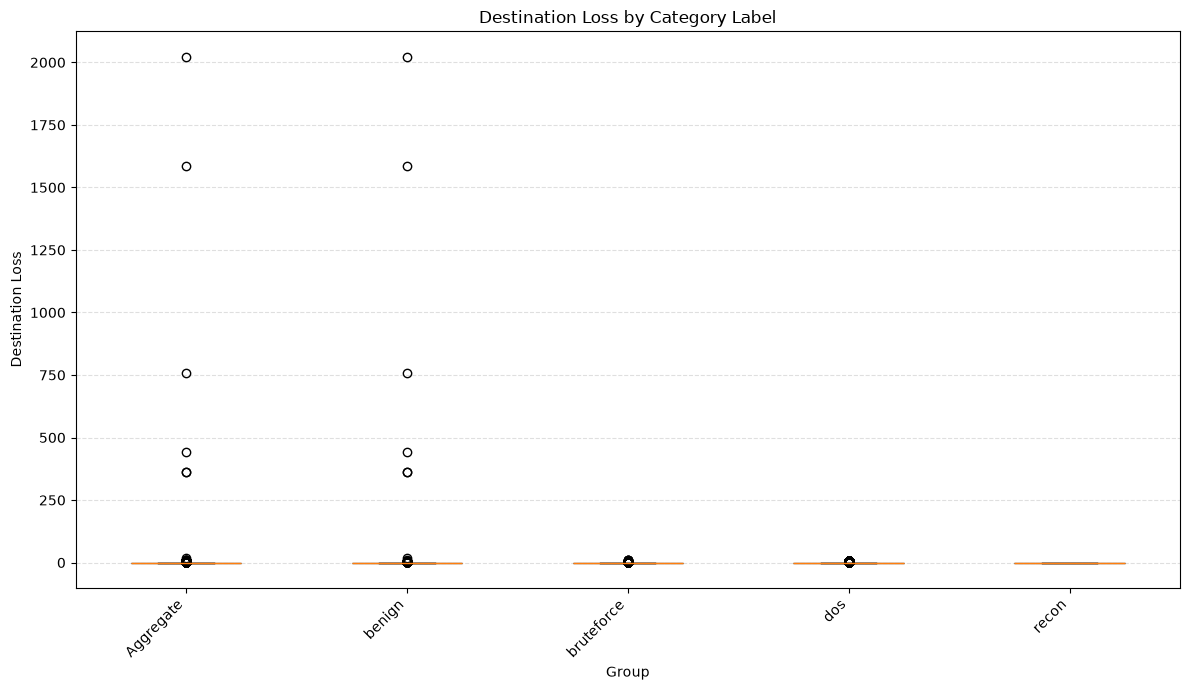

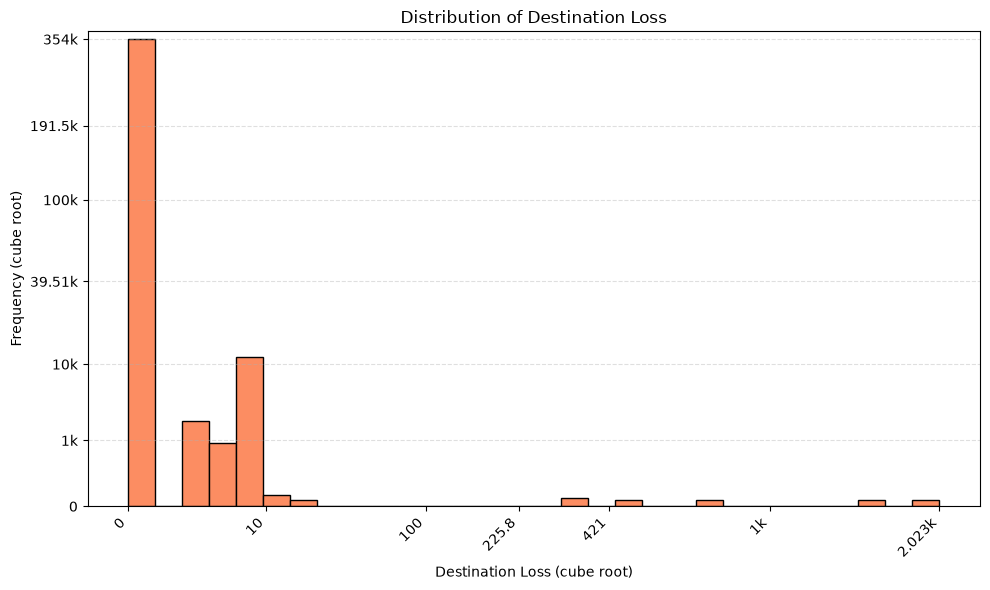

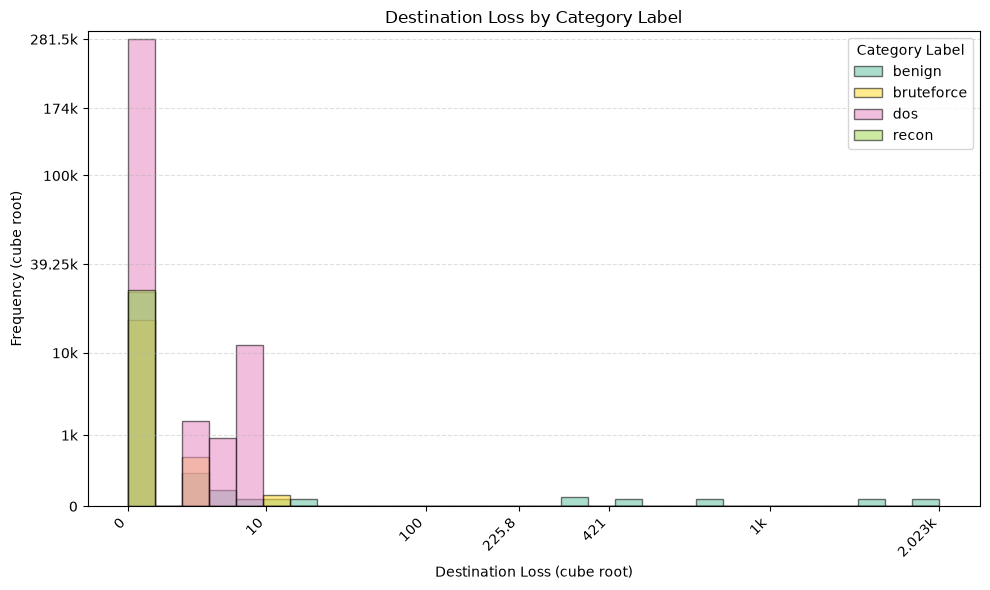

In [19]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("amount_of_destination_package_loss")
)

,name,label,semantic_type,role,description
0,Source TCP Window,source_window_in_bytes,numeric,predictor,Source TCP window advertisement.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 8.22272e+06]"
3,minimum,0.0
4,maximum,8222720.0
5,mean,196663.916884
6,standard_deviation,1188088.387273
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,512.0


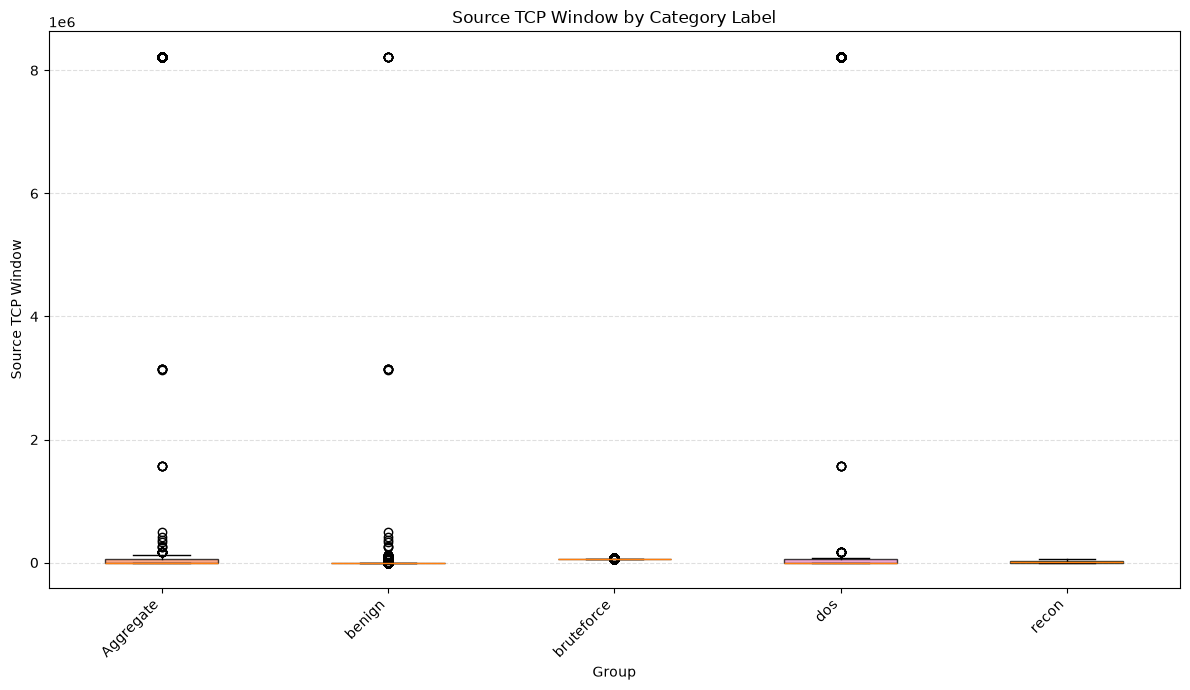

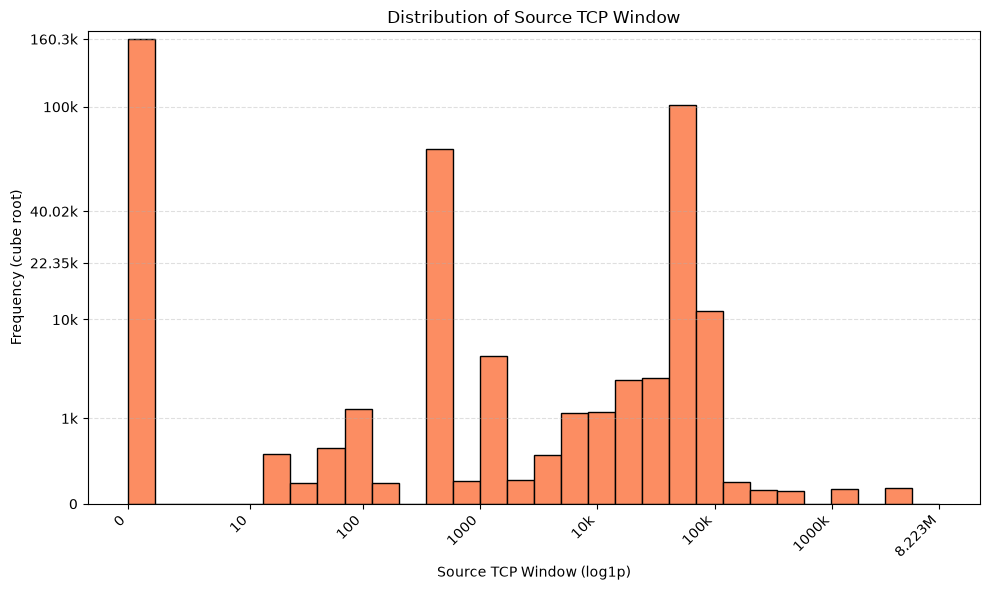

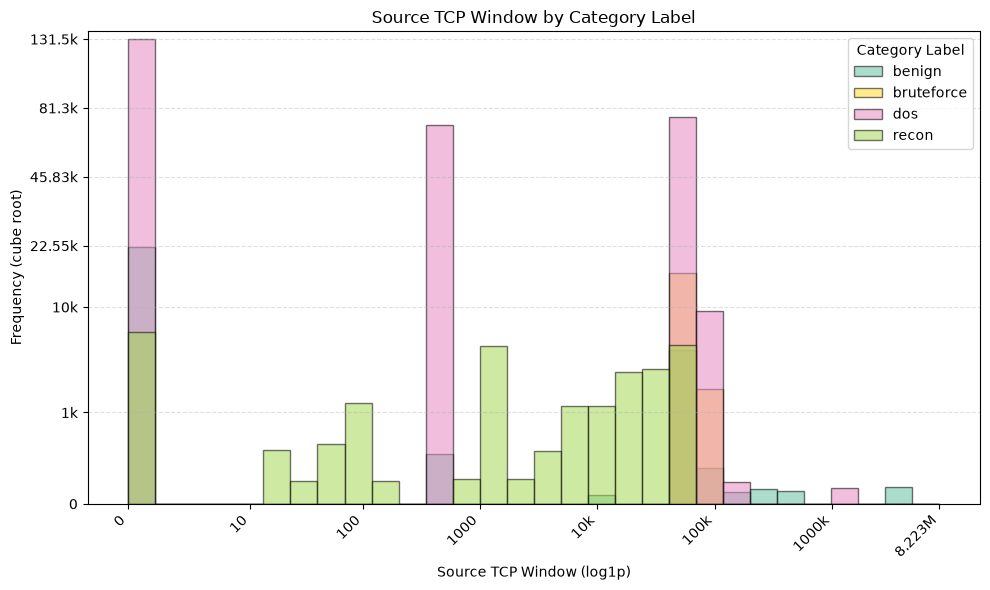

In [20]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_window_in_bytes"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Source Application Bytes,source_application_bytes,numeric,predictor,Application bytes transmitted from source to d...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 22845]"
3,minimum,0.0
4,maximum,22845.0
5,mean,514.352218
6,standard_deviation,1067.674572
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,51.0


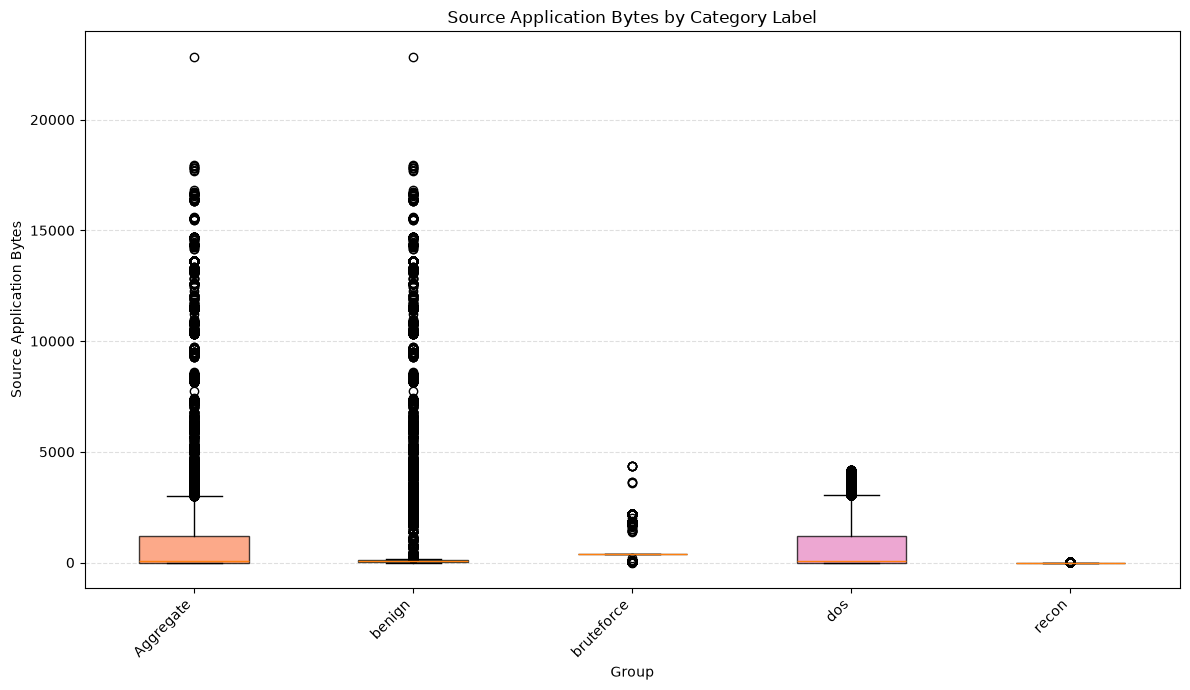

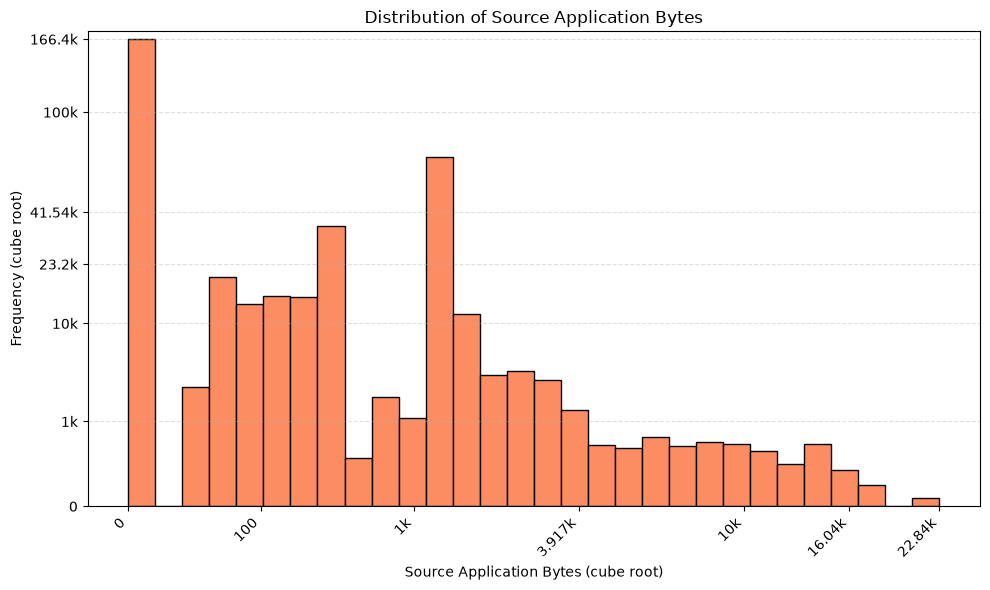

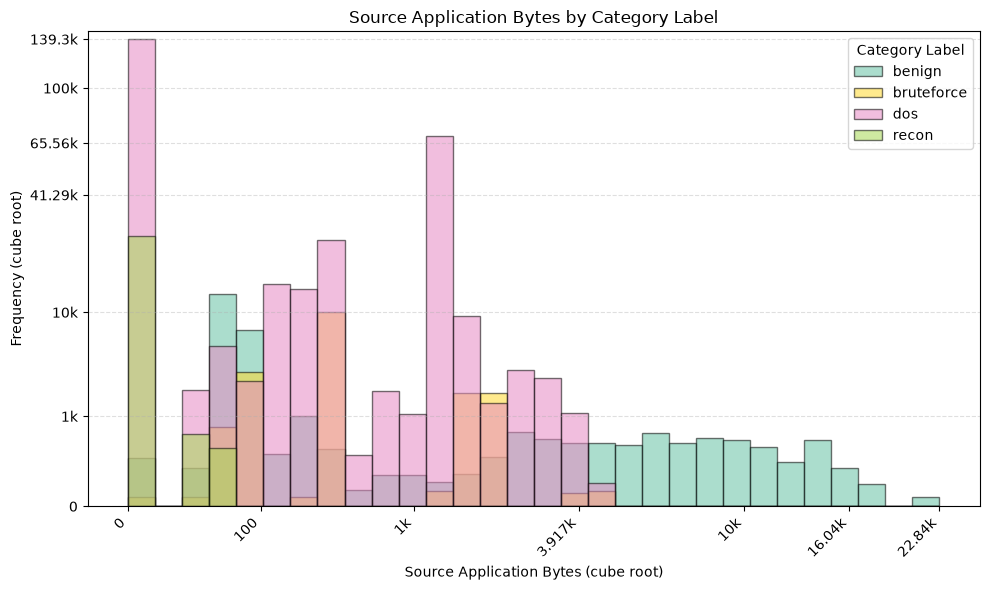

In [21]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_application_bytes"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("packet_rate"),
)

,name,label,semantic_type,role,description
0,Packet Rate,packet_rate,numeric,predictor,Number of packets transmitted per second.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 333333]"
3,minimum,0.0
4,maximum,333333.3125
5,mean,299.185928
6,standard_deviation,1832.614149
7,percentile_05,0.0
8,percentile_25,1.053867
9,percentile_50,2.591856


,name,label,semantic_type,role,description
0,Destination Bytes,destination_bytes,numeric,predictor,Bytes transmitted from destination to source.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 7.91914e+07]"
3,minimum,0.0
4,maximum,79191398.0
5,mean,2534.123691
6,standard_deviation,197655.431435
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,660.0


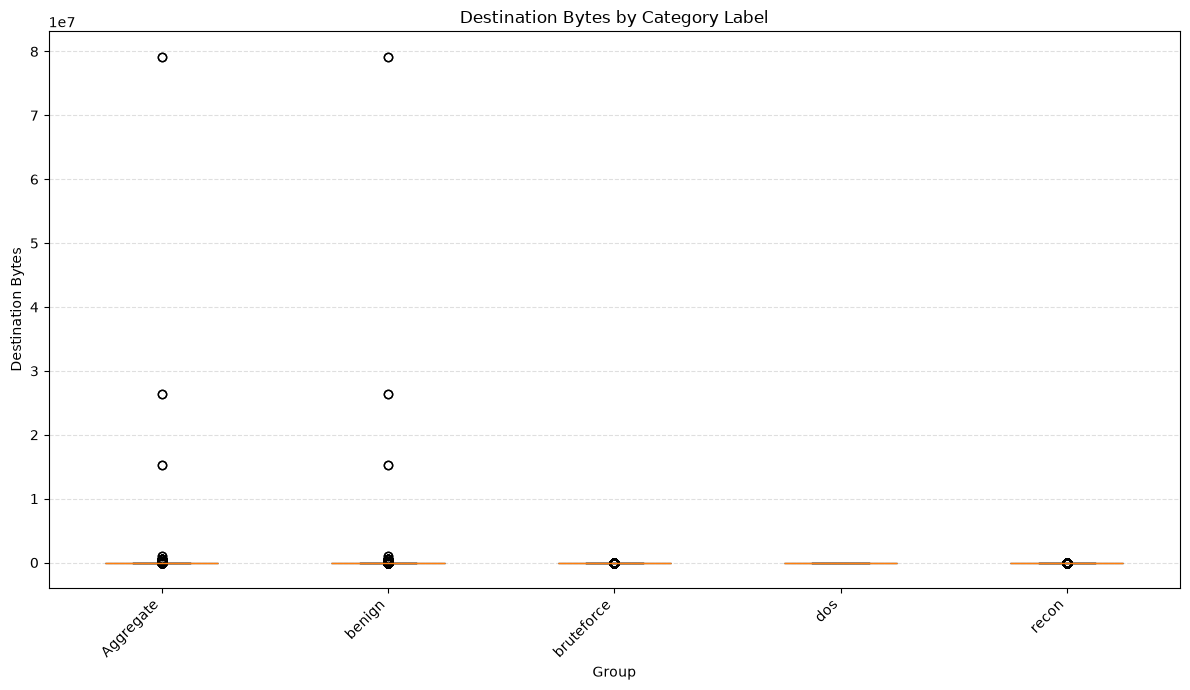

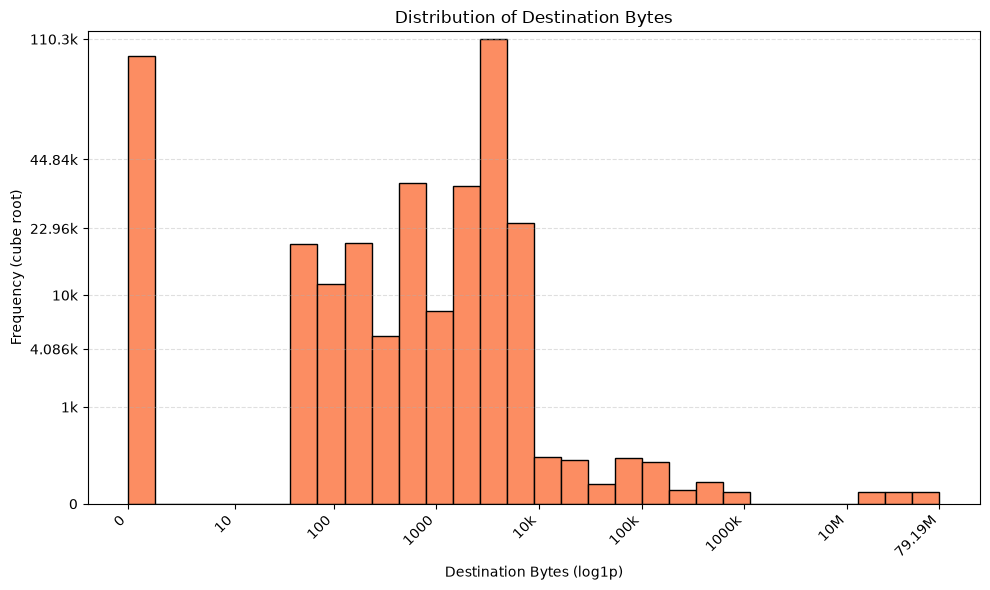

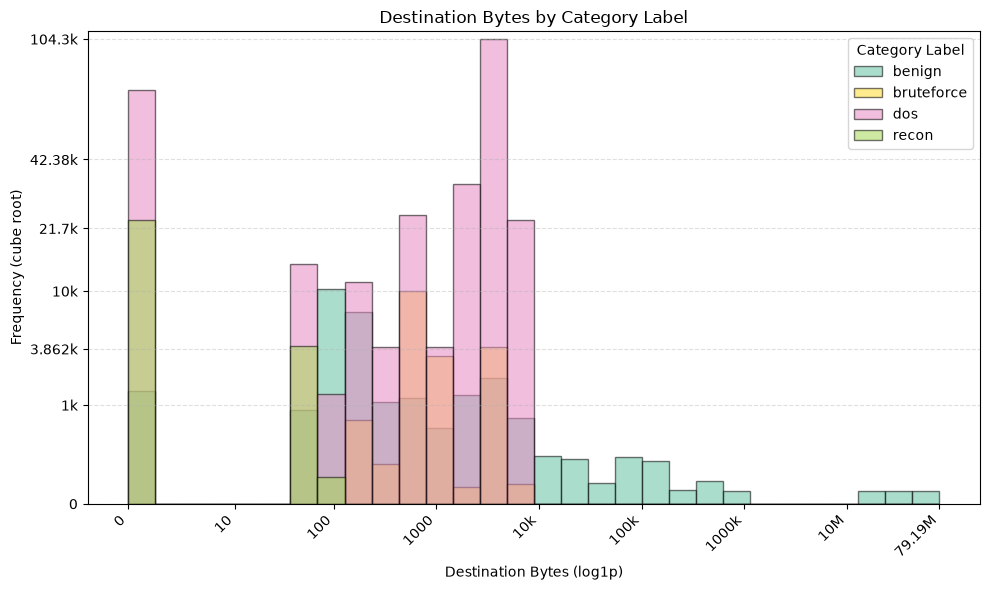

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_bytes"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Source Packets,amount_of_source_packets,numeric,predictor,Packets transmitted from source to destination.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 25019]"
3,minimum,0.0
4,maximum,25019.0
5,mean,76.276427
6,standard_deviation,89.320238
7,percentile_05,1.0
8,percentile_25,7.0
9,percentile_50,101.0


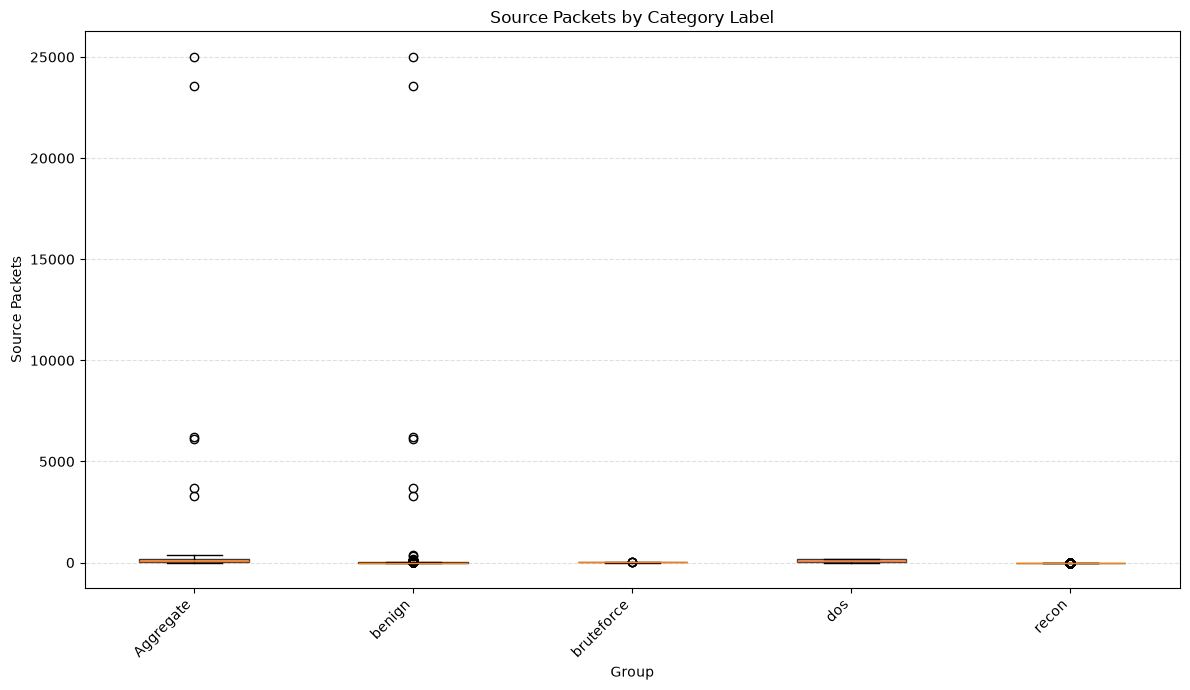

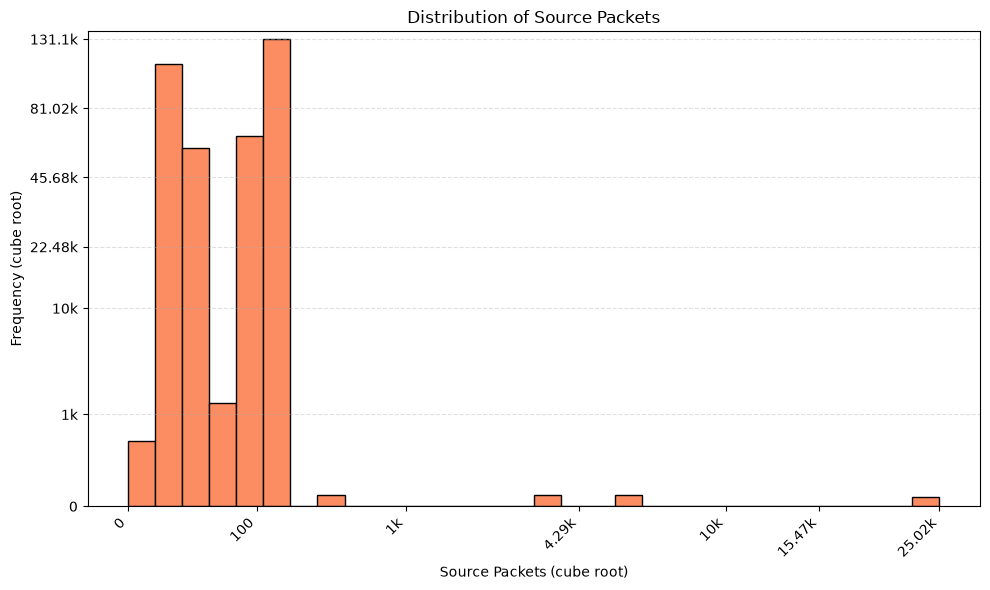

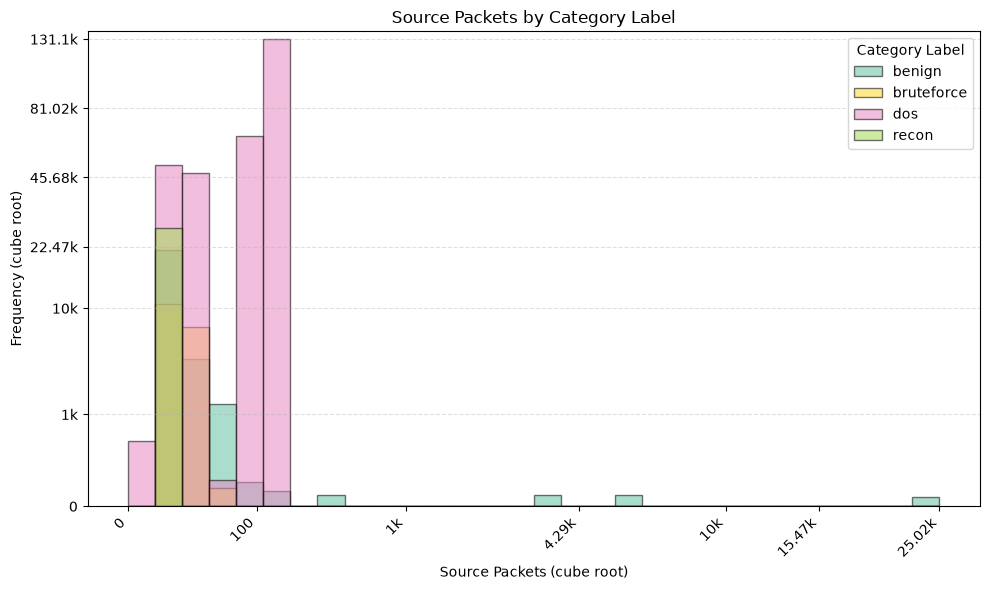

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("amount_of_source_packets"),
)

,name,label,semantic_type,role,description
0,Minimum Duration,minimum_duration,numeric,predictor,Minimum duration among the aggregated records.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 59.9993]"
3,minimum,0.0
4,maximum,59.999279
5,mean,40.15565
6,standard_deviation,26.030945
7,percentile_05,0.0
8,percentile_25,5.415242
9,percentile_50,59.357697


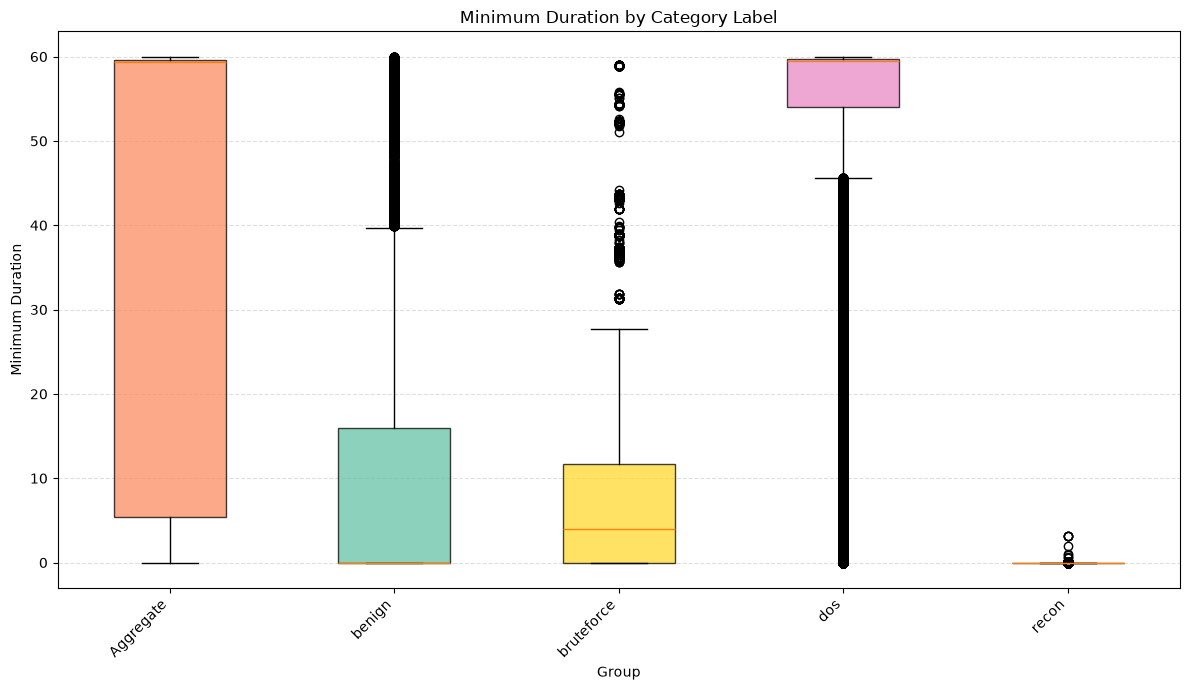

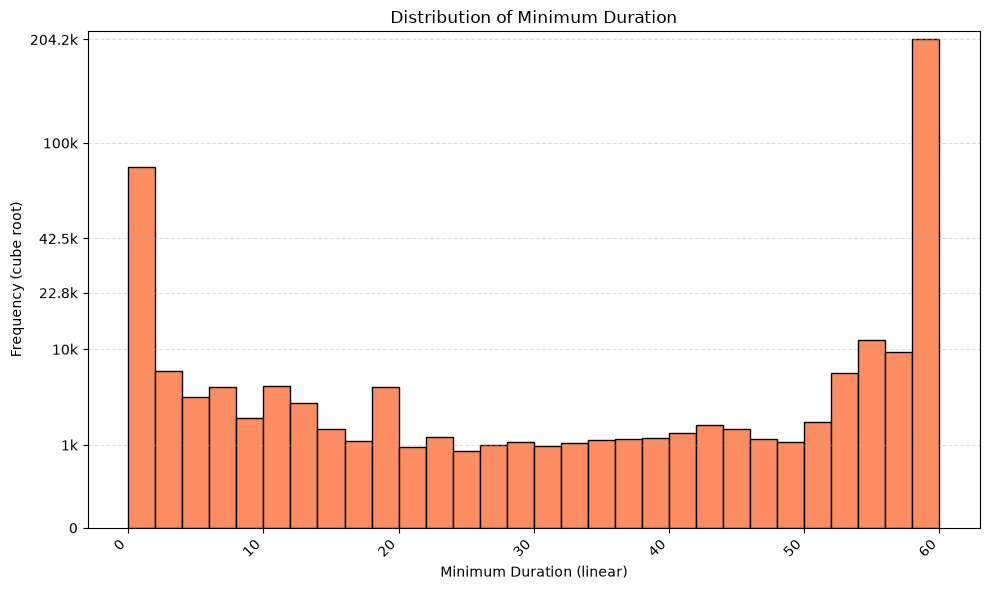

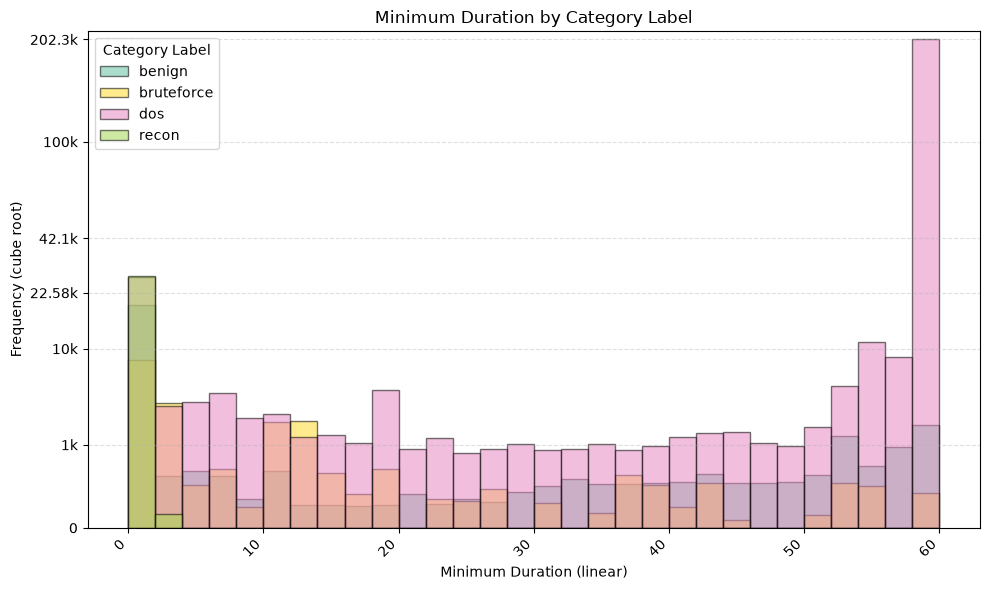

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("minimum_duration"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Destination Packet Rate,destination_packet_rate,numeric,predictor,Destination-to-source packets transmitted per ...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 25641]"
3,minimum,0.0
4,maximum,25641.027344
5,mean,51.160356
6,standard_deviation,357.434803
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.178673


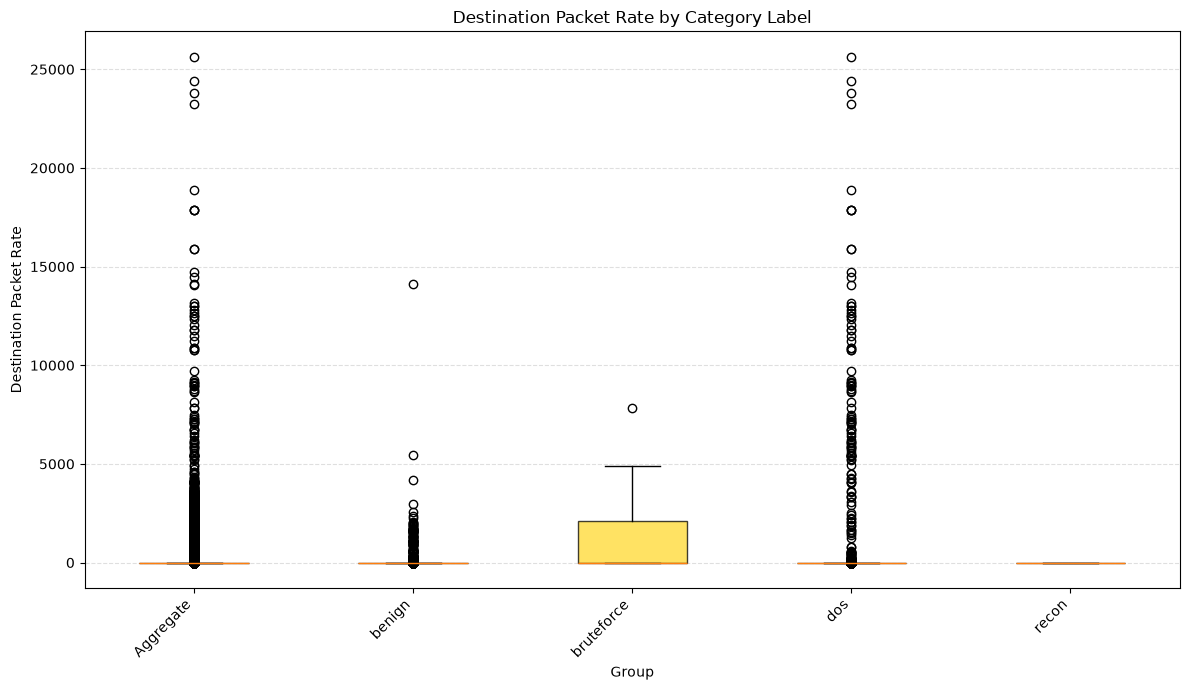

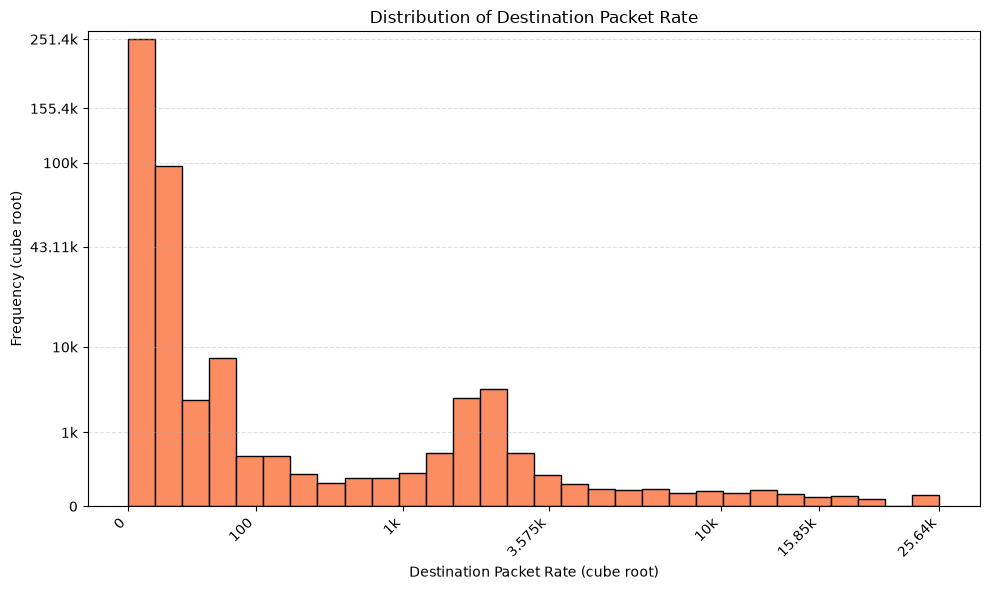

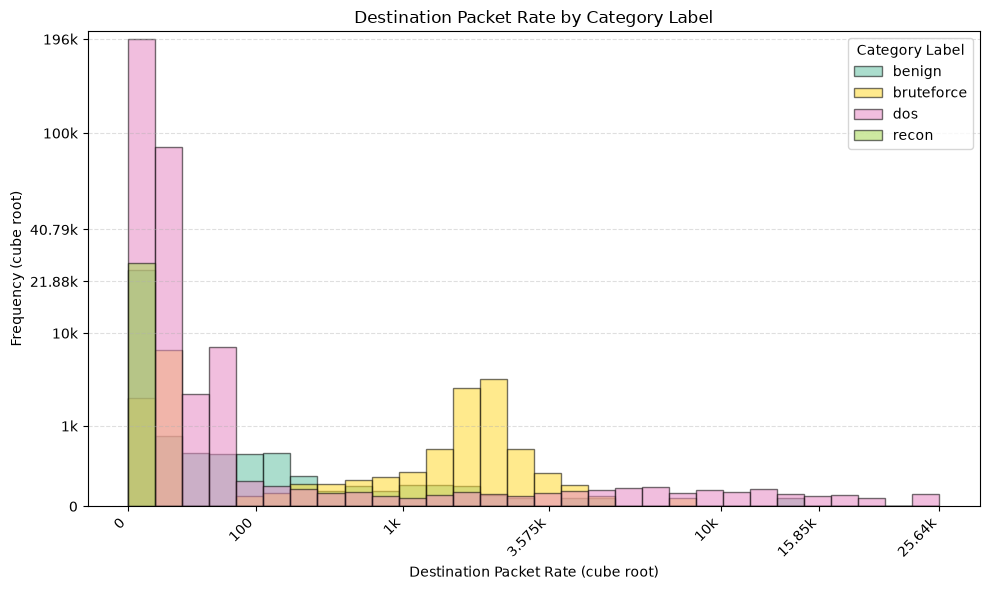

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_packet_rate"),
)

,name,label,semantic_type,role,description
0,ACK-to-Data Time,acknowledgement_data_time,numeric,predictor,TCP connection setup time between the SYN-ACK ...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 0.028134]"
3,minimum,0.0
4,maximum,0.028134
5,mean,0.000022
6,standard_deviation,0.000086
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


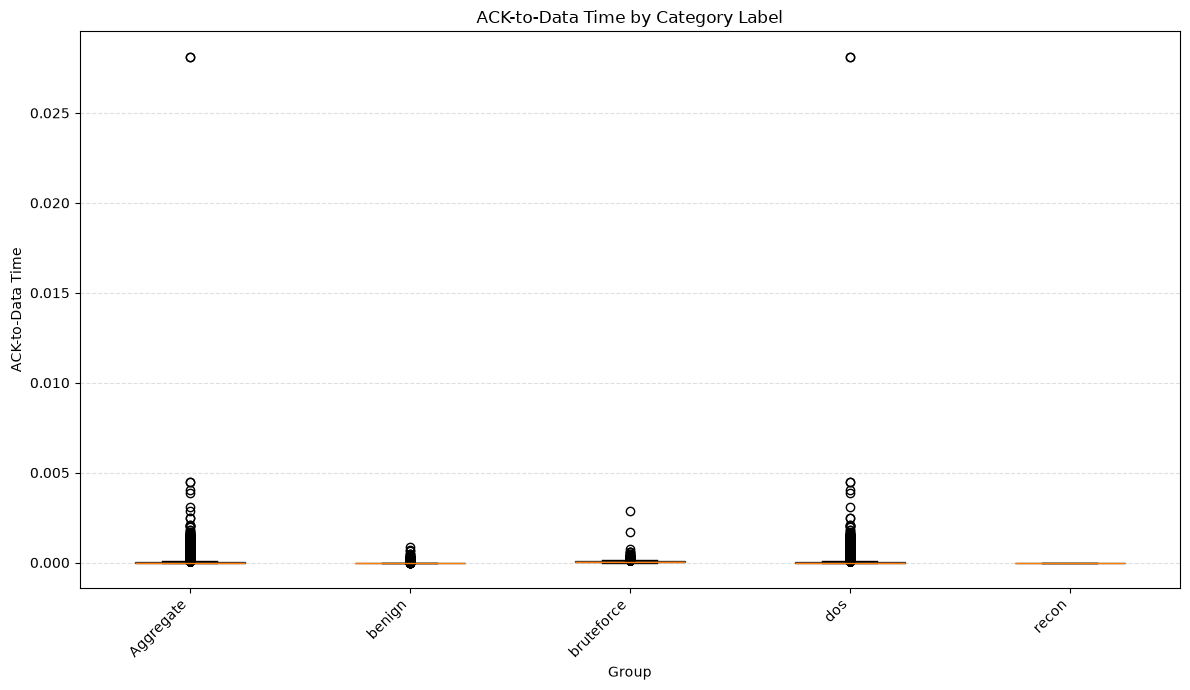

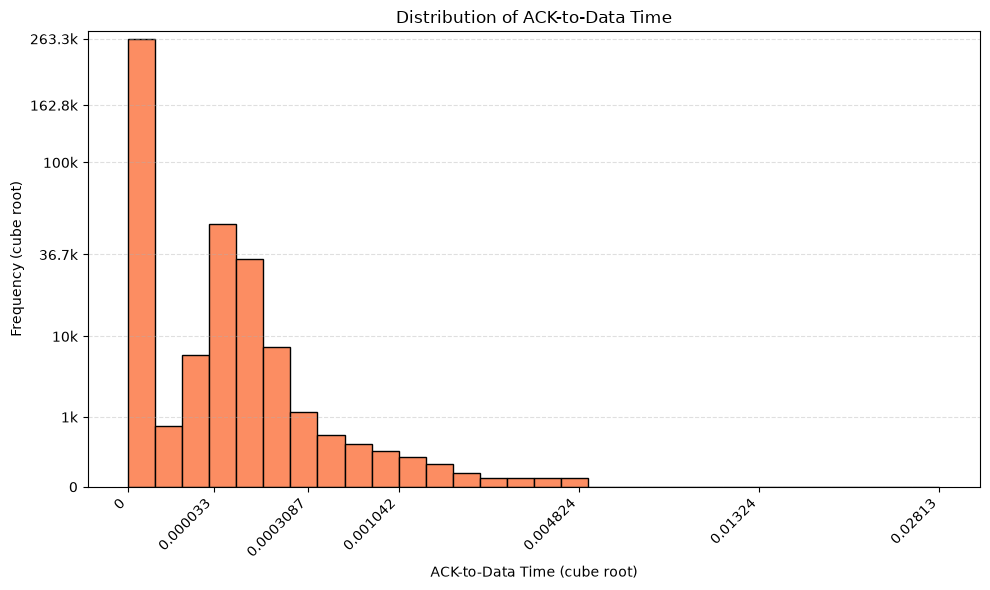

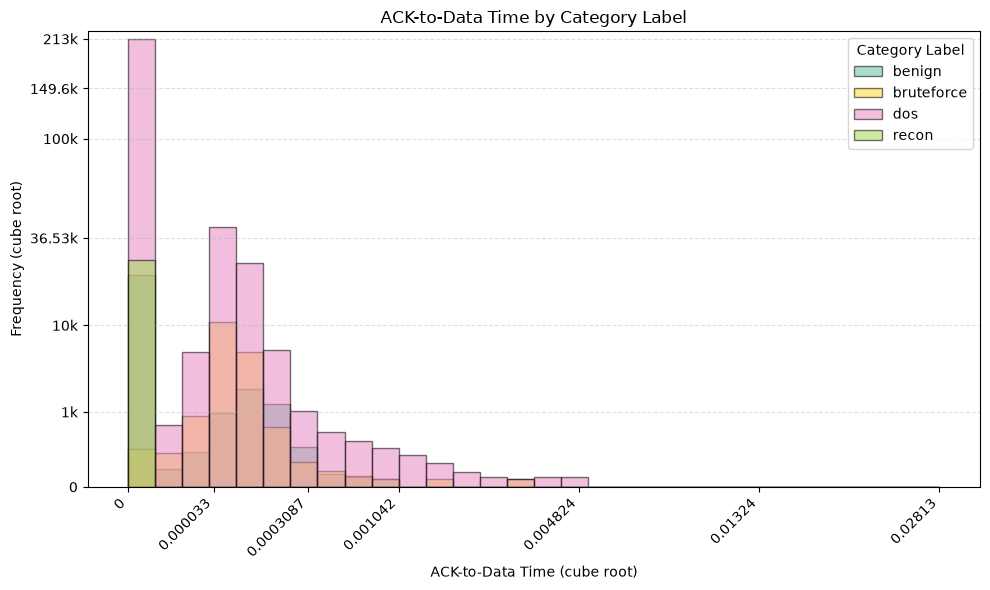

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("acknowledgement_data_time"),
)

,name,label,semantic_type,role,description
0,Maximum Source Packet Size,source_maximum_packet_size,numeric,predictor,Maximum packet size transmitted by the source.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 5571]"
3,minimum,0.0
4,maximum,5571.0
5,mean,150.528199
6,standard_deviation,232.037335
7,percentile_05,60.0
8,percentile_25,60.0
9,percentile_50,60.0


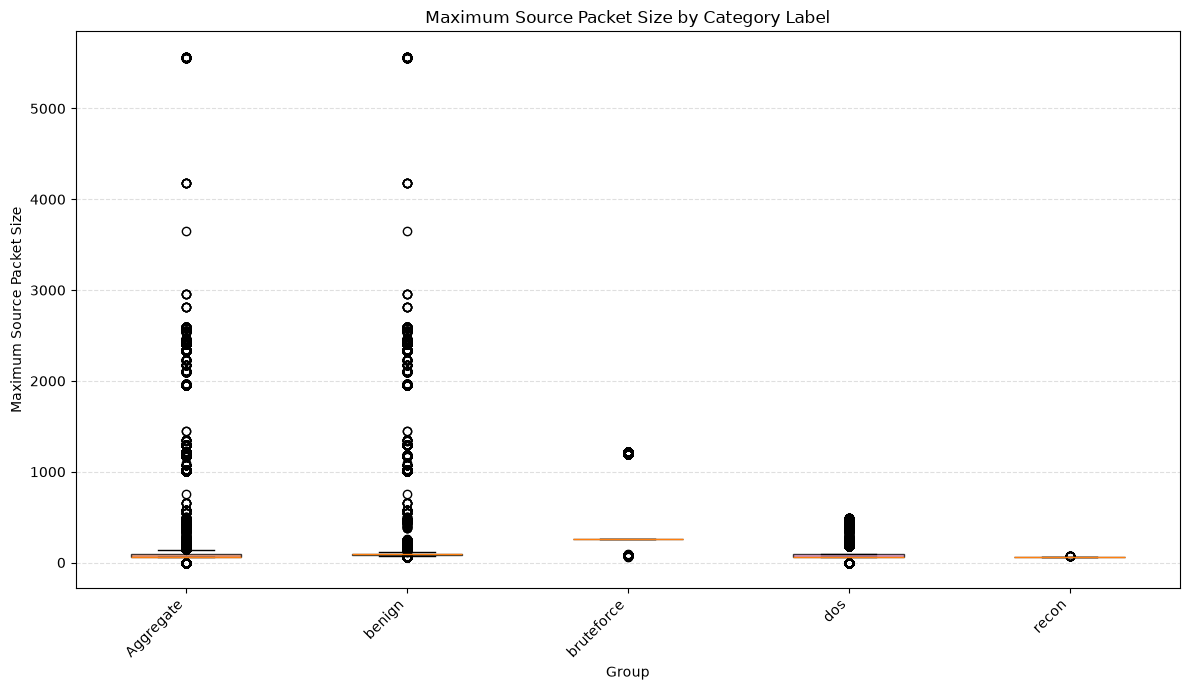

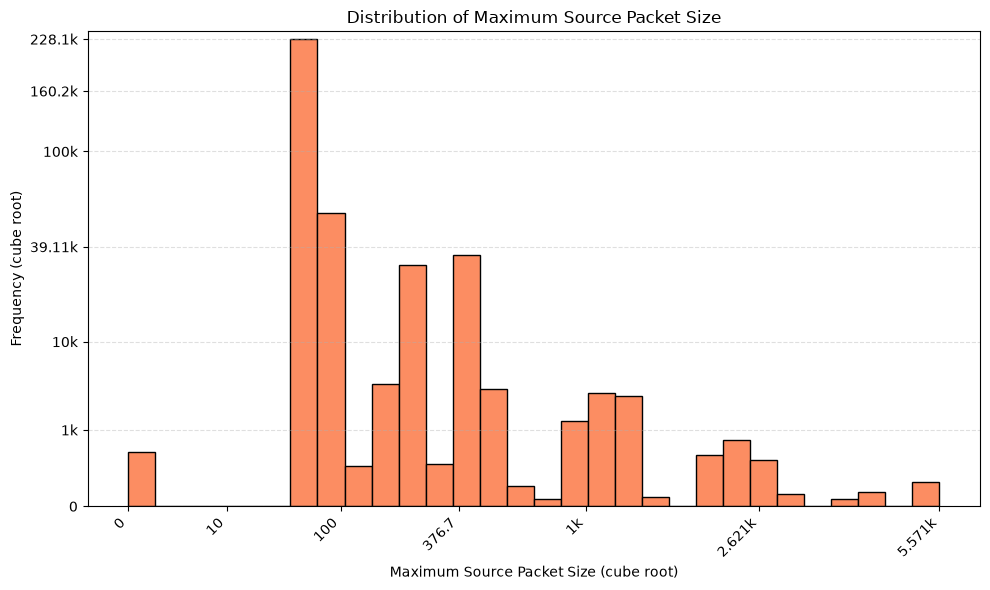

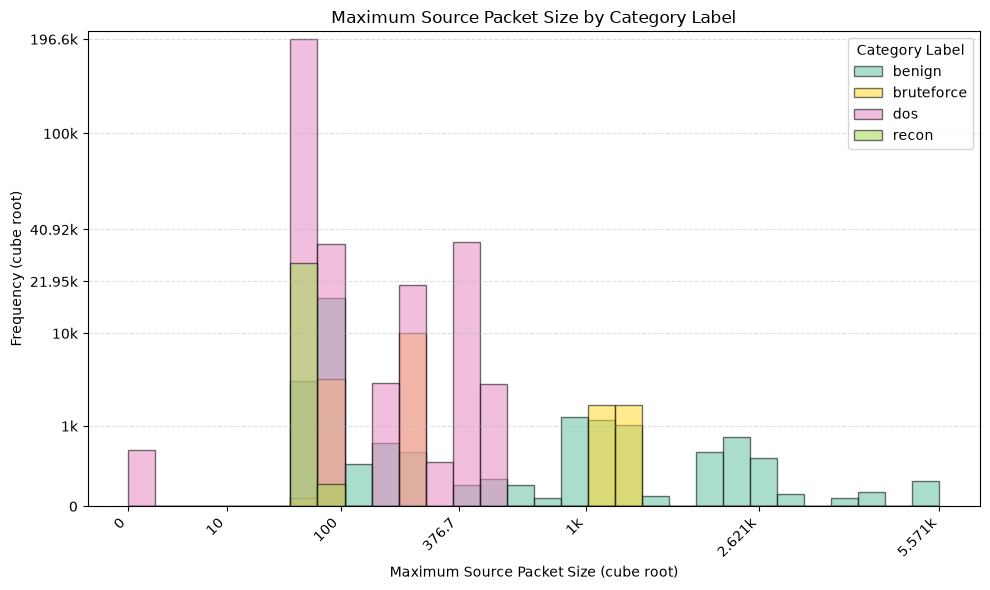

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_maximum_packet_size")
)

,name,label,semantic_type,role,description
0,Maximum Source Inter-Packet Time,source_interpacket_time_maximum,numeric,predictor,Maximum source inter-packet arrival time in mi...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118956]"
3,minimum,0.0
4,maximum,118955.776
5,mean,6708.781391
6,standard_deviation,14492.51278
7,percentile_05,0.0
8,percentile_25,597.506
9,percentile_50,830.751


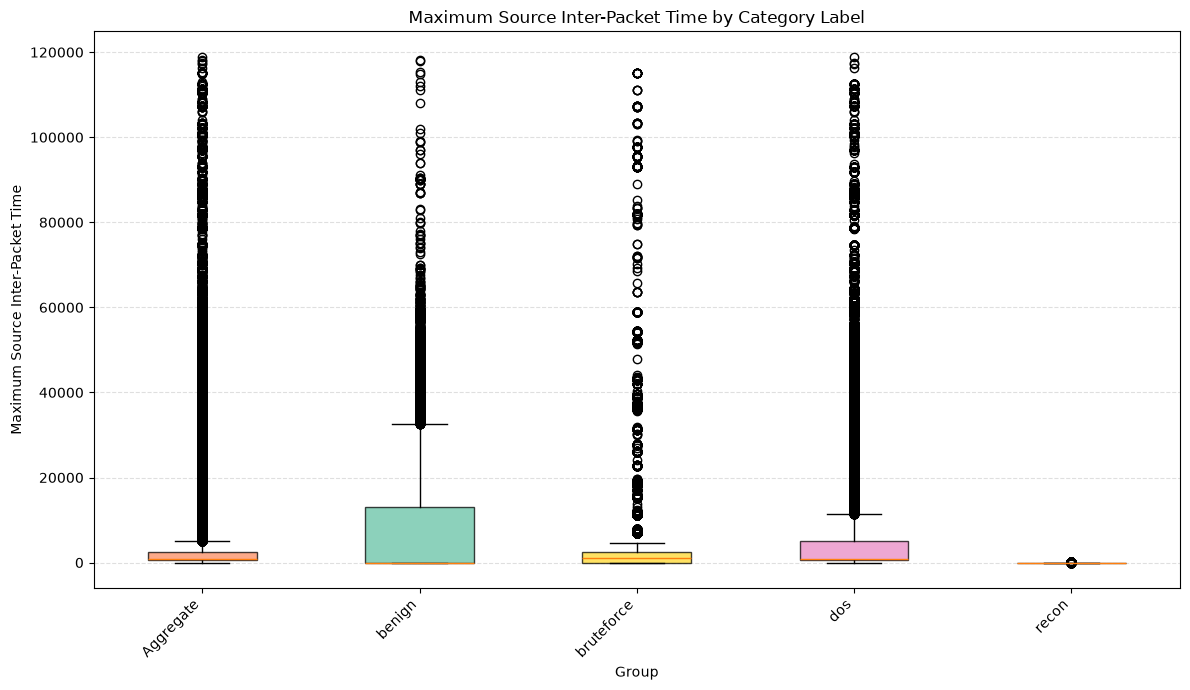

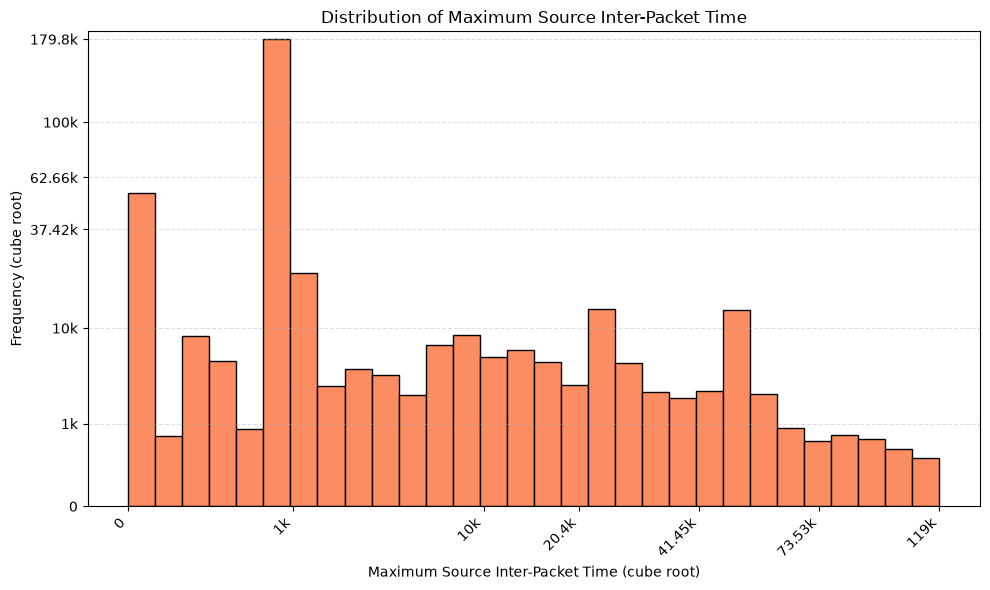

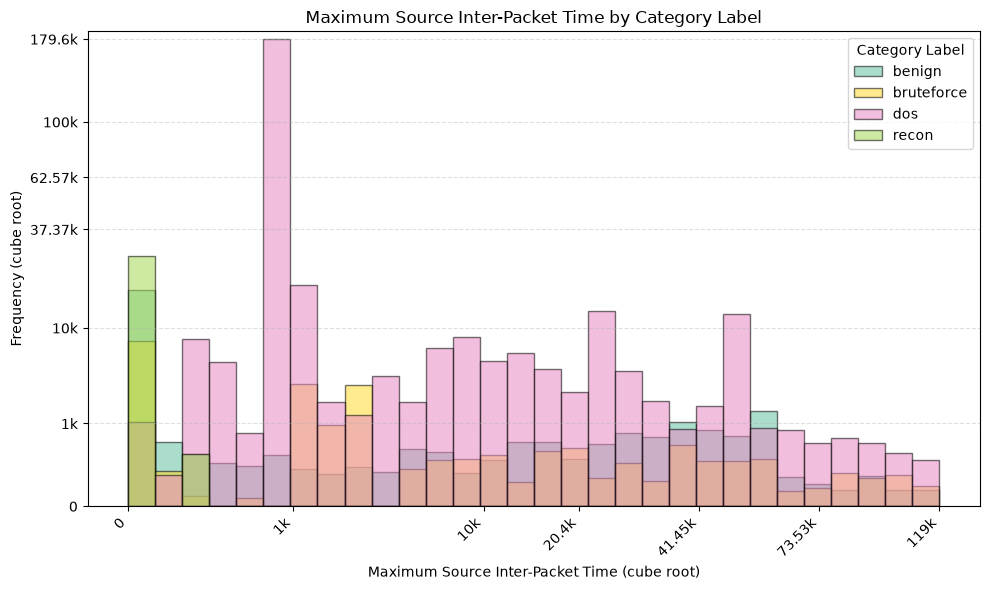

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_interpacket_time_maximum")
)

,name,label,semantic_type,role,description
0,Packet Loss,amount_of_package_loss,numeric,predictor,Packets retransmitted or dropped.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 2023]"
3,minimum,0.0
4,maximum,2023.0
5,mean,0.943246
6,standard_deviation,5.53487
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


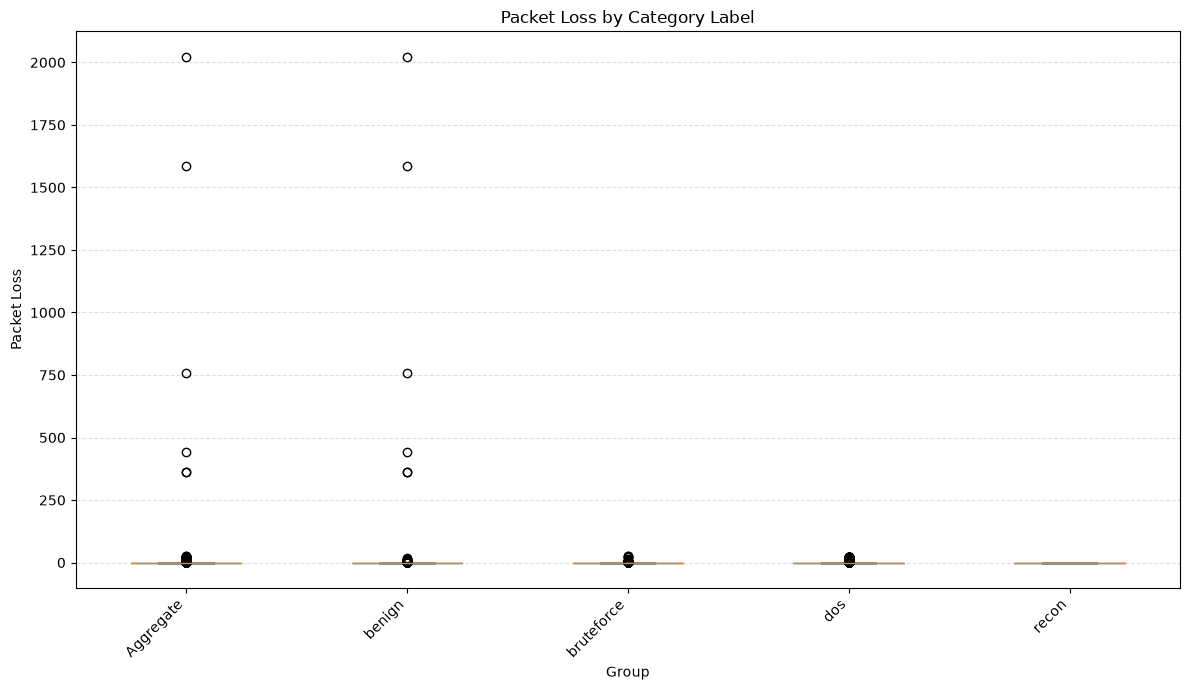

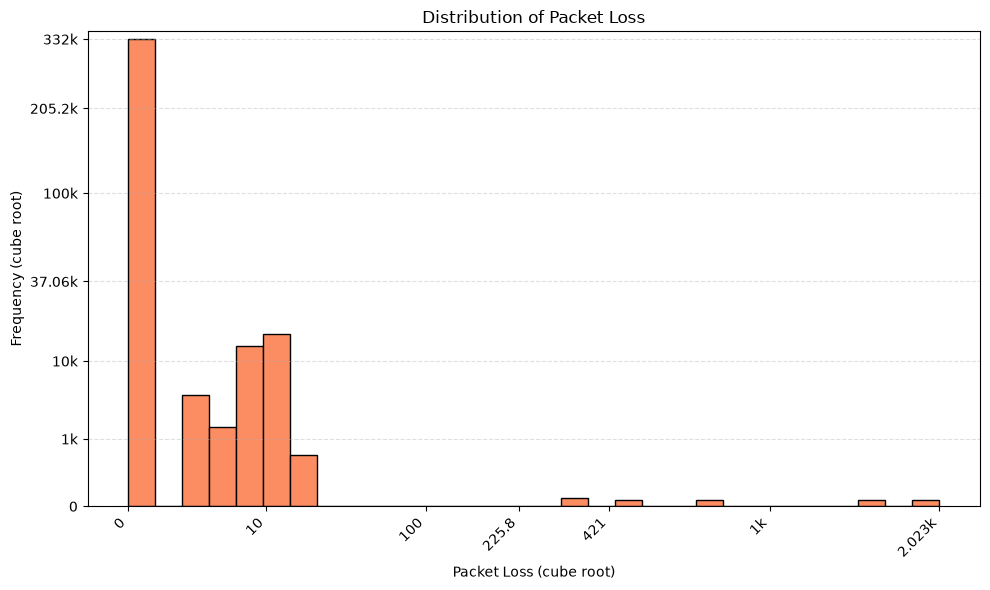

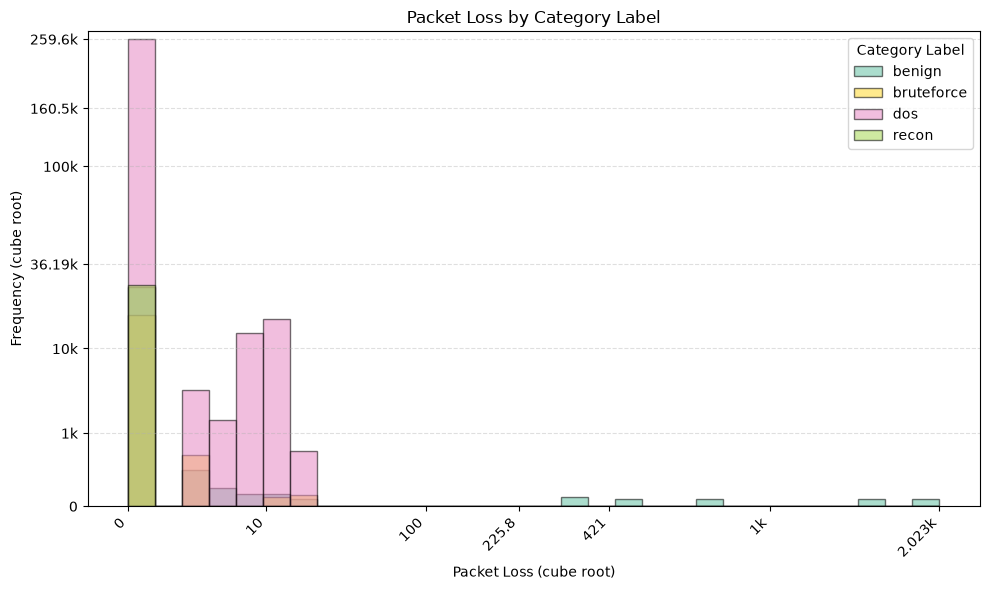

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("amount_of_package_loss"),
)

,name,label,semantic_type,role,description
0,Destination Inter-Packet Time,destination_interpacket_time,numeric,predictor,Destination inter-packet arrival time in milli...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118160]"
3,minimum,0.0
4,maximum,118160.208
5,mean,5025.997234
6,standard_deviation,15352.669772
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,751.494812


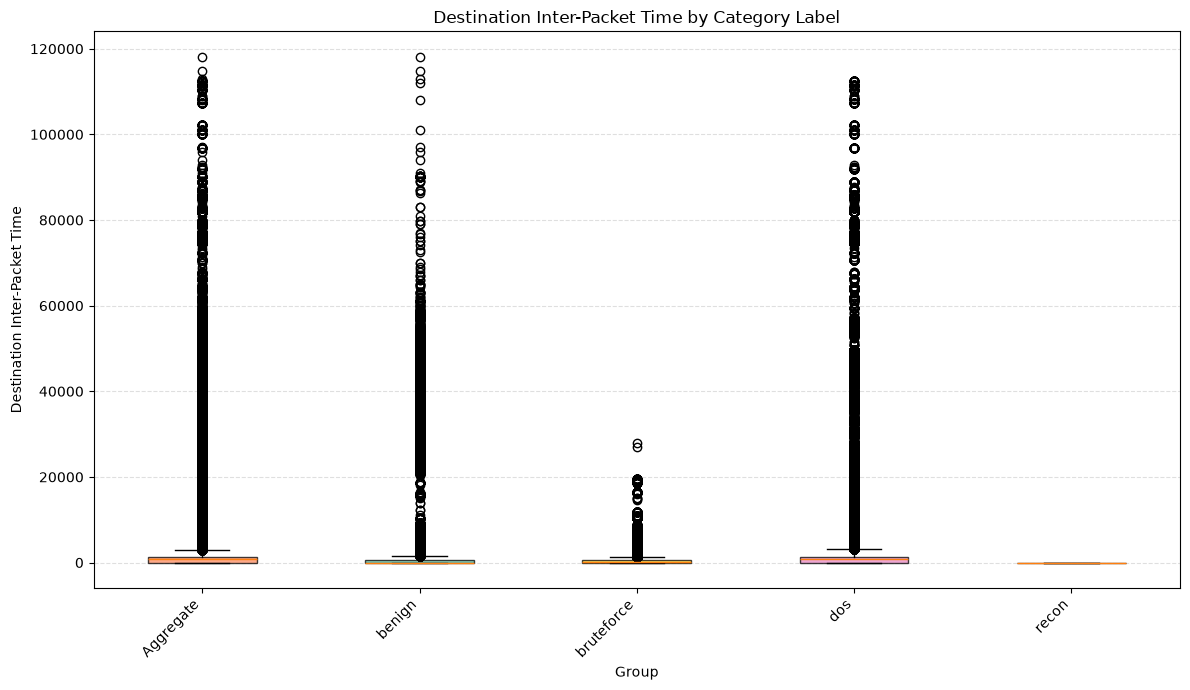

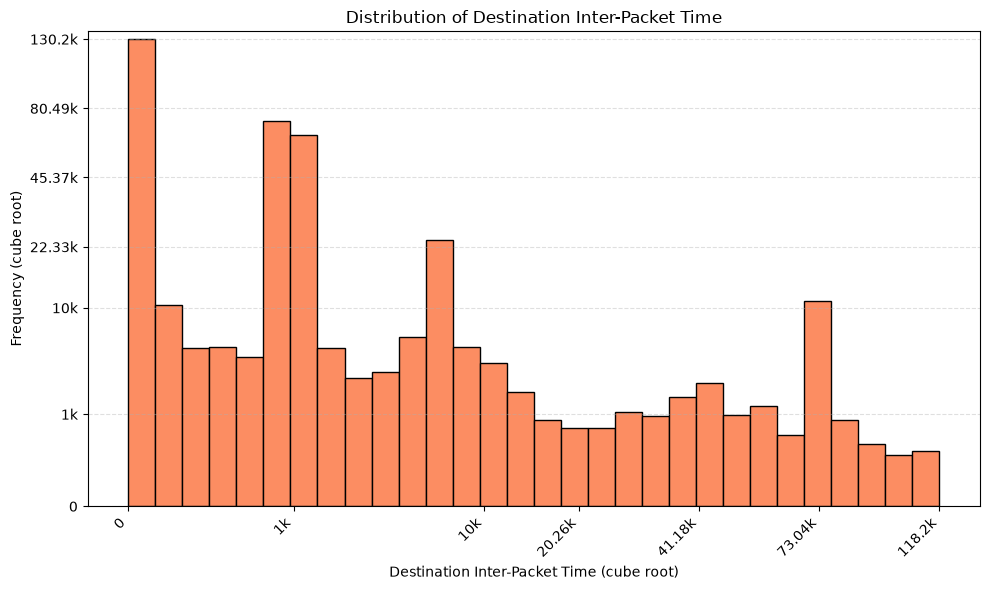

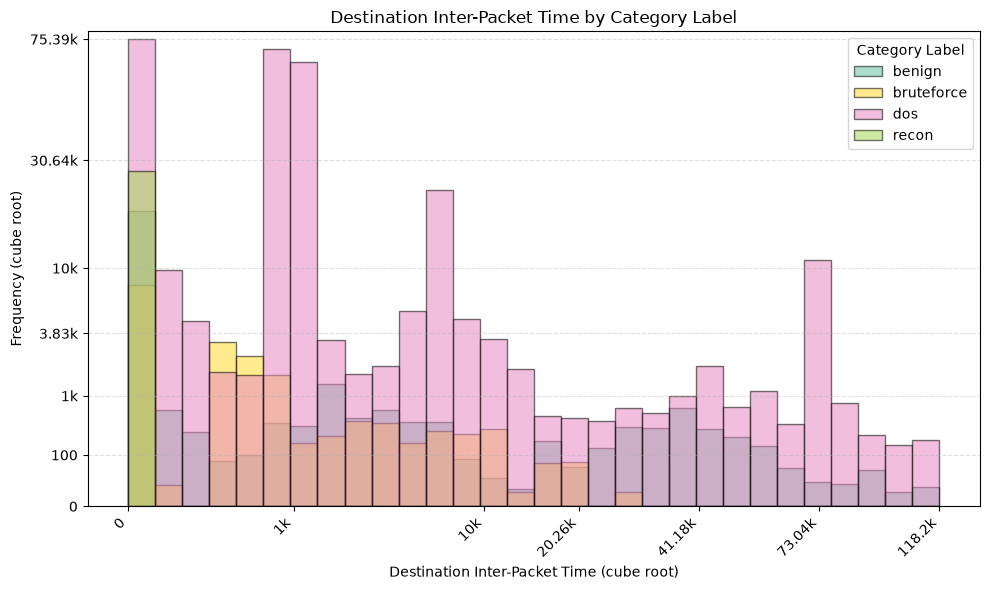

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_interpacket_time")
)

,name,label,semantic_type,role,description
0,Source Load,source_load,numeric,predictor,Source traffic load in bits per second.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 2.44e+08]"
3,minimum,0.0
4,maximum,243999984.0
5,mean,105675.792074
6,standard_deviation,2280163.172925
7,percentile_05,0.0
8,percentile_25,215.786263
9,percentile_50,816.247895


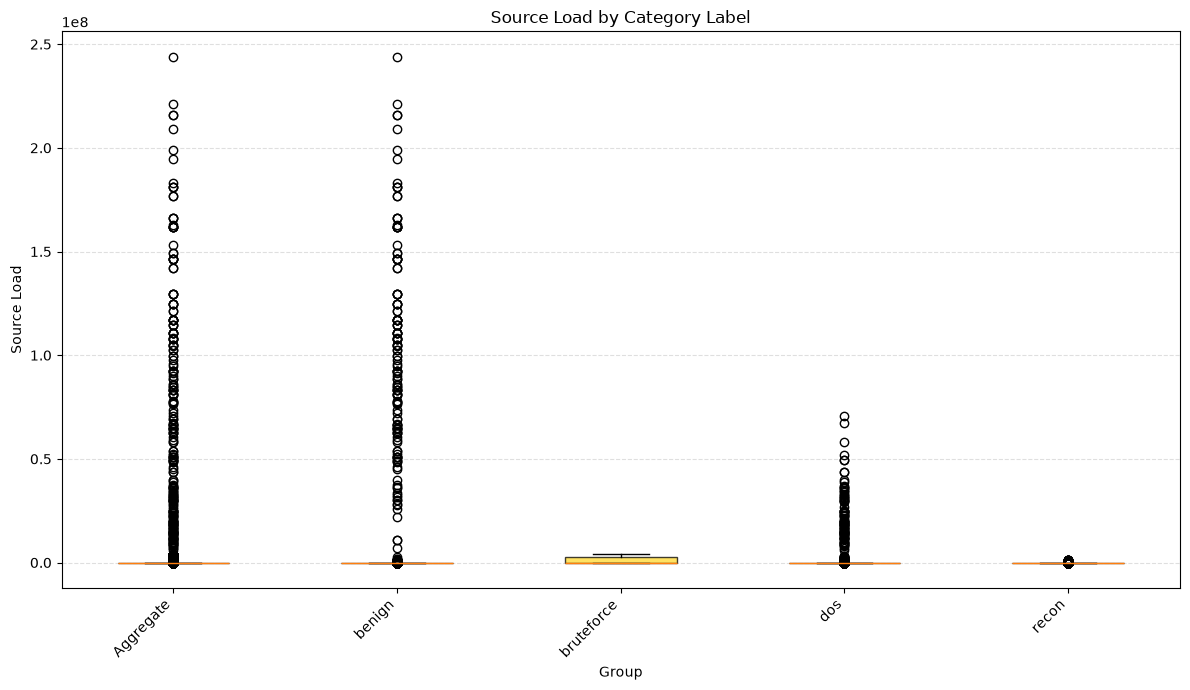

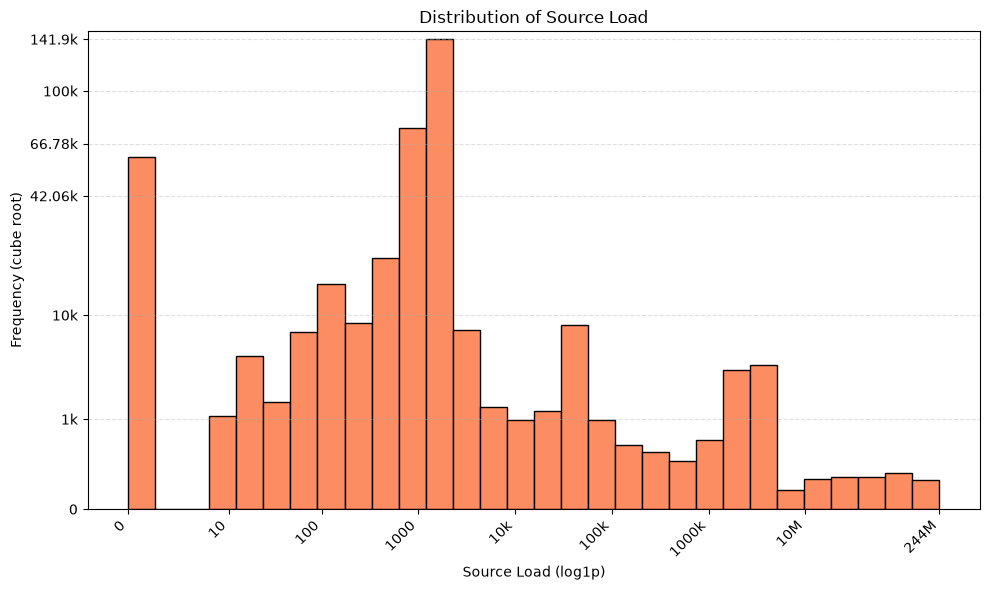

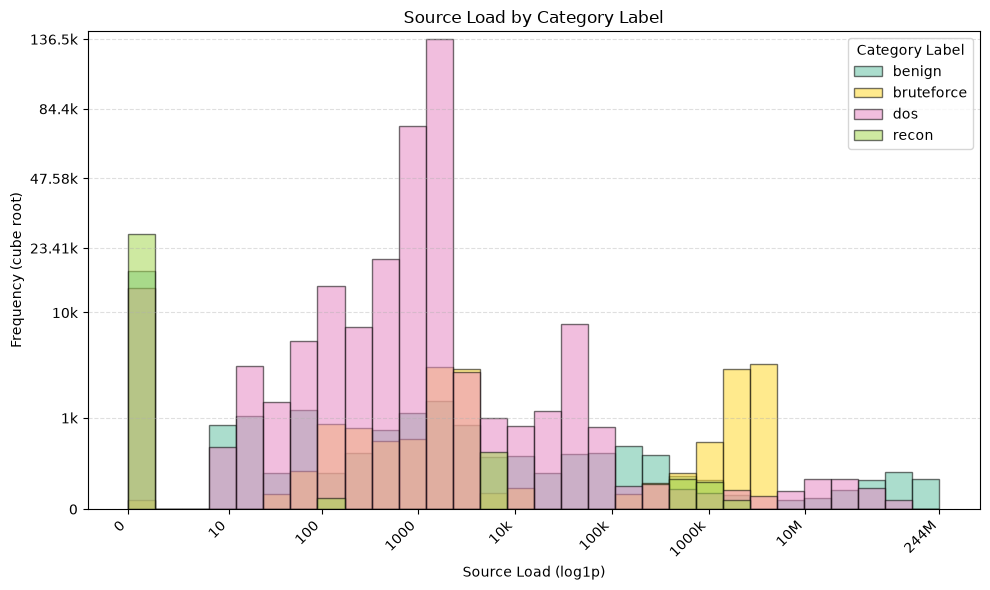

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_load"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Source Packet Rate,source_packet_rate,numeric,predictor,Source-to-destination packets transmitted per ...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 166667]"
3,minimum,0.0
4,maximum,166666.65625
5,mean,85.051805
6,standard_deviation,1296.510789
7,percentile_05,0.0
8,percentile_25,0.209345
9,percentile_50,1.696951


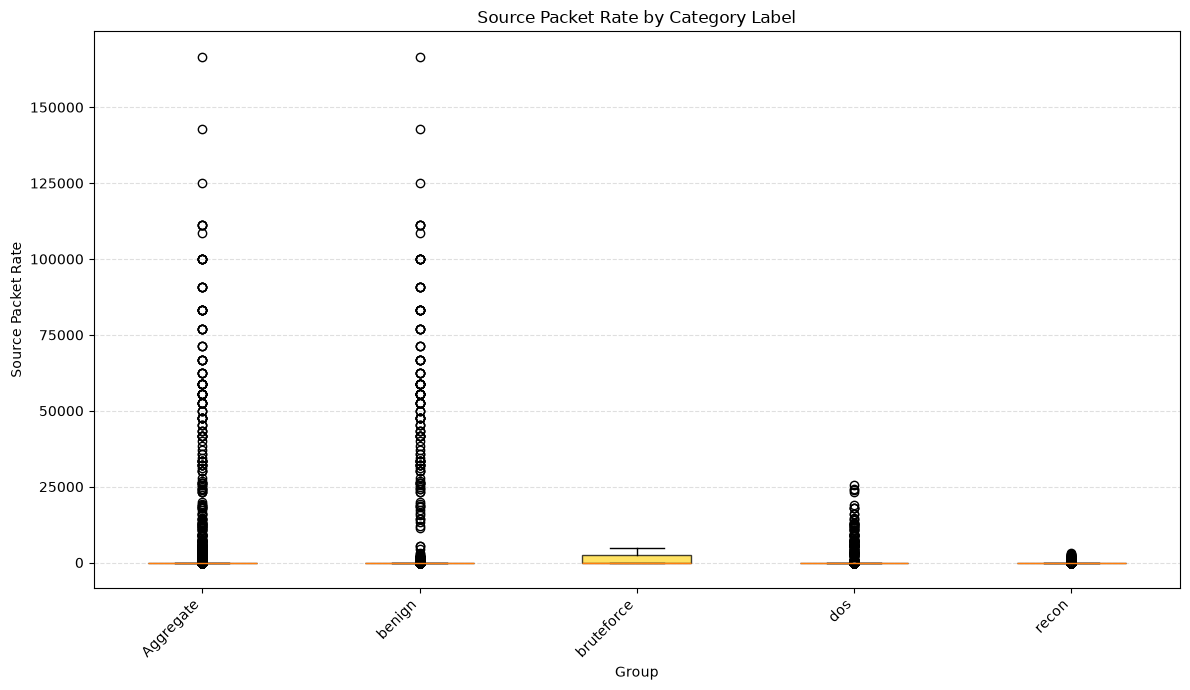

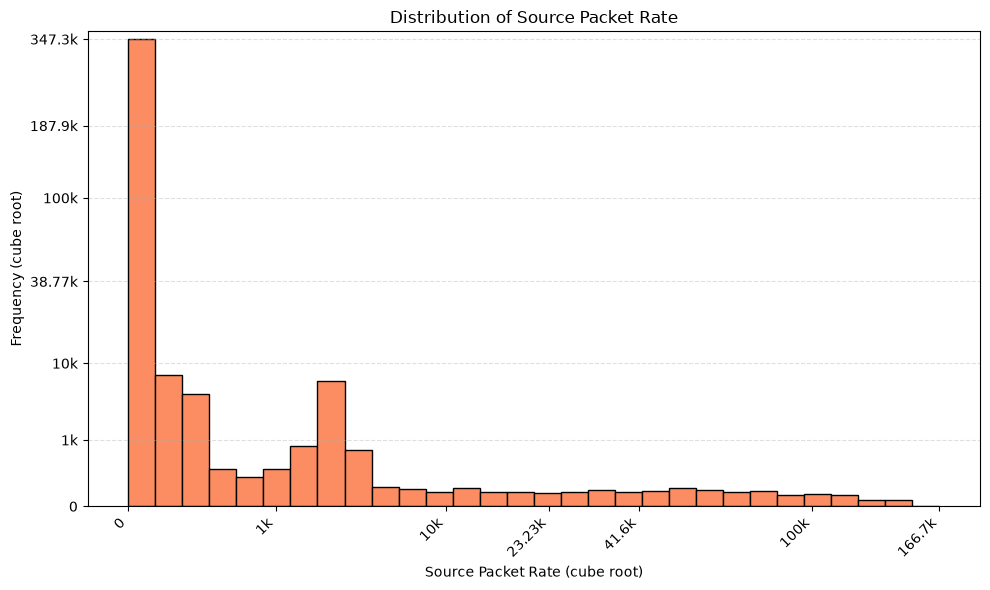

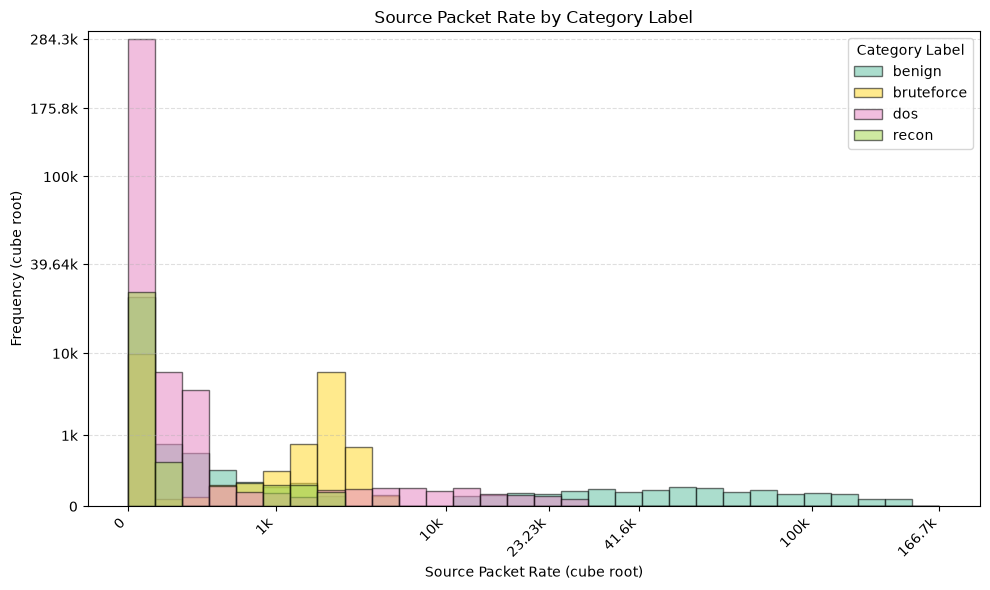

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_packet_rate"),
)

,name,label,semantic_type,role,description
0,Maximum Destination Inter-Packet Time,destination_interpacket_time_maximum,numeric,predictor,Maximum destination inter-packet arrival time ...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118160]"
3,minimum,0.0
4,maximum,118160.208
5,mean,790.507425
6,standard_deviation,3368.664351
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


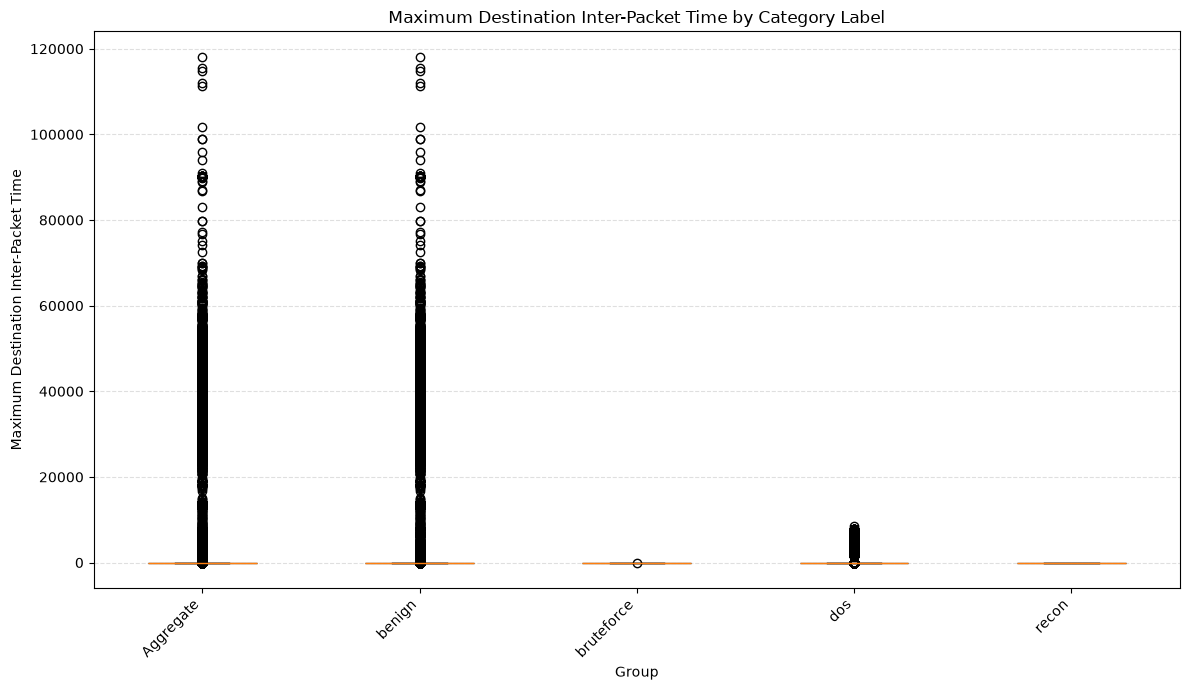

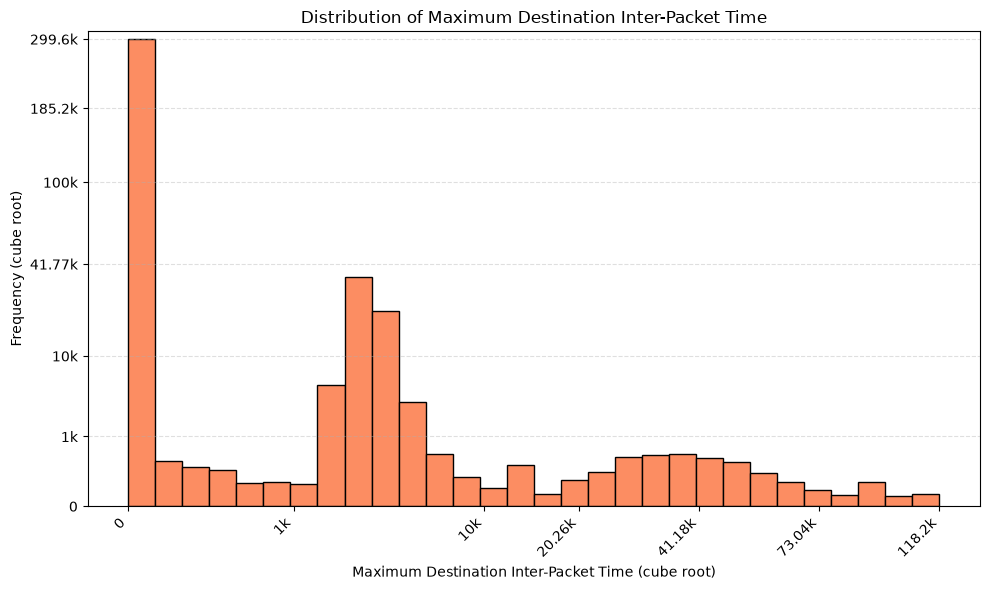

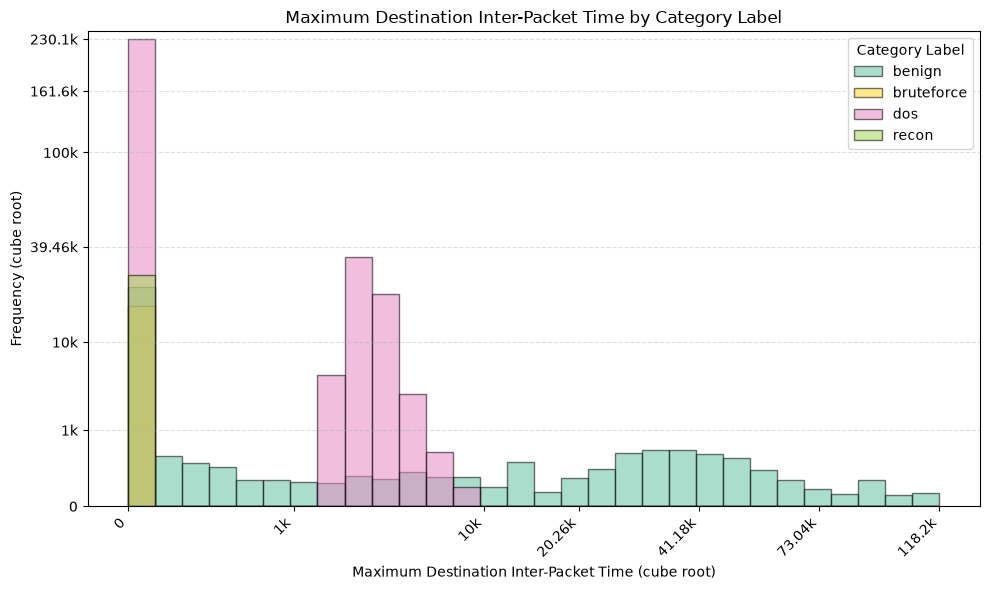

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_interpacket_time_maximum")
)

,name,label,semantic_type,role,description
0,Source Bytes,source_bytes,numeric,predictor,Bytes transmitted from source to destination.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 1.78904e+06]"
3,minimum,0.0
4,maximum,1789044.0
5,mean,4894.680135
6,standard_deviation,5746.220936
7,percentile_05,60.0
8,percentile_25,769.0
9,percentile_50,6060.0


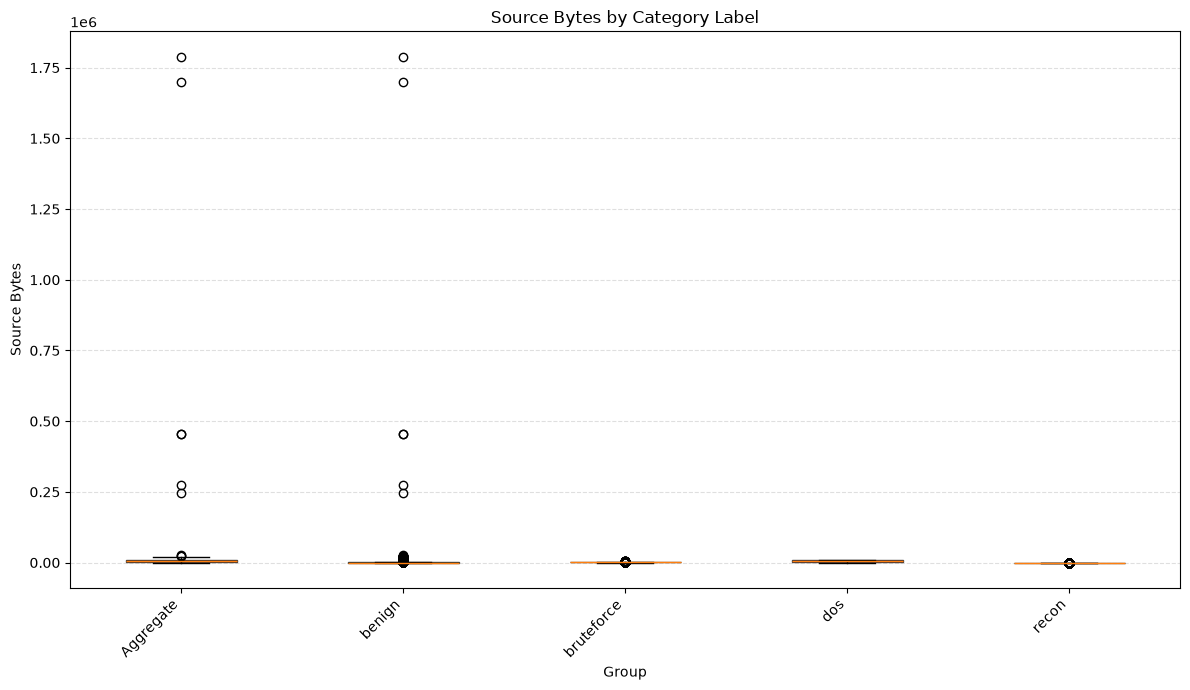

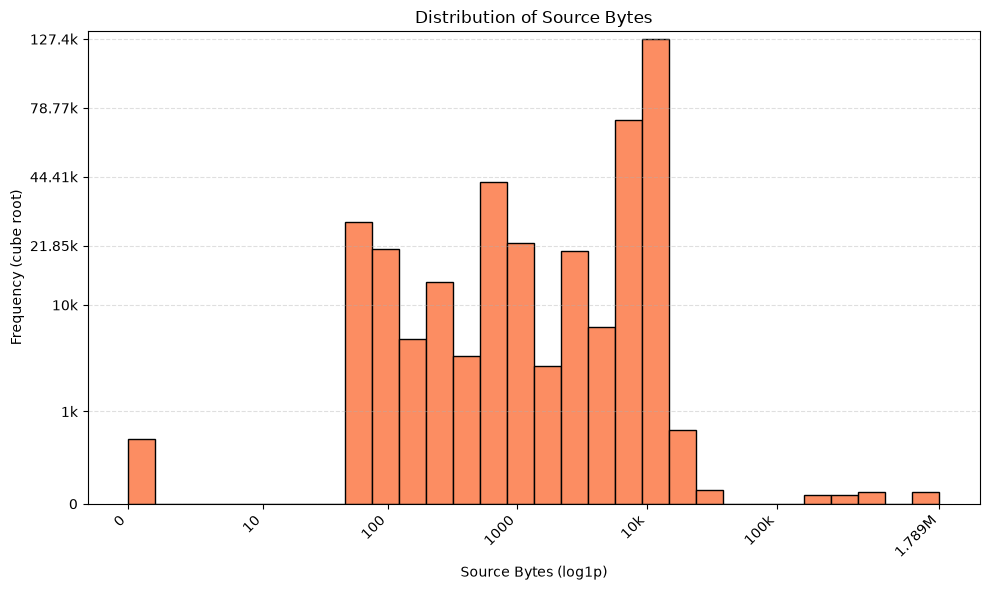

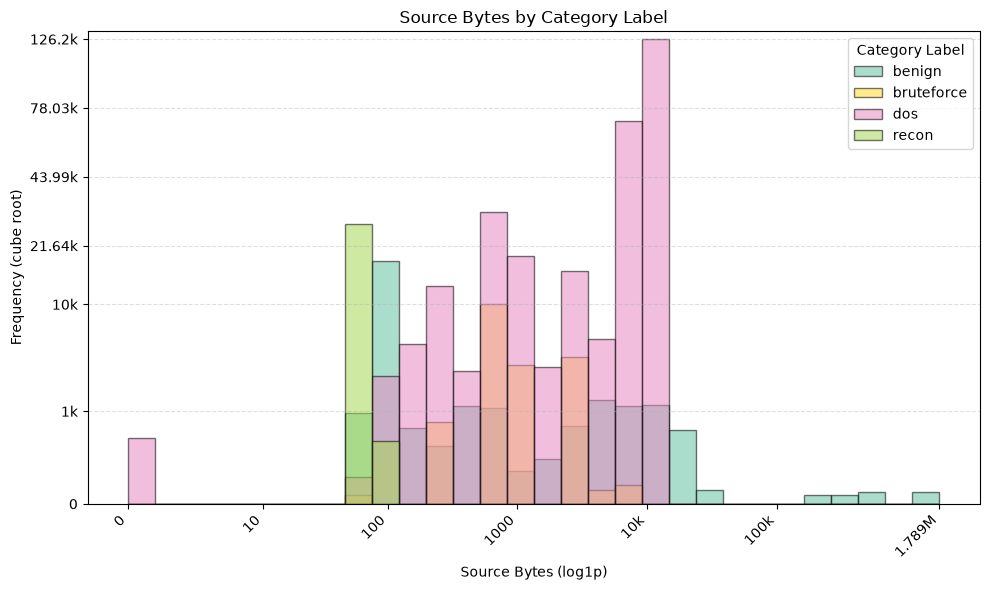

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_bytes"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Total Application Bytes,total_application_bytes,numeric,predictor,Total application bytes.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 7.72755e+07]"
3,minimum,0.0
4,maximum,77275510.0
5,mean,1588.957795
6,standard_deviation,192976.413446
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,106.0


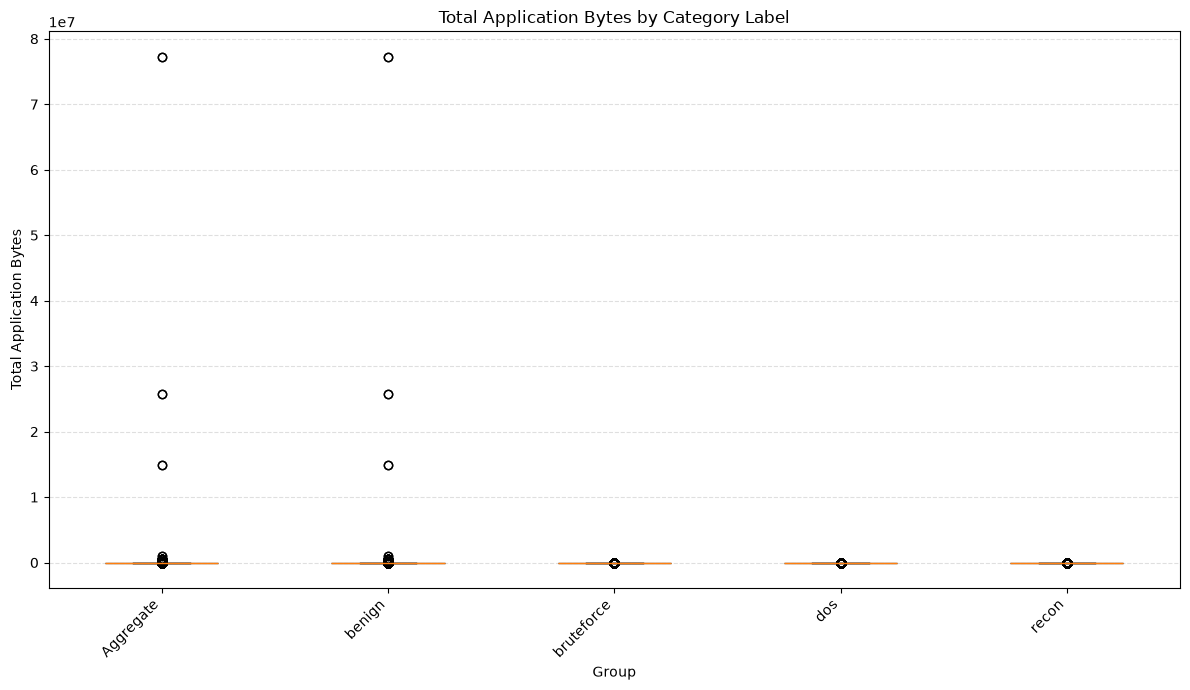

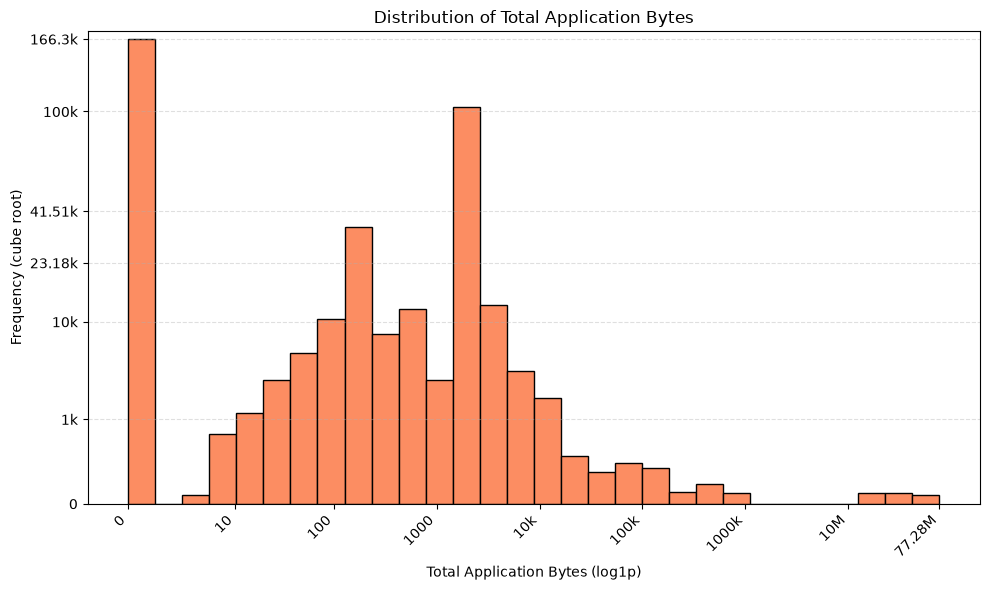

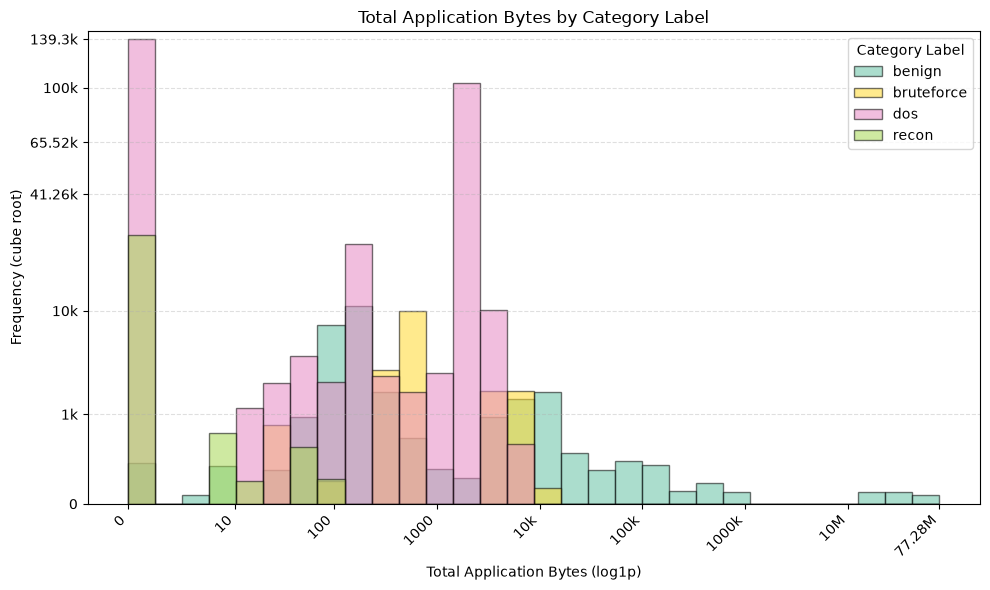

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("total_application_bytes"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Minimum Source Packet Size,source_minimum_packet_size,numeric,predictor,Minimum packet size transmitted by the source.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 482]"
3,minimum,0.0
4,maximum,482.0
5,mean,70.405111
6,standard_deviation,32.850882
7,percentile_05,60.0
8,percentile_25,60.0
9,percentile_50,60.0


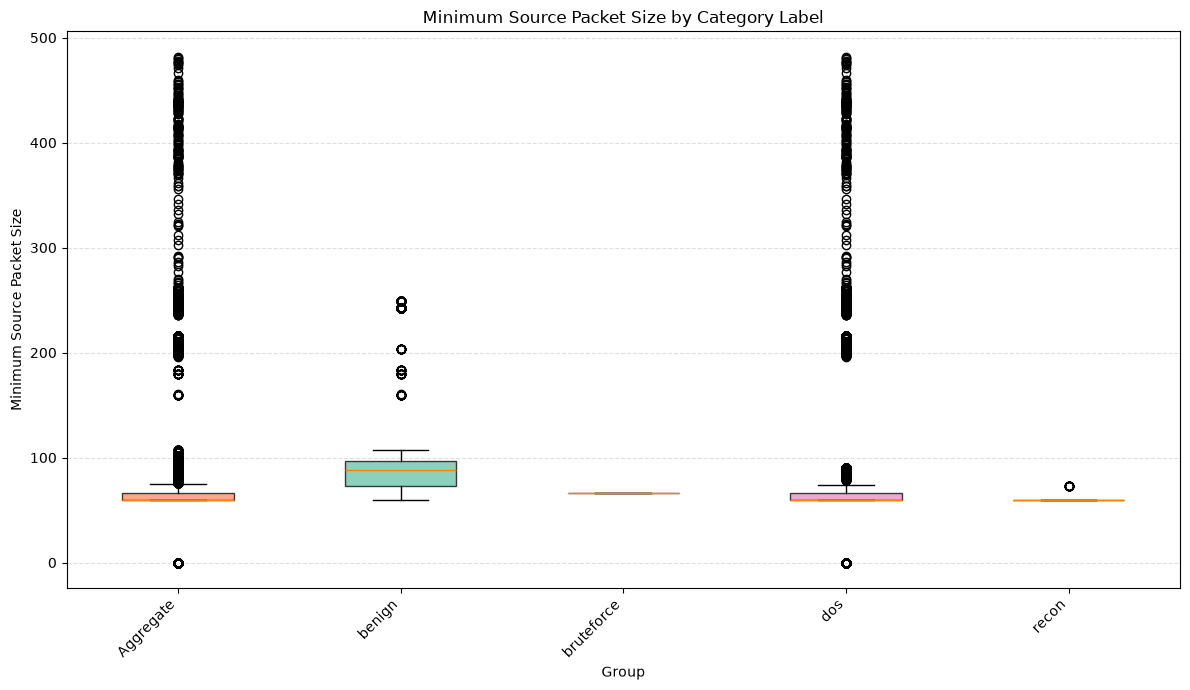

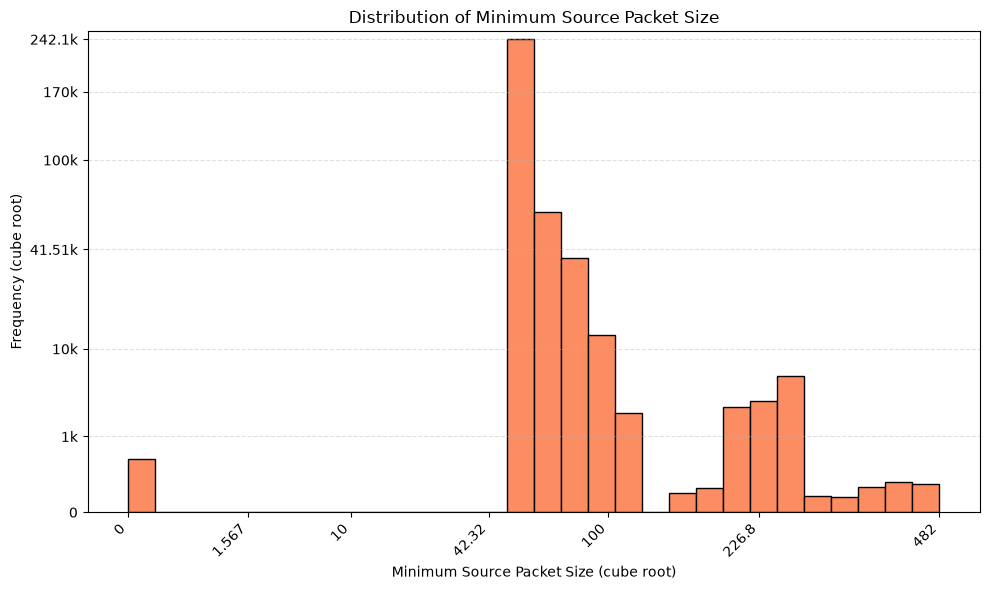

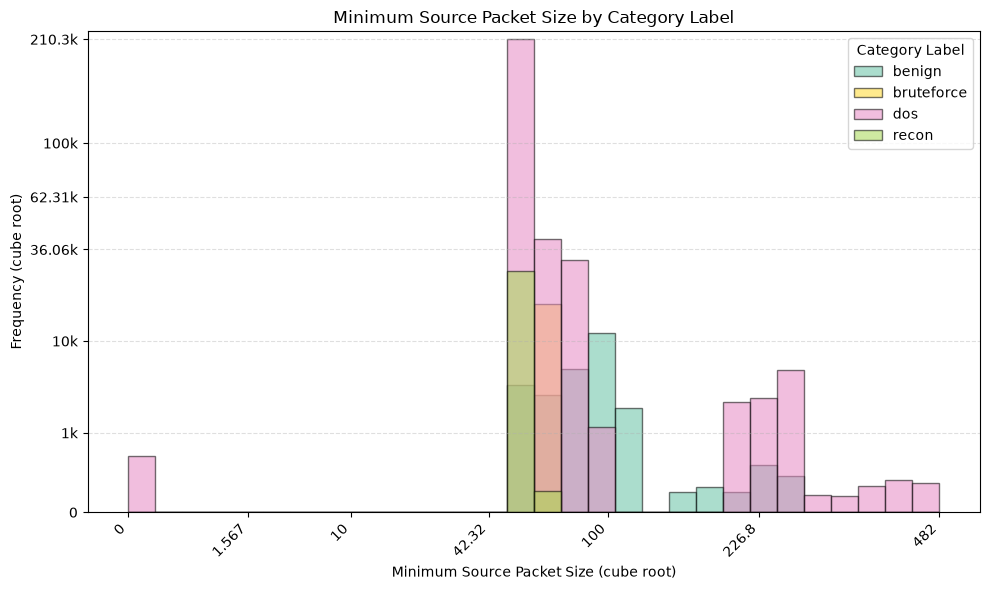

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_minimum_packet_size")
)

,name,label,semantic_type,role,description
0,Total Duration,total_duration,numeric,predictor,Total accumulated duration of the aggregated r...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 59.9993]"
3,minimum,0.0
4,maximum,59.999279
5,mean,40.15565
6,standard_deviation,26.030945
7,percentile_05,0.0
8,percentile_25,5.415242
9,percentile_50,59.357697


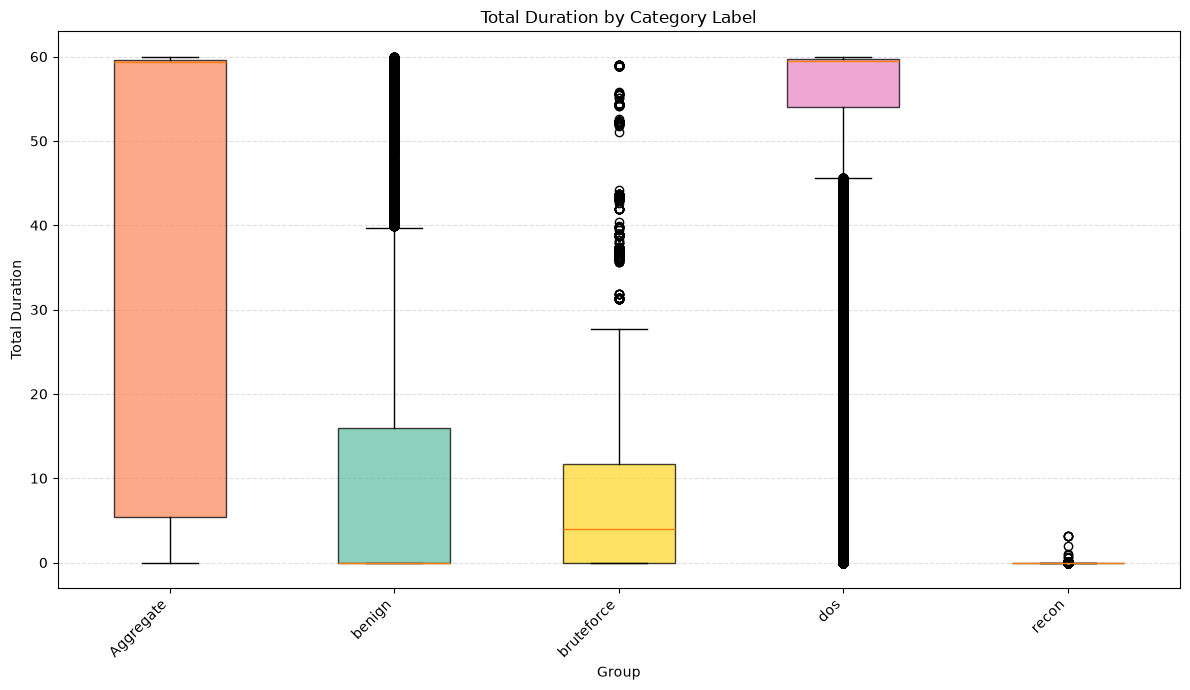

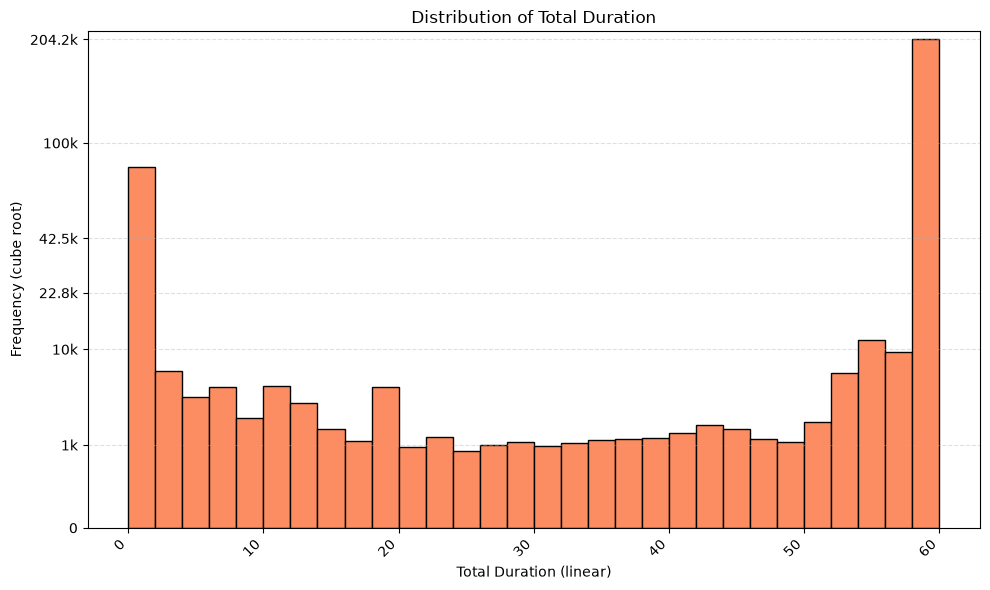

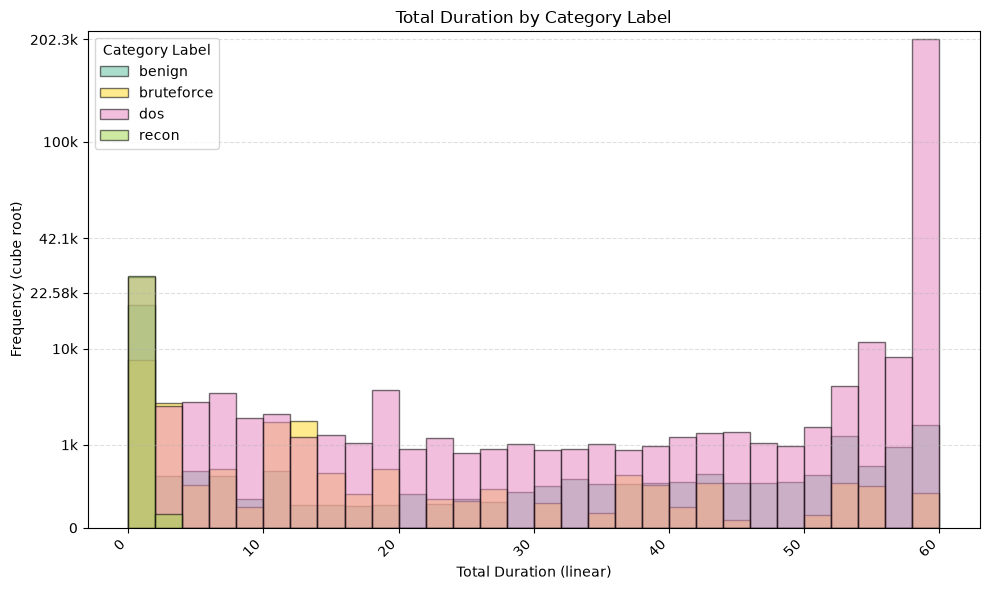

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("total_duration"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Minimum Source Inter-Packet Time,source_interpacket_time_minimum,numeric,predictor,Minimum source inter-packet arrival time in mi...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118956]"
3,minimum,0.0
4,maximum,118955.776
5,mean,3710.488616
6,standard_deviation,12310.193326
7,percentile_05,0.0
8,percentile_25,193.015
9,percentile_50,240.456


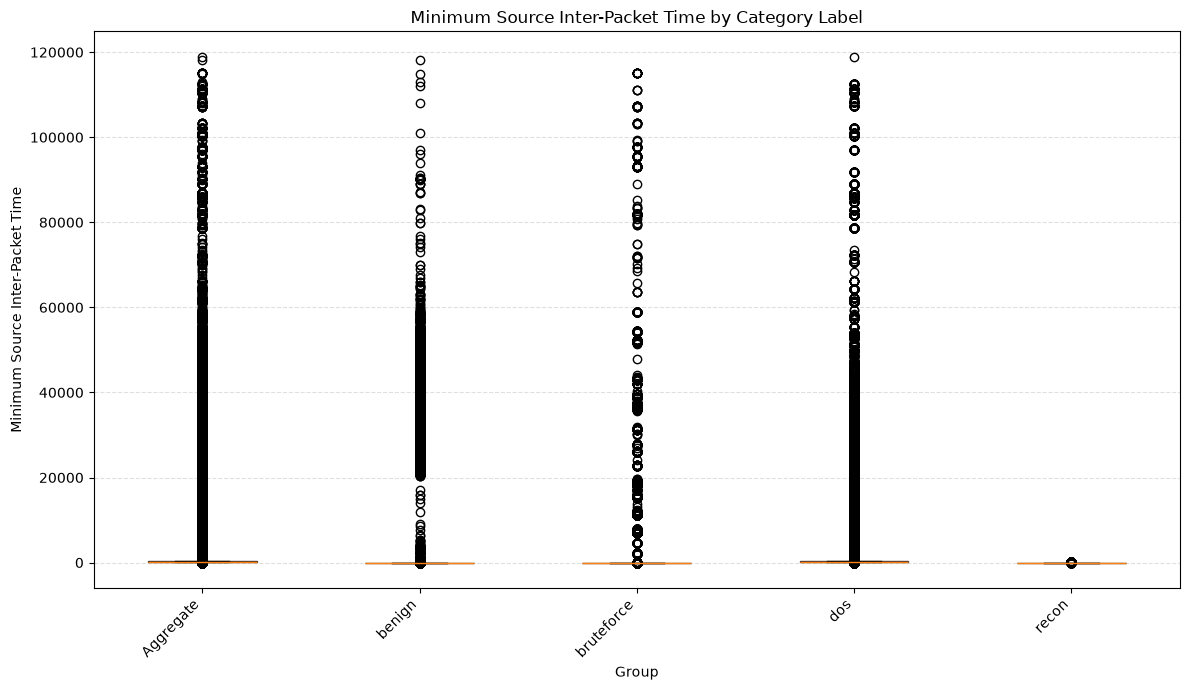

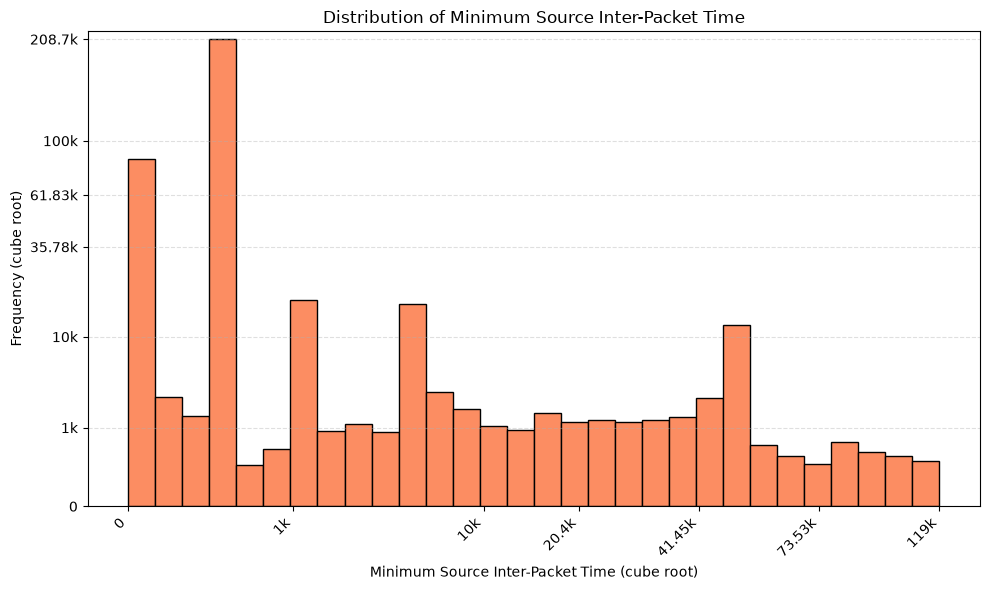

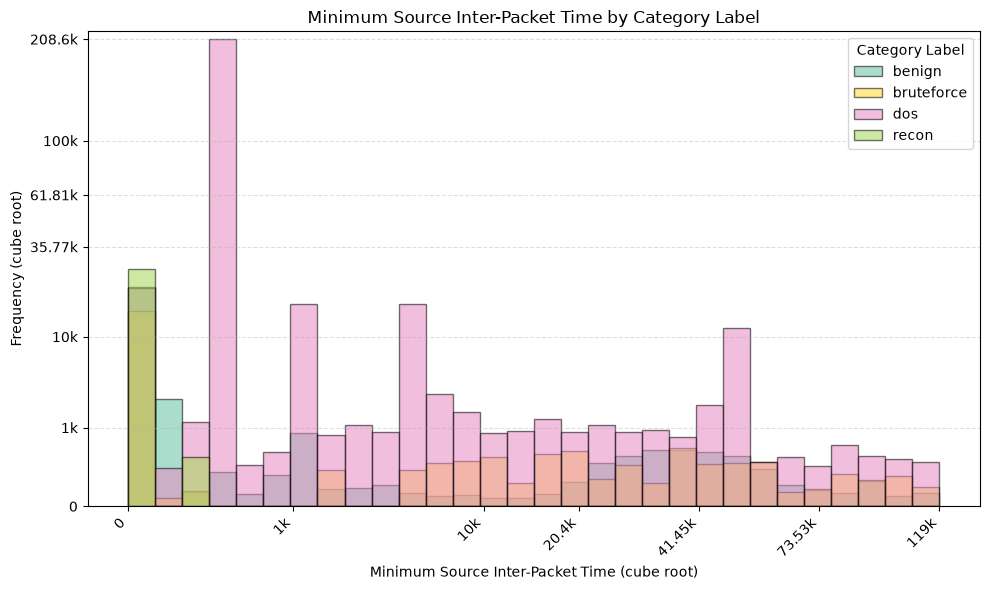

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_interpacket_time_minimum")
)

,name,label,semantic_type,role,description
0,Mean Destination Packet Size,destination_mean_packet_size,numeric,predictor,Mean packet size transmitted by the destination.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 7248.46]"
3,minimum,0.0
4,maximum,7248.461426
5,mean,93.566068
6,standard_deviation,147.14427
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,60.0


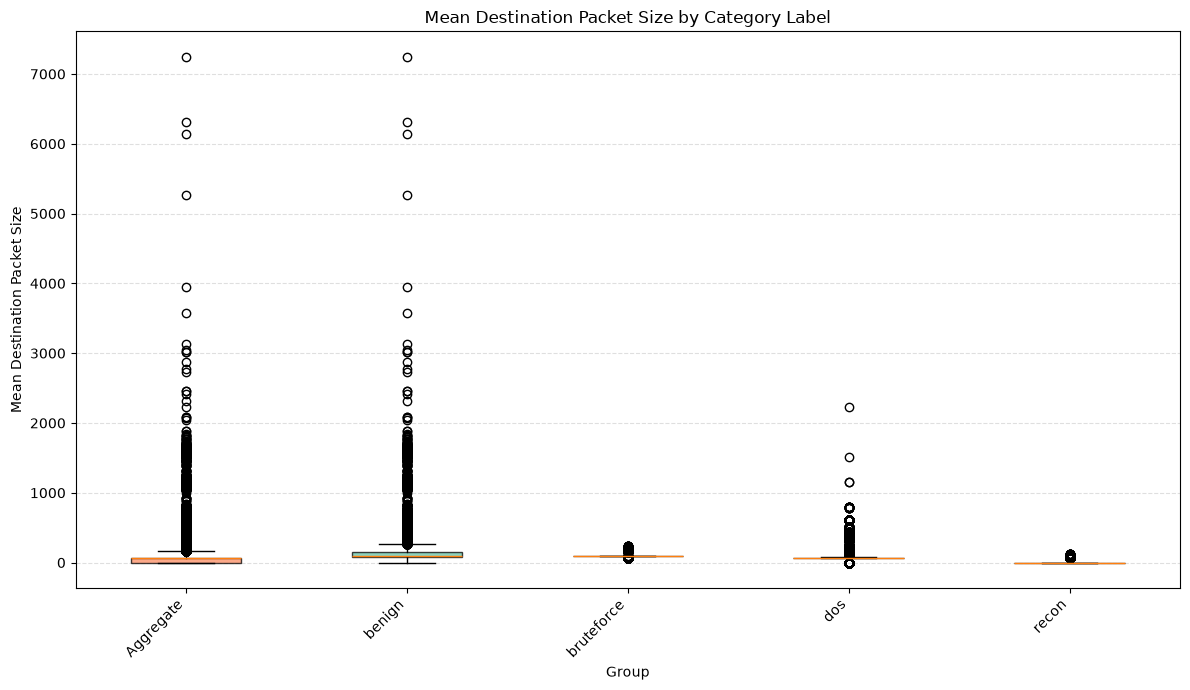

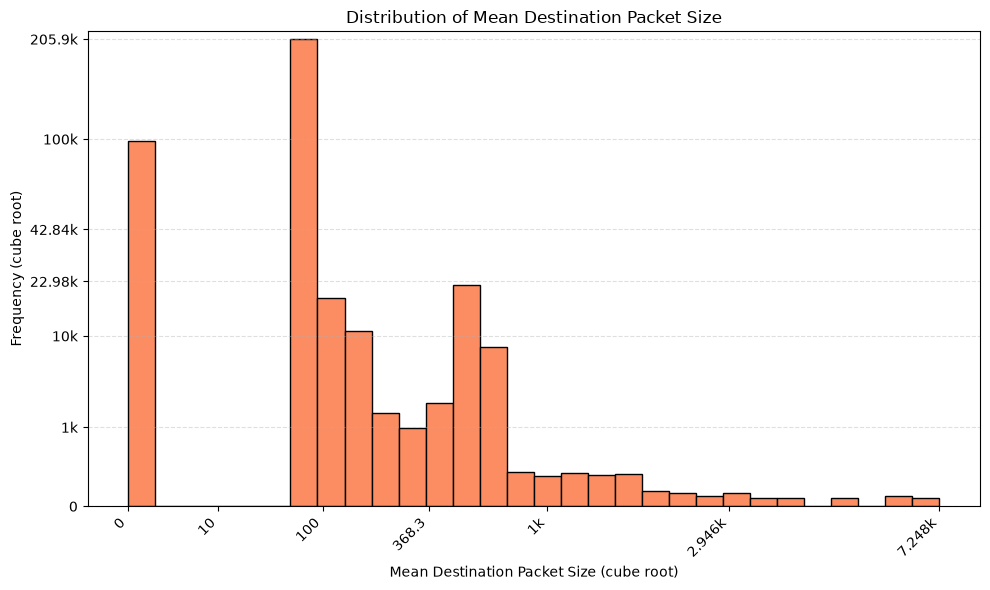

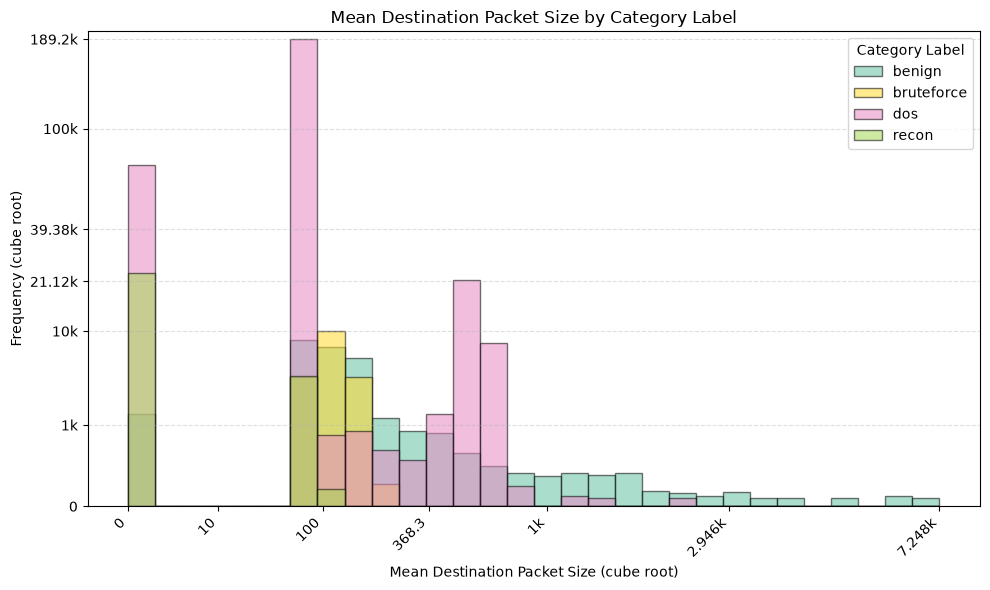

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_mean_packet_size")
)

,name,label,semantic_type,role,description
0,Total Packets,total_packets,numeric,predictor,Total transaction packet count.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[1, 54058]"
3,minimum,1.0
4,maximum,54058.0
5,mean,102.239554
6,standard_deviation,157.101221
7,percentile_05,1.0
8,percentile_25,11.0
9,percentile_50,151.0


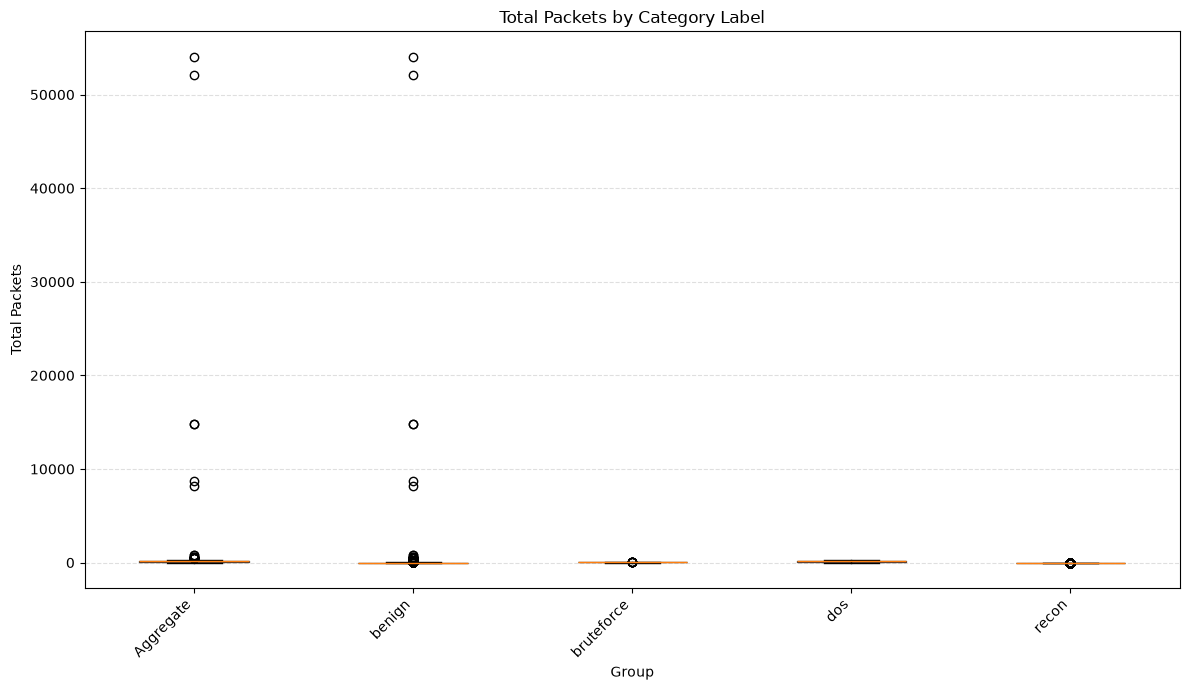

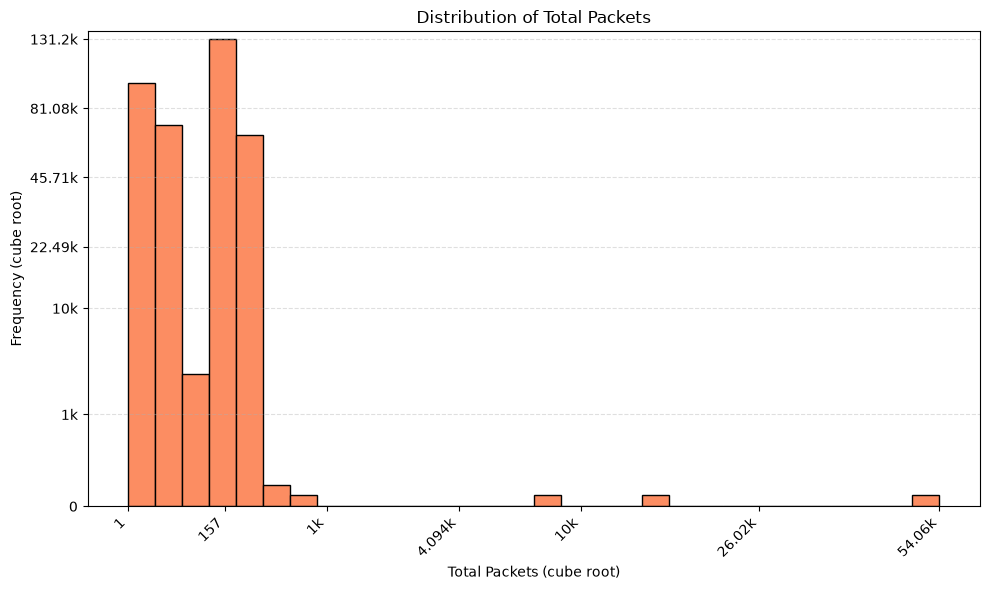

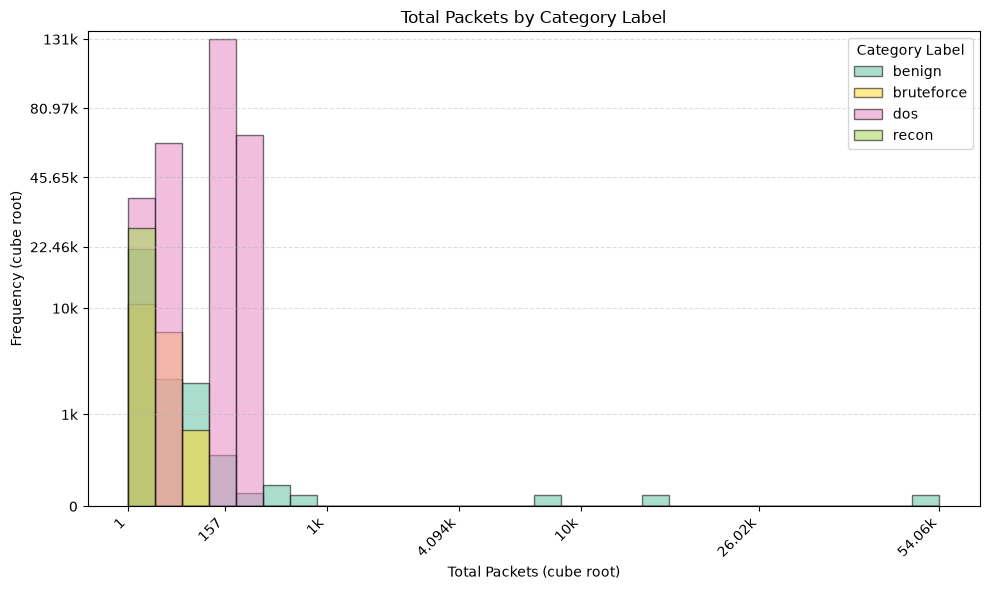

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("total_packets"),
)

,name,label,semantic_type,role,description
0,Source Inter-Packet Time,source_interpacket_time,numeric,predictor,Source inter-packet arrival time in milliseconds.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118160]"
3,minimum,0.0
4,maximum,118160.208
5,mean,3955.606241
6,standard_deviation,12119.016326
7,percentile_05,0.0
8,percentile_25,386.02275
9,percentile_50,393.026344


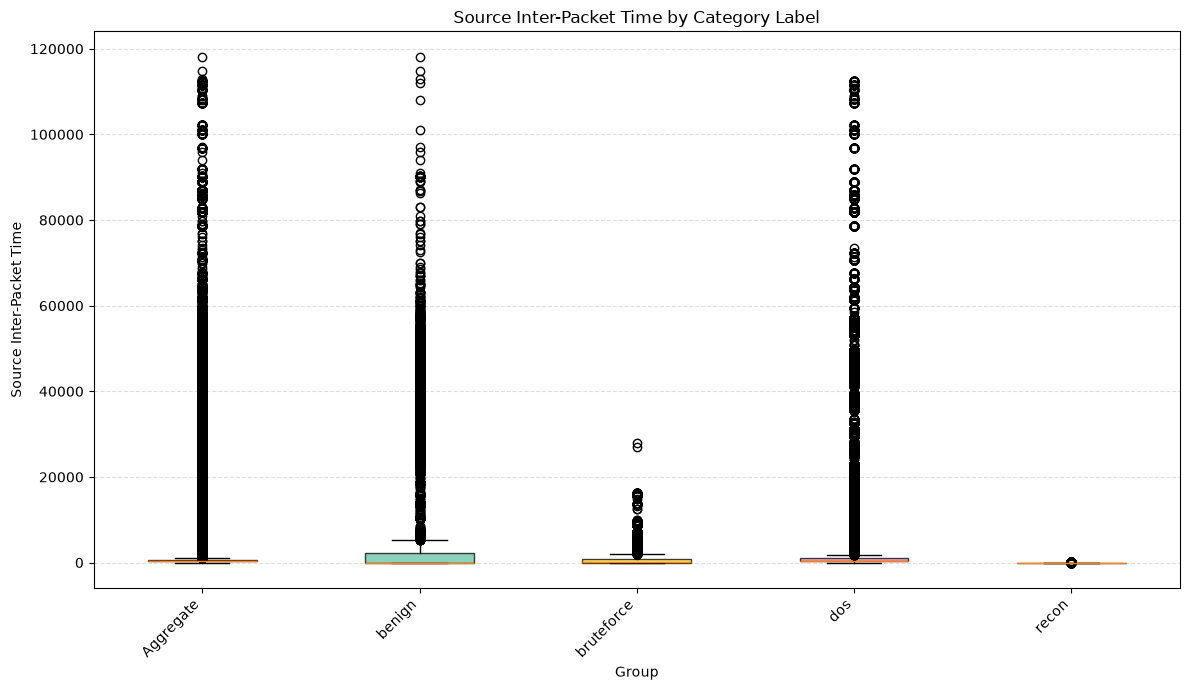

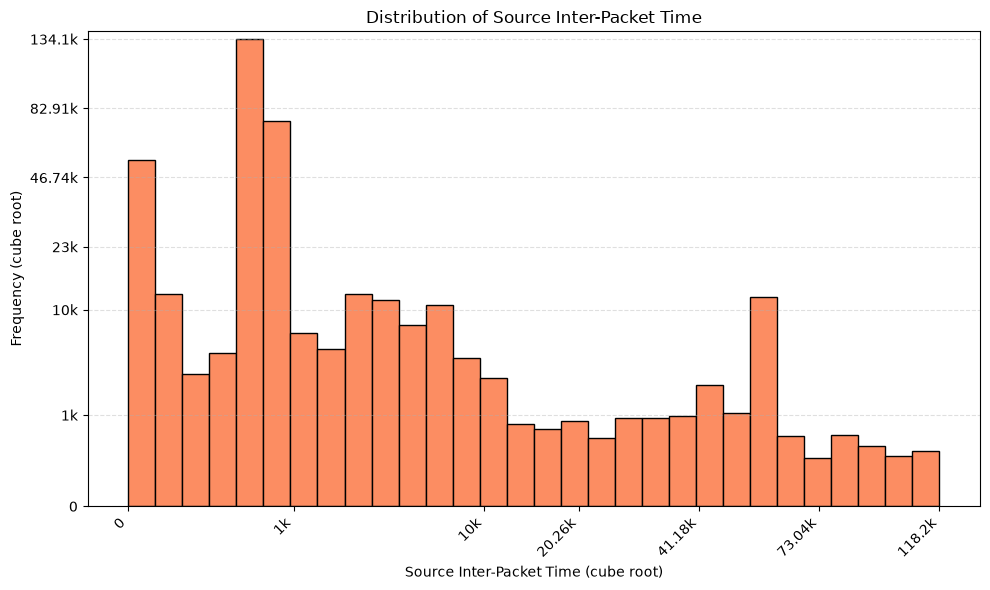

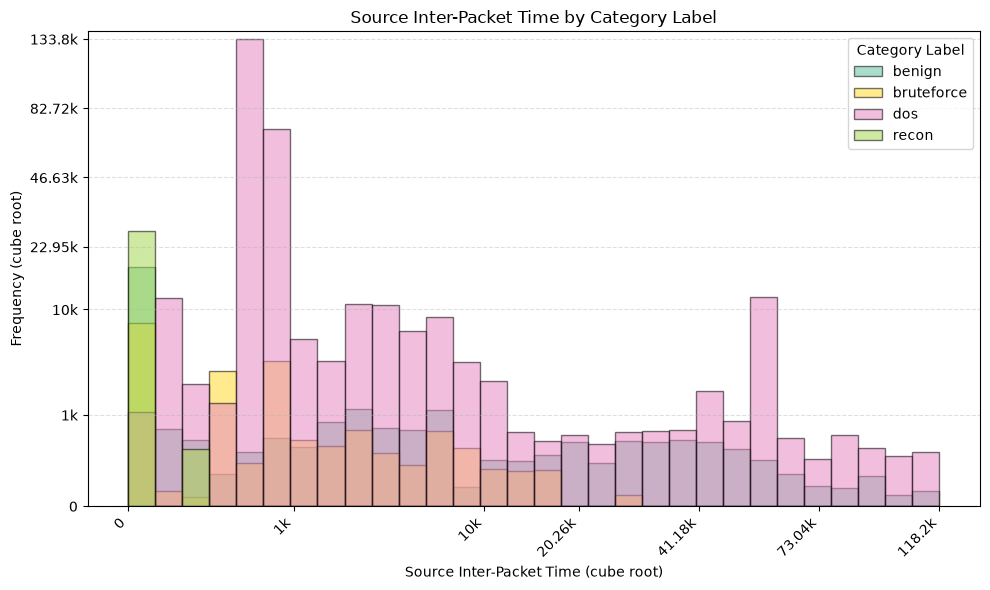

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_interpacket_time"),
)

,name,label,semantic_type,role,description
0,Destination Application Bytes,destination_application_bytes,numeric,predictor,Application bytes transmitted from destination...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 7.72748e+07]"
3,minimum,0.0
4,maximum,77274816.0
5,mean,1074.605577
6,standard_deviation,192967.011842
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


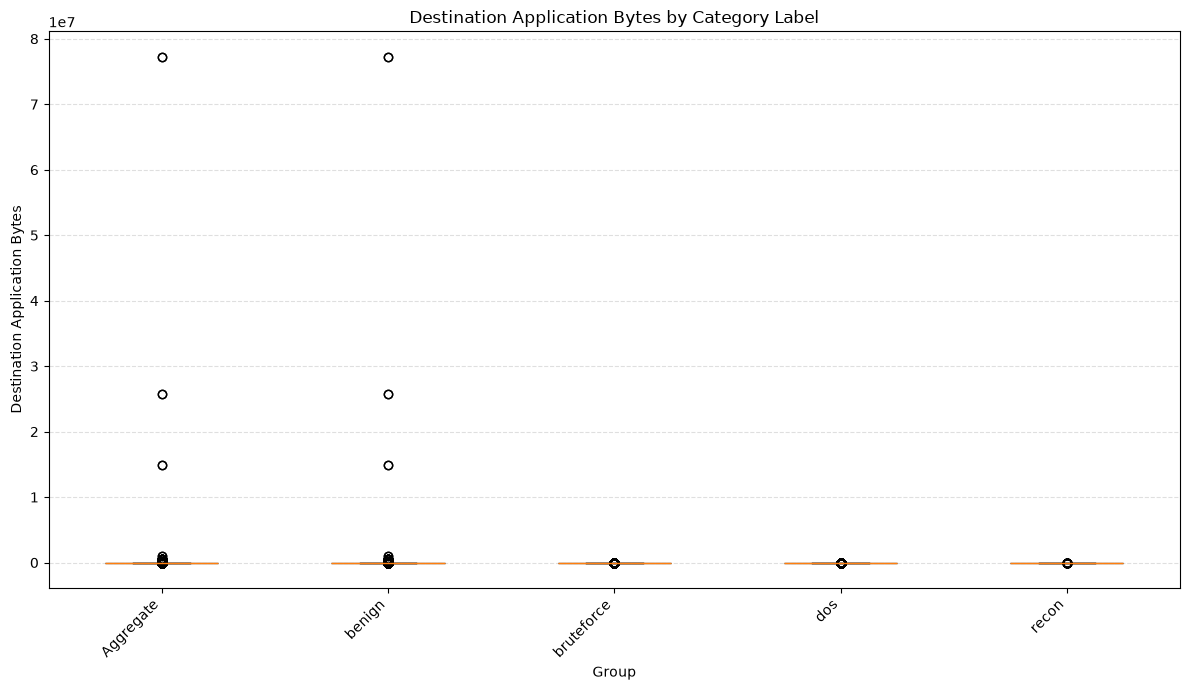

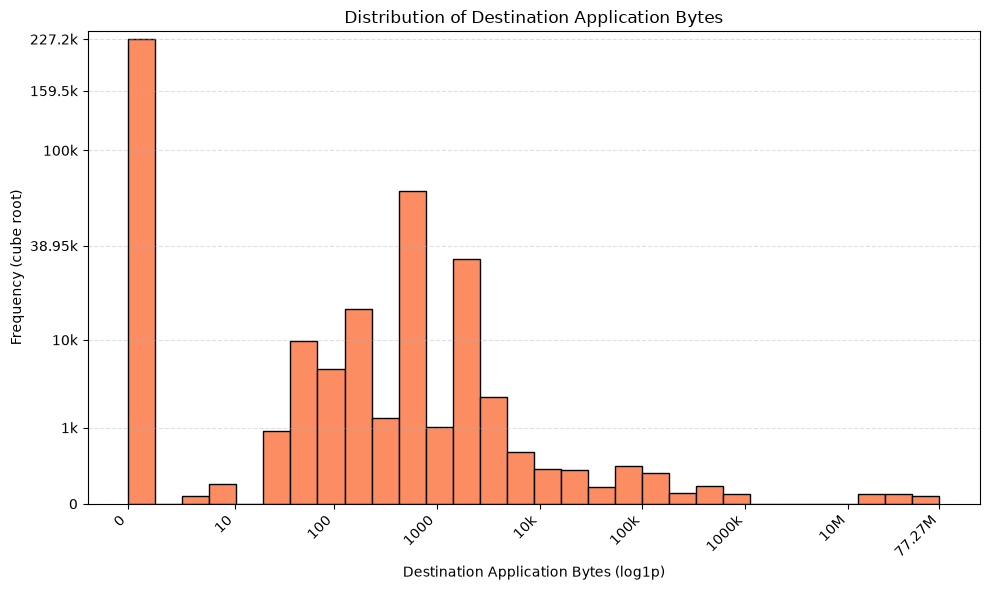

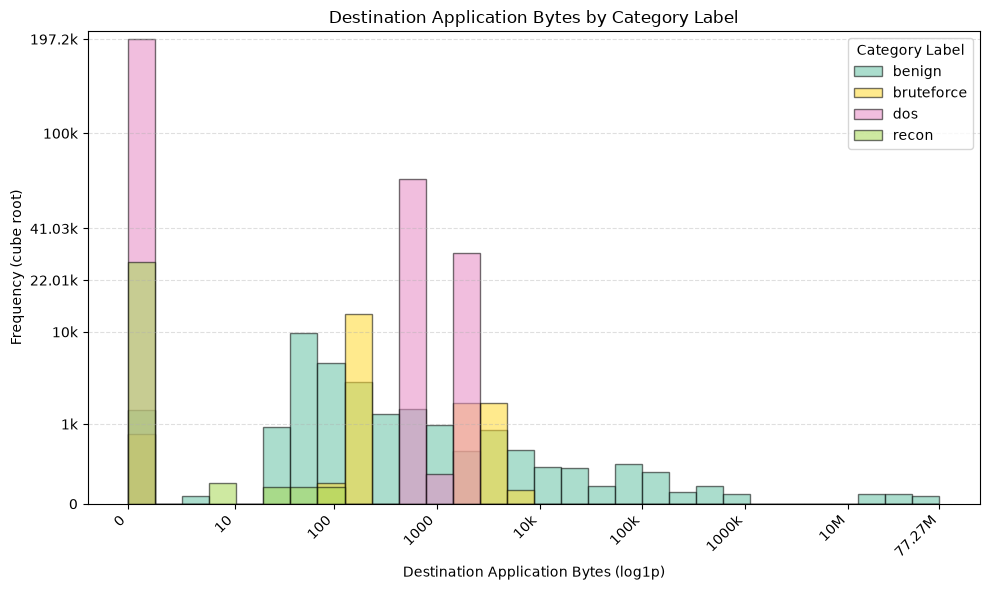

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_application_bytes"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Active Source Inter-Packet Time,source_interpacket_time_active,numeric,predictor,Source active inter-packet arrival time in mil...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 118956]"
3,minimum,0.0
4,maximum,118955.776
5,mean,1073.793489
6,standard_deviation,5075.815034
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


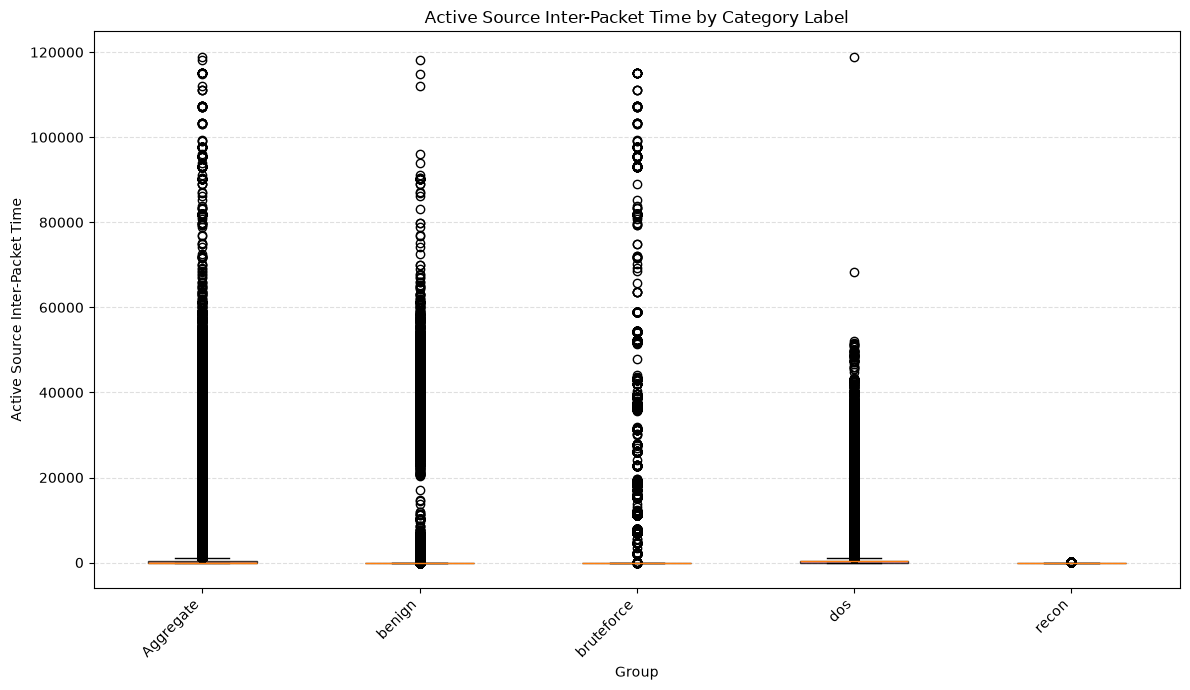

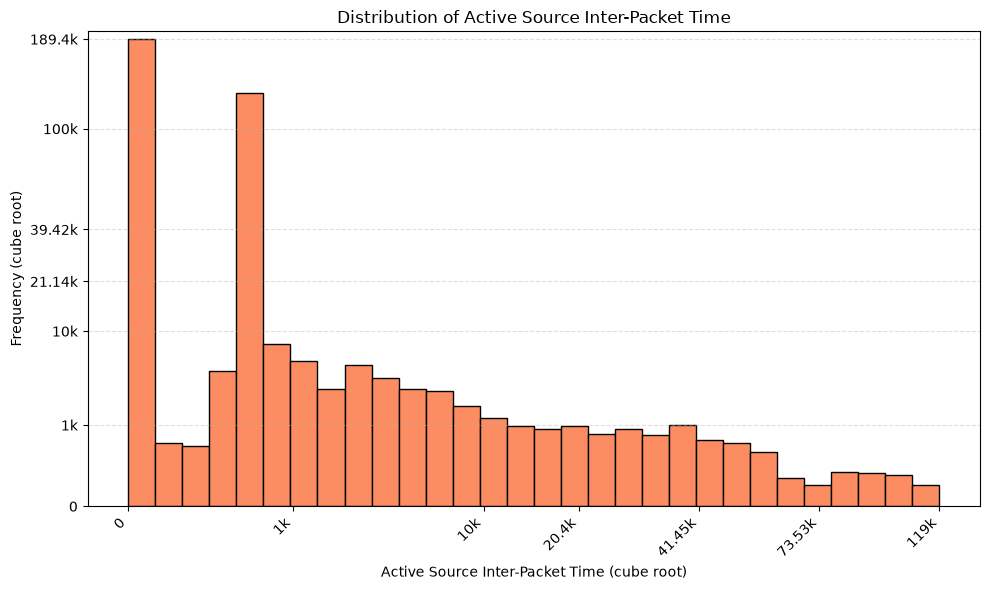

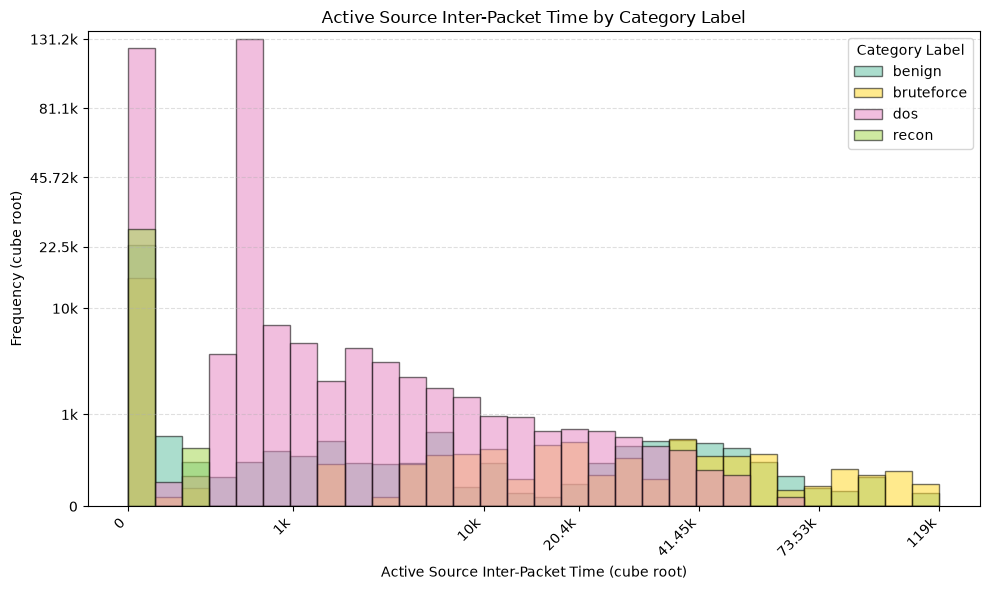

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_interpacket_time_active")
)

,name,label,semantic_type,role,description
0,Producer-Consumer Ratio,producer_consumer_ratio,numeric,predictor,Producer-consumer traffic ratio.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[-1, 1]"
3,minimum,-1.0
4,maximum,1.0
5,mean,0.168016
6,standard_deviation,0.464955
7,percentile_05,-0.710568
8,percentile_25,-0.0
9,percentile_50,-0.0


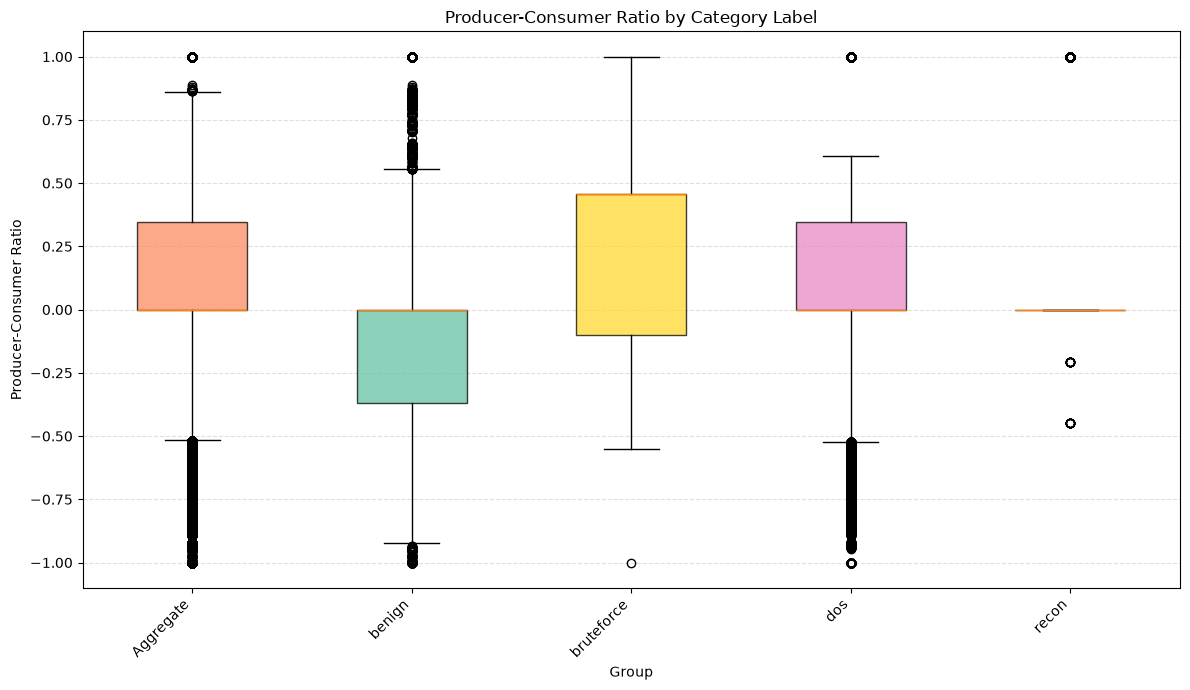

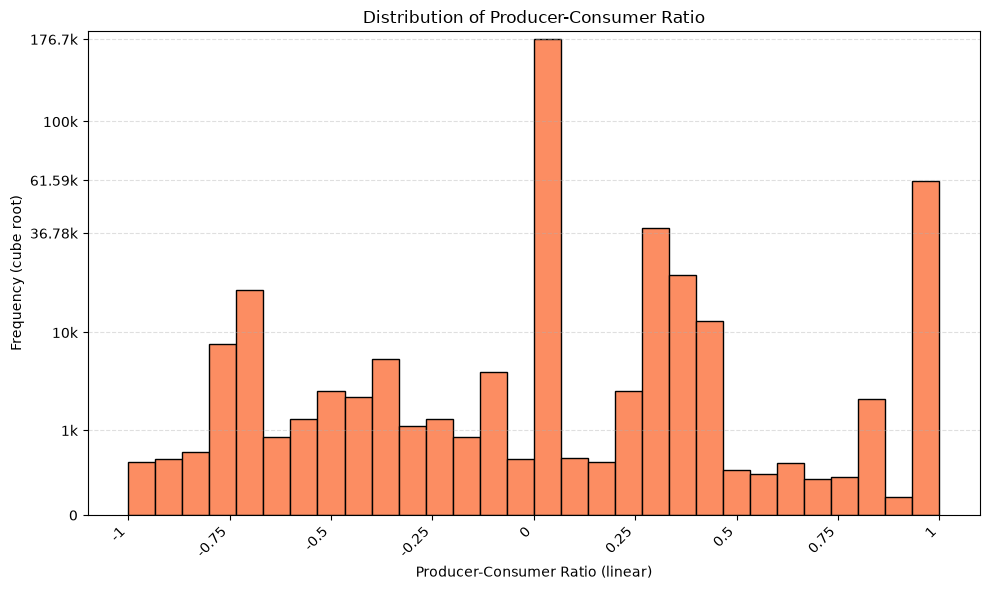

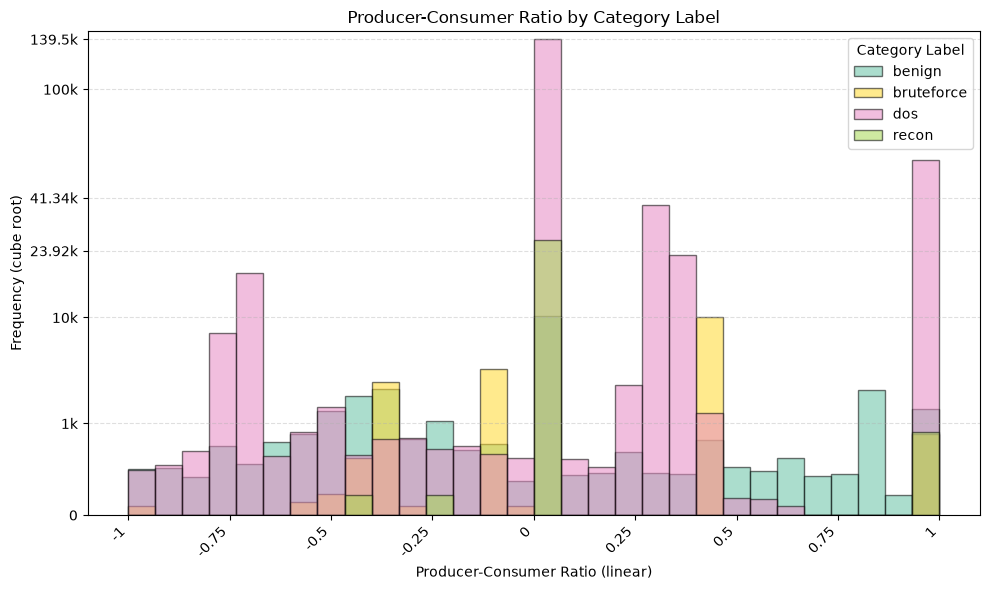

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("producer_consumer_ratio"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Destination TCP Window,destination_window_in_bytes,numeric,predictor,Destination TCP window advertisement.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 1.6777e+07]"
3,minimum,0.0
4,maximum,16776960.0
5,mean,208977.105816
6,standard_deviation,591322.453085
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


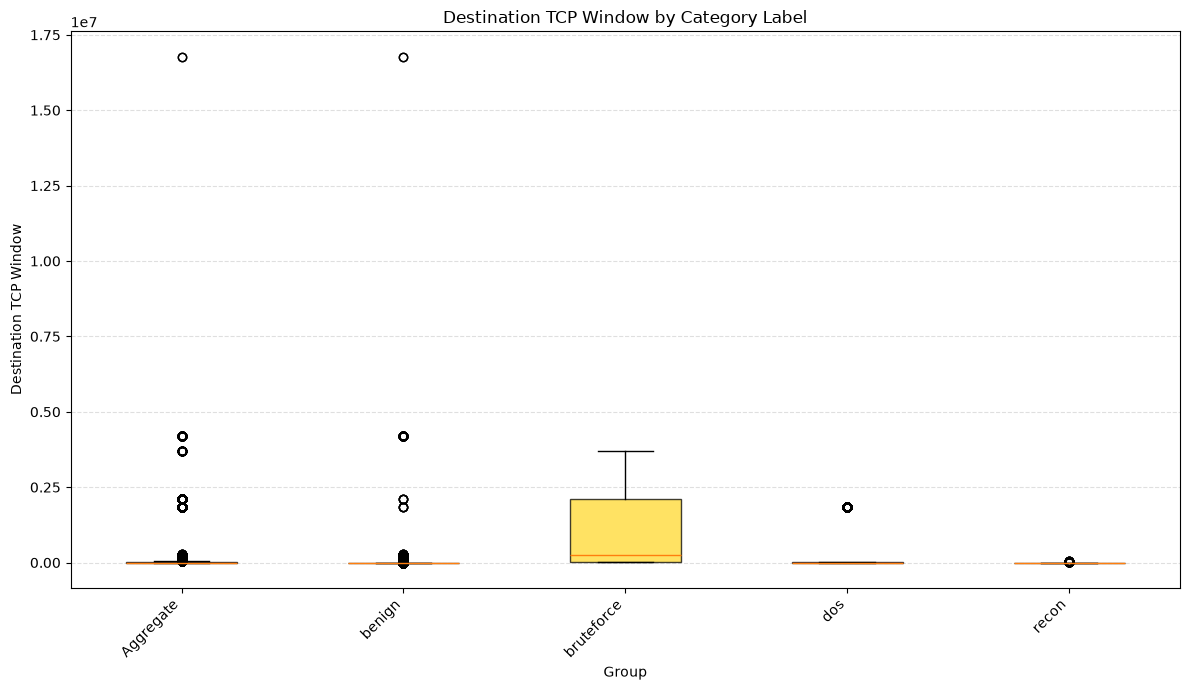

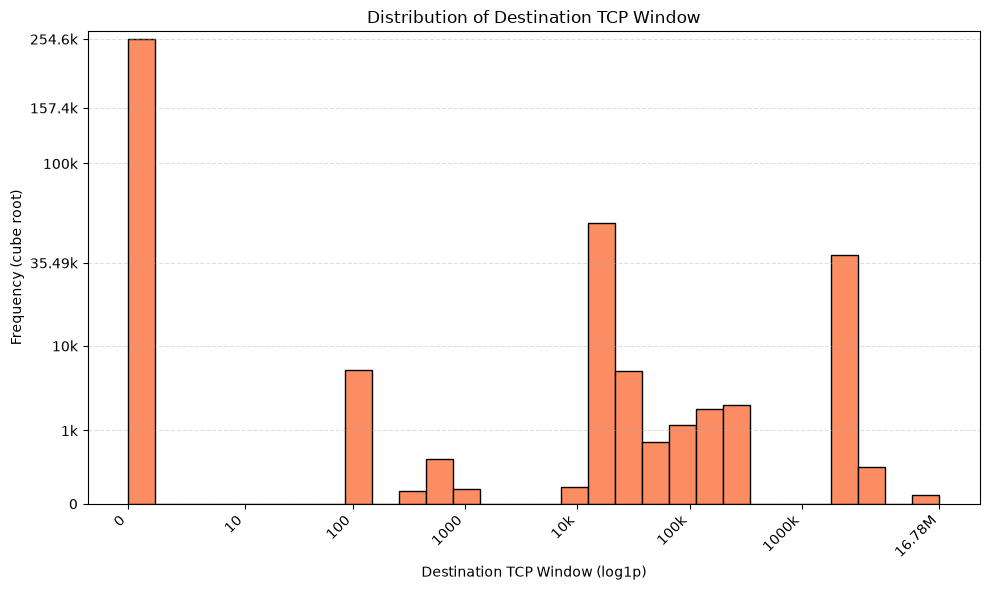

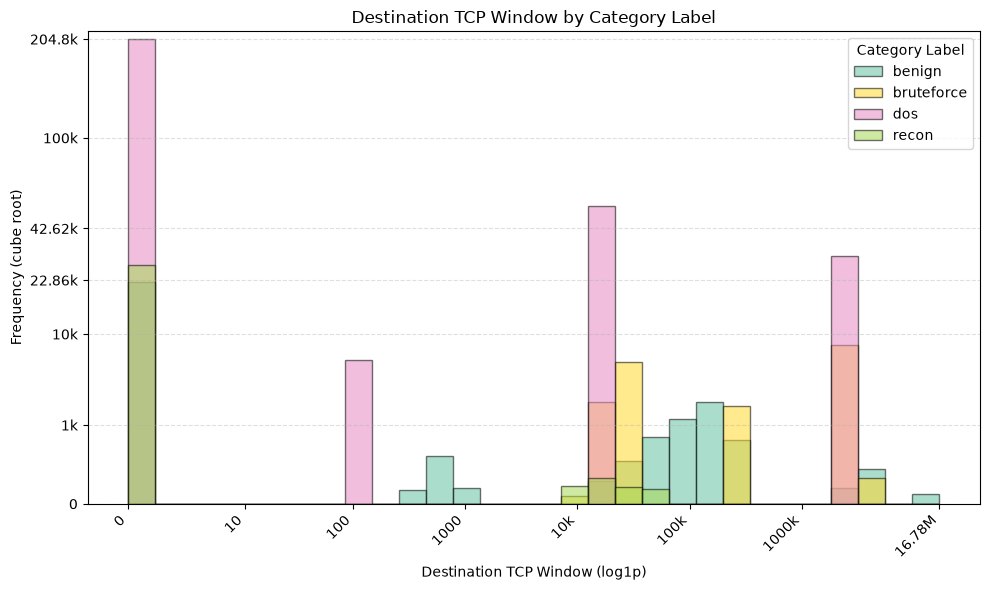

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_window_in_bytes"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Minimum Destination Packet Size,destination_minimum_packet_size,numeric,predictor,Minimum packet size transmitted by the destina...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 2235]"
3,minimum,0.0
4,maximum,2235.0
5,mean,49.251245
6,standard_deviation,37.13232
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,60.0


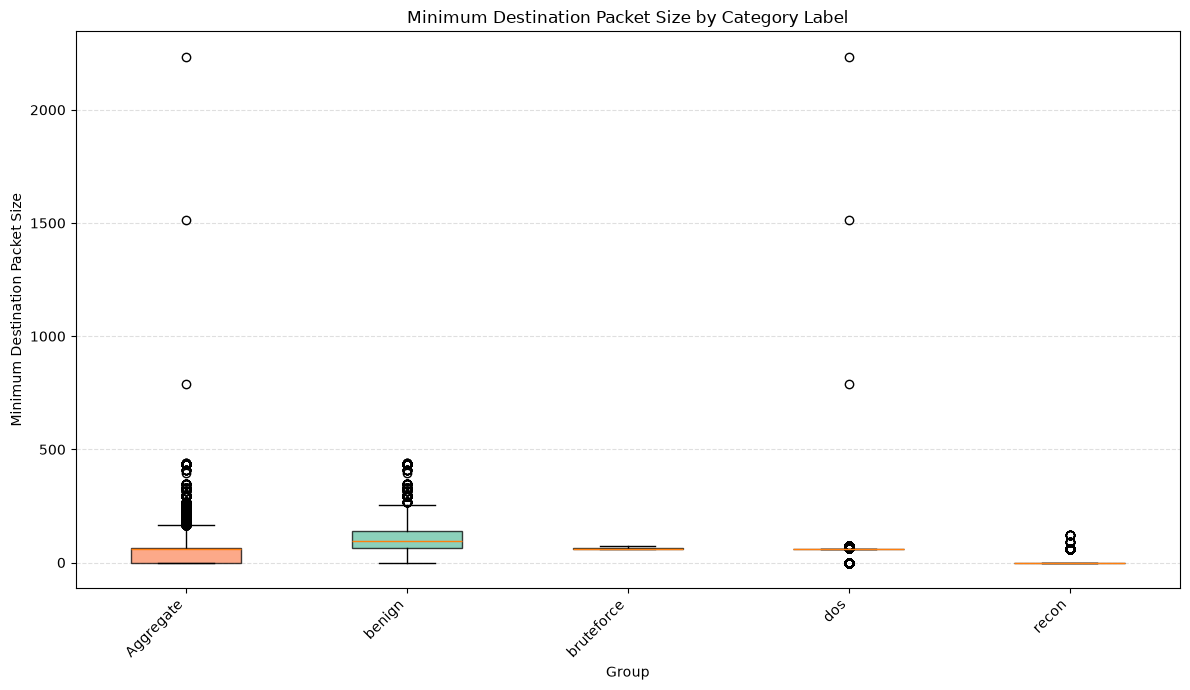

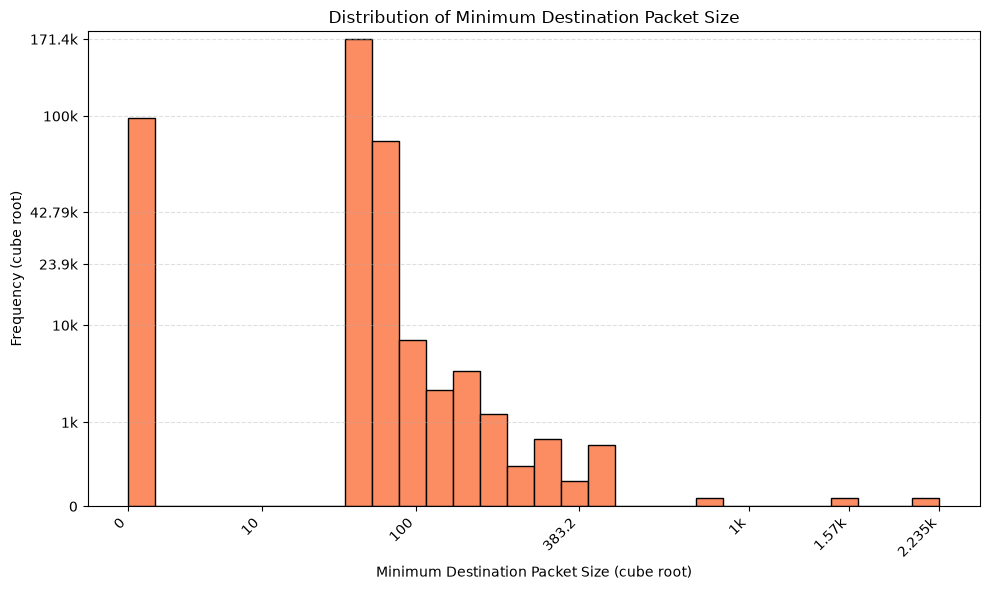

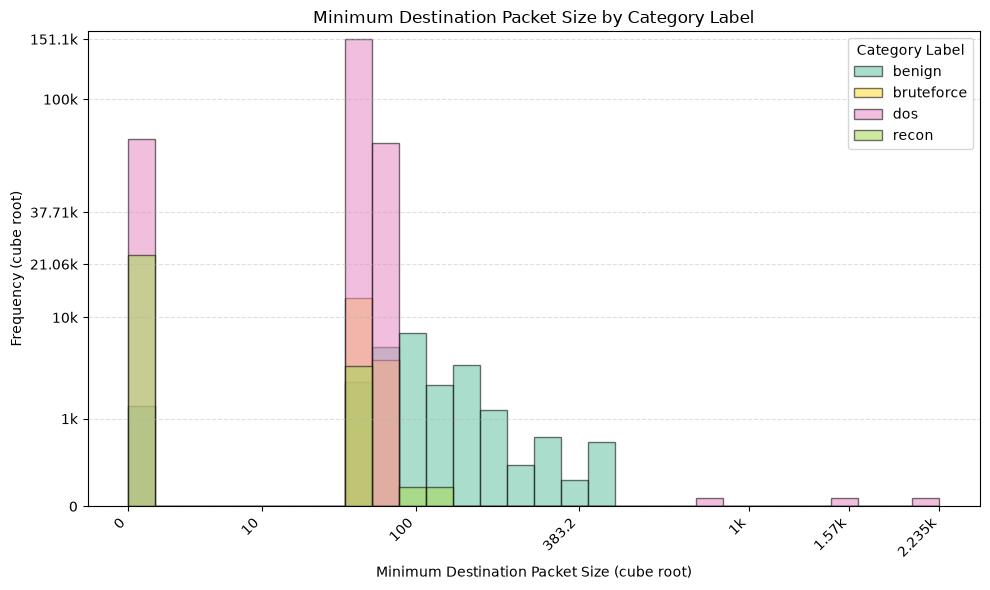

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_minimum_packet_size")
)

,name,label,semantic_type,role,description
0,Source Active Jitter,source_active_jitter,numeric,predictor,Source active jitter in milliseconds.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 51977.8]"
3,minimum,0.0
4,maximum,51977.764
5,mean,245.345452
6,standard_deviation,1352.573263
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


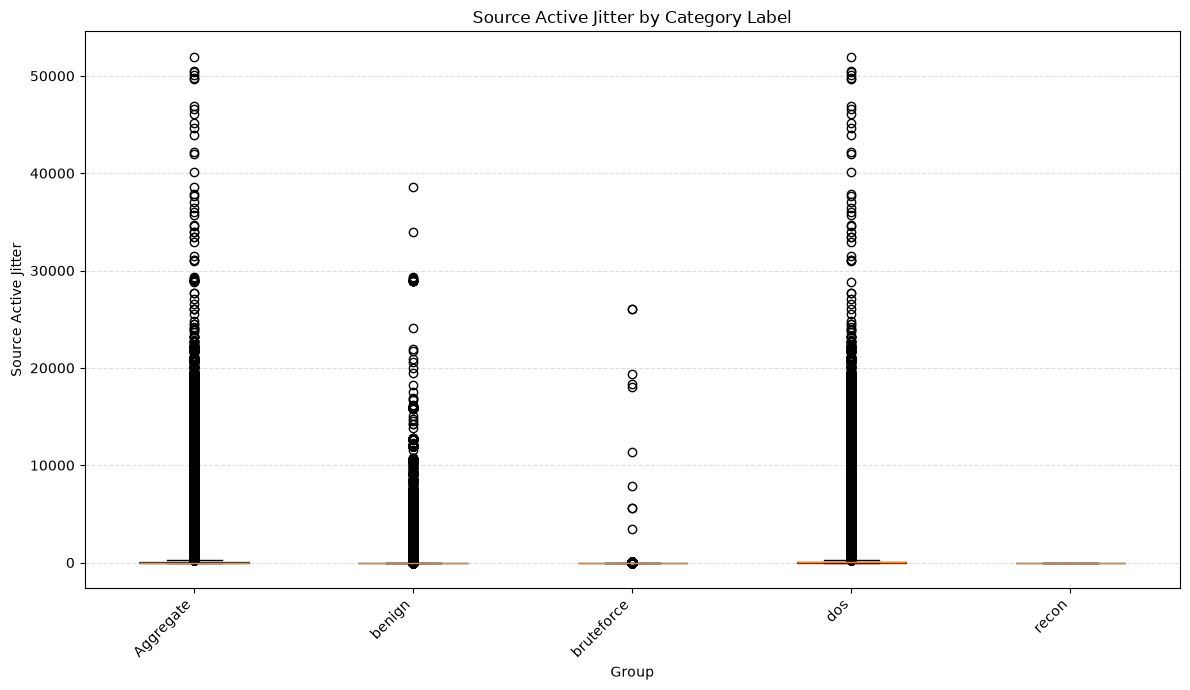

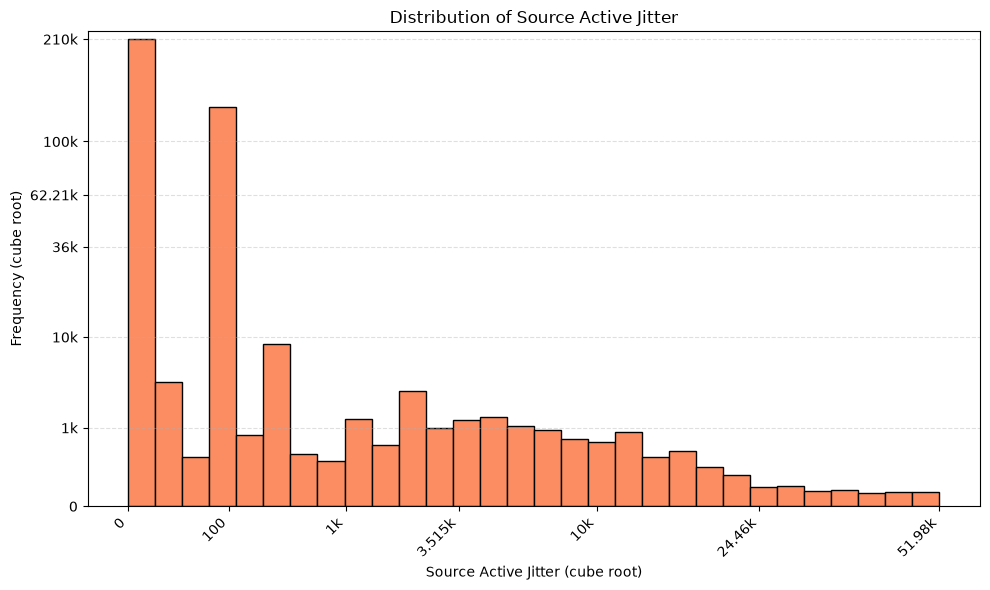

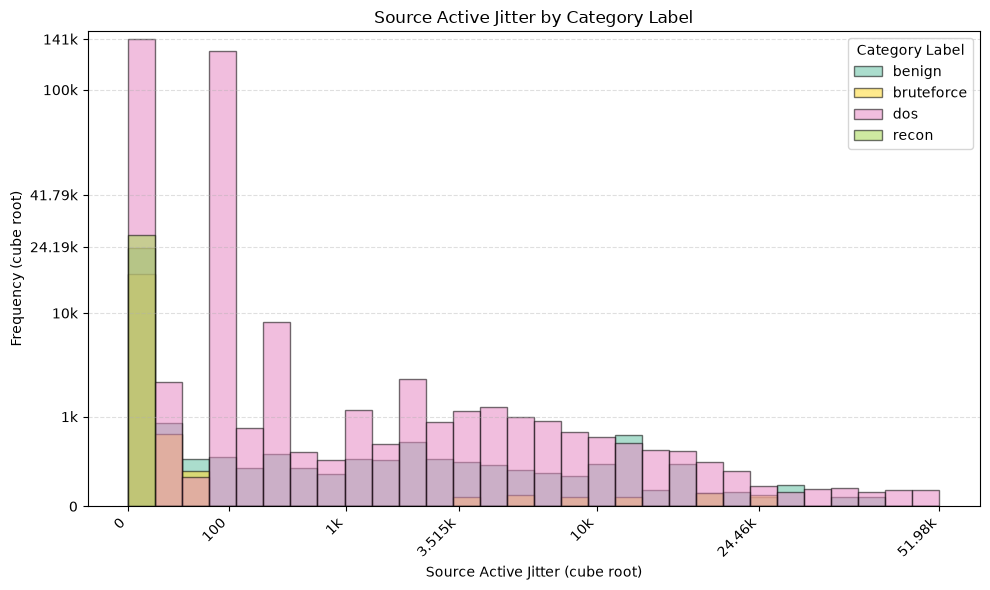

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_active_jitter"),
)

,name,label,semantic_type,role,description
0,Maximum Destination Packet Size,destination_maximum_packet_size,numeric,predictor,Maximum packet size transmitted by the destina...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 26130]"
3,minimum,0.0
4,maximum,26130.0
5,mean,204.75099
6,standard_deviation,483.439797
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,60.0


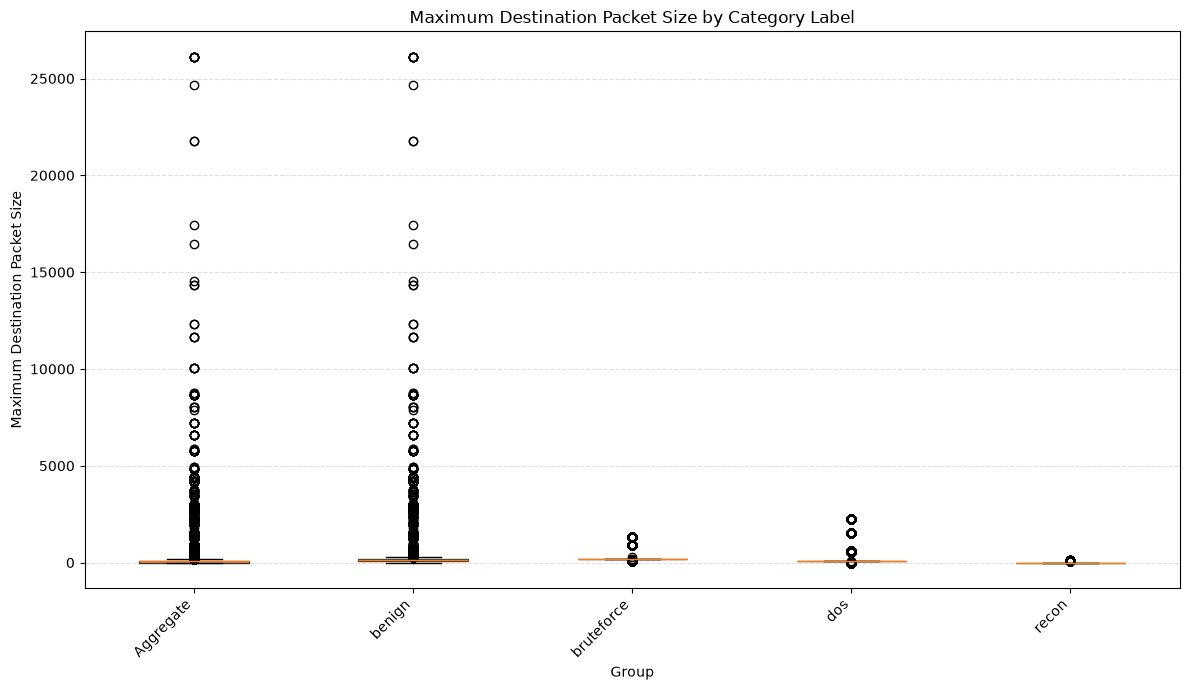

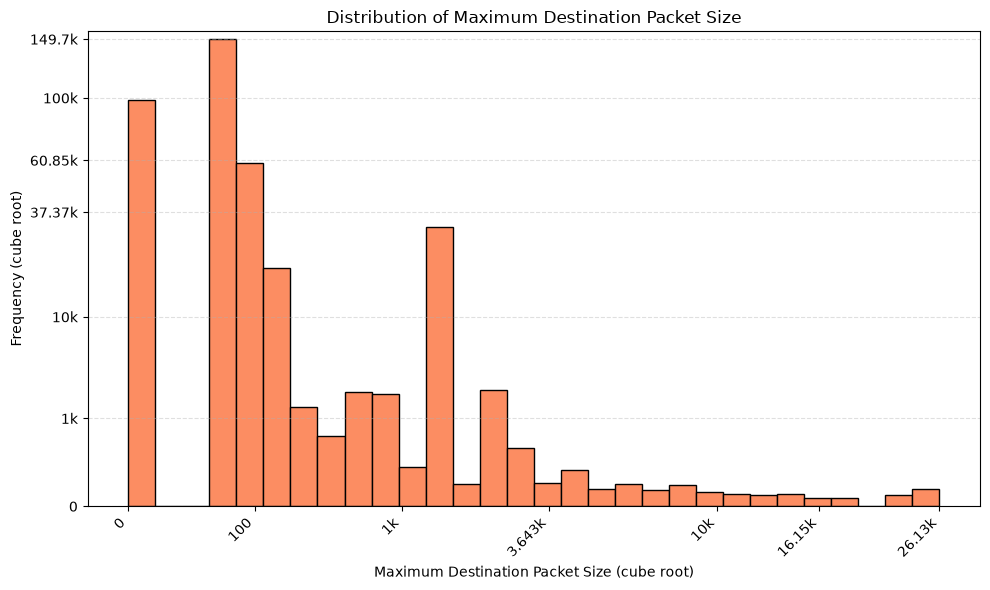

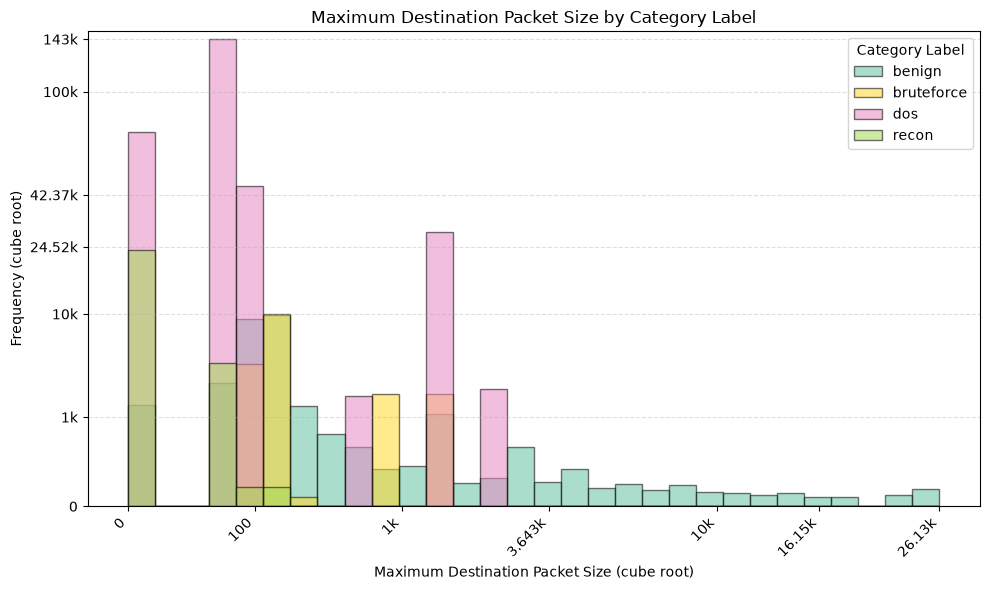

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_maximum_packet_size")
)

,name,label,semantic_type,role,description
0,Mean Source Packet Size,source_mean_packet_size,numeric,predictor,Mean packet size transmitted by the source.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 805]"
3,minimum,0.0
4,maximum,805.0
5,mean,91.42851
6,standard_deviation,65.210148
7,percentile_05,60.0
8,percentile_25,60.0
9,percentile_50,60.0


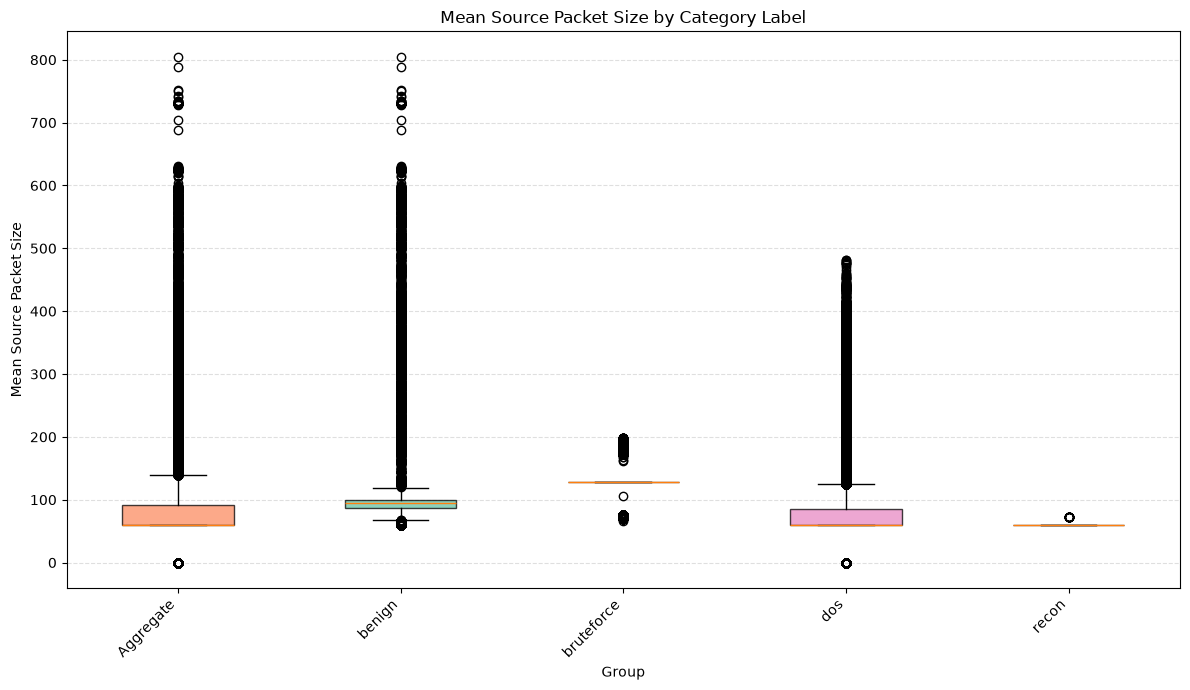

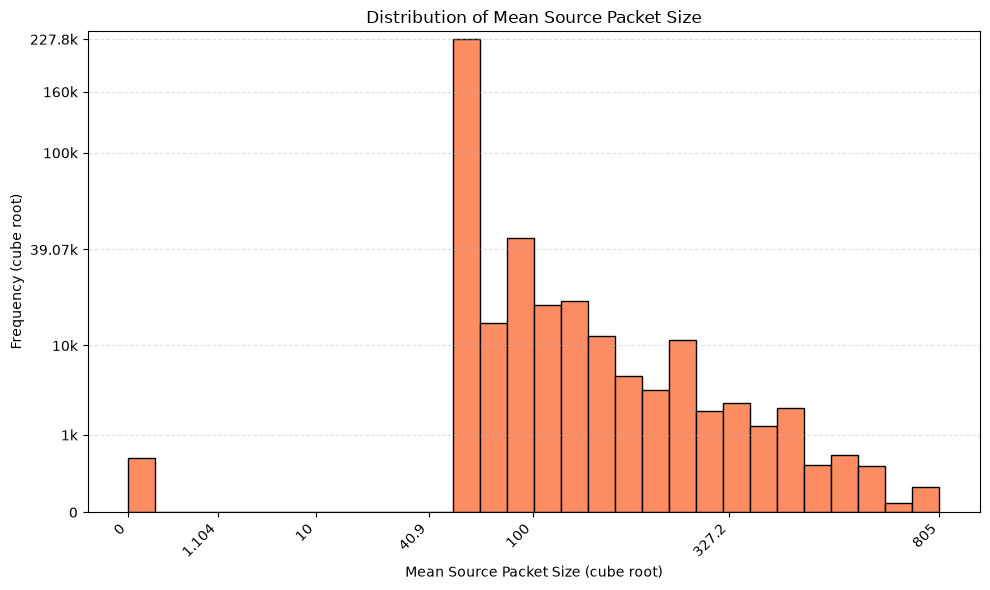

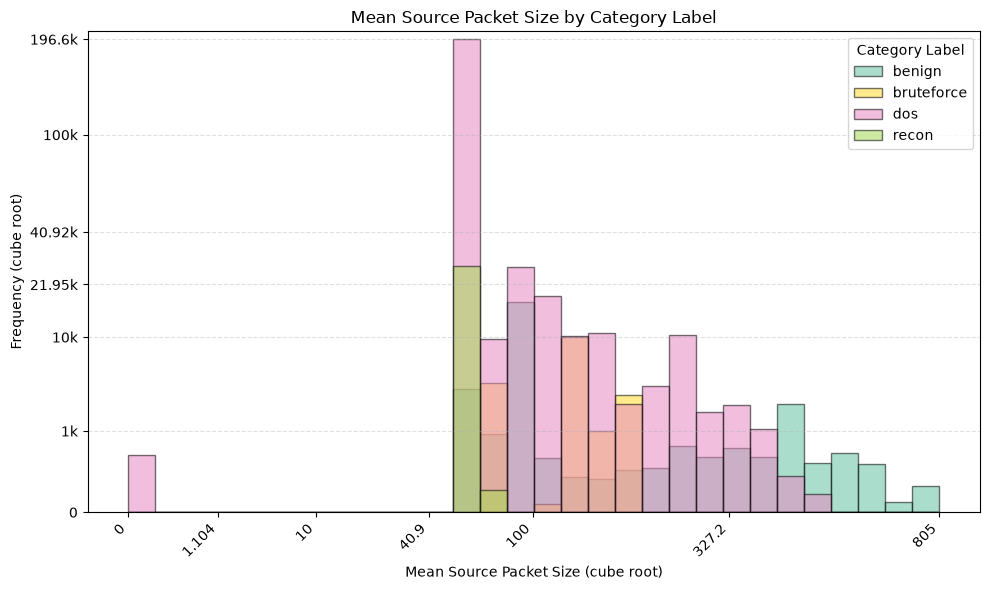

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_mean_packet_size"),
)

,name,label,semantic_type,role,description
0,Destination Jitter,destination_jitter,numeric,predictor,Destination jitter in milliseconds.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 1.12324e+06]"
3,minimum,0.0
4,maximum,1123242.184973
5,mean,5185.510018
6,standard_deviation,36977.856368
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,508.484468


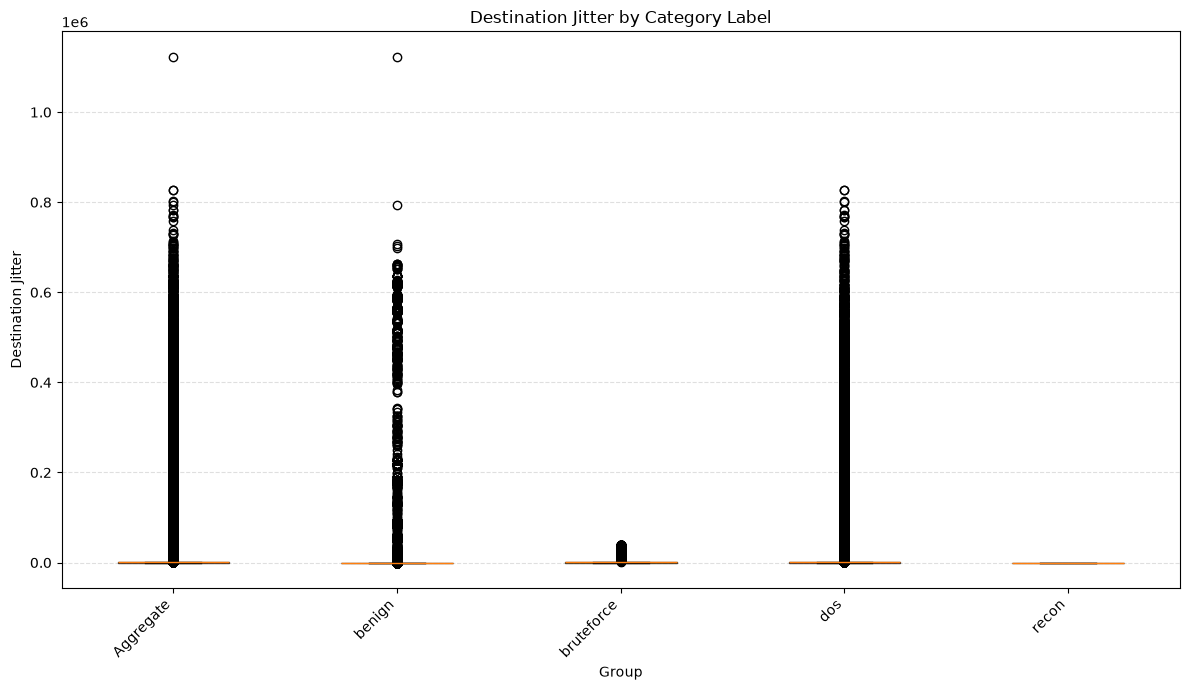

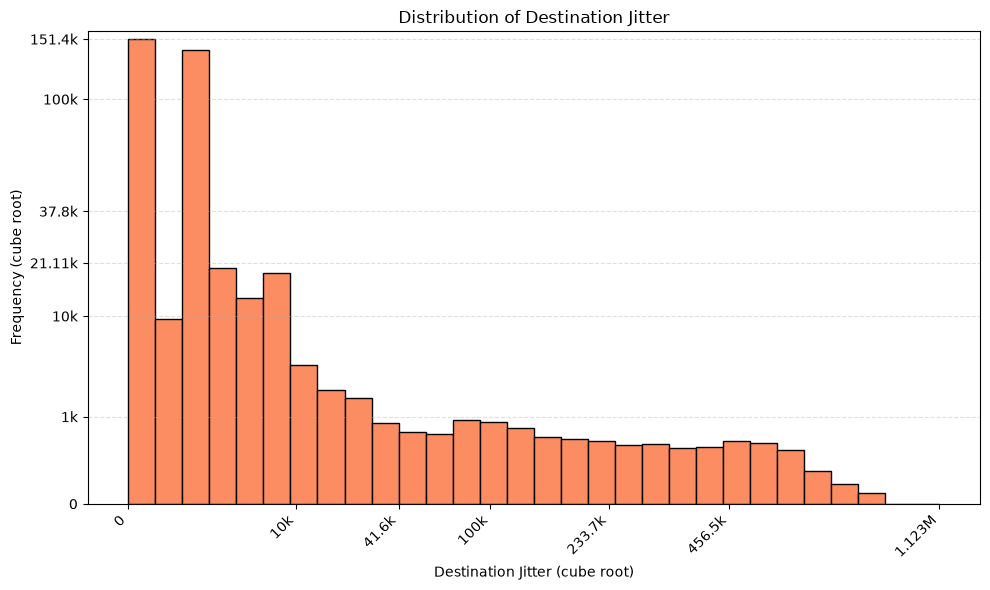

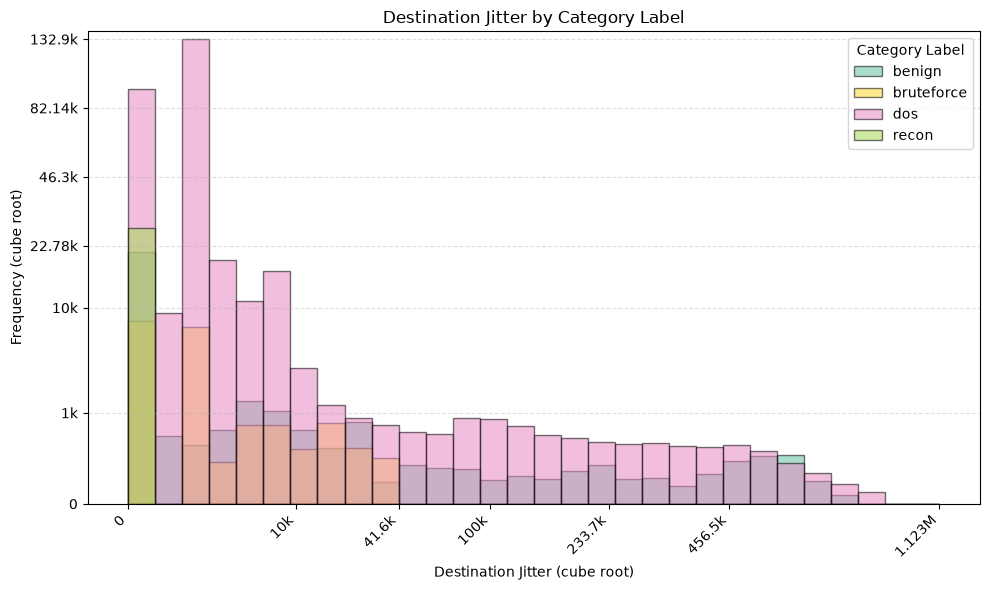

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_jitter"),
)

,name,label,semantic_type,role,description
0,Packet Loss Percentage,packet_loss_percentage,numeric,predictor,Percentage of packets retransmitted or dropped.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 53.3333]"
3,minimum,0.0
4,maximum,53.333333
5,mean,3.44882
6,standard_deviation,10.970203
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


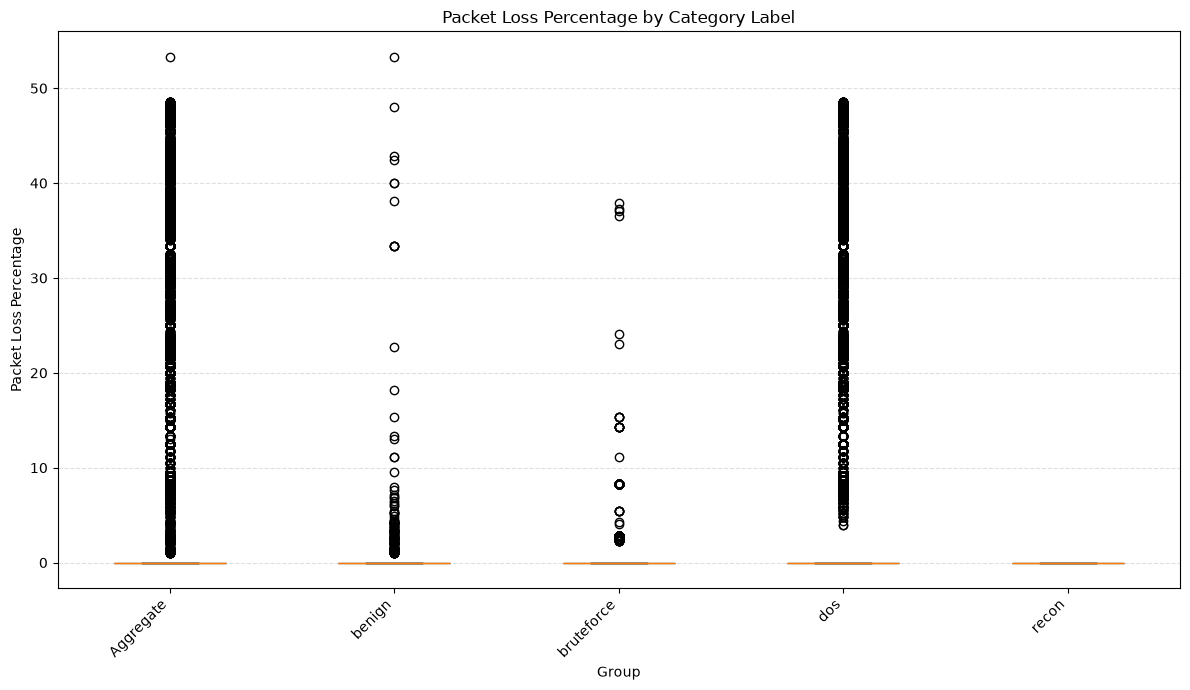

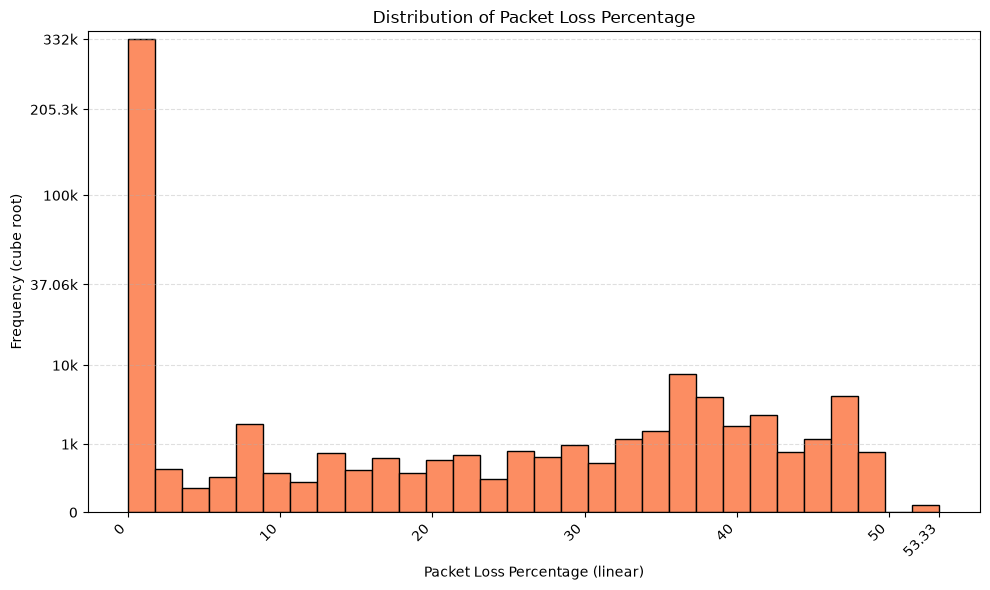

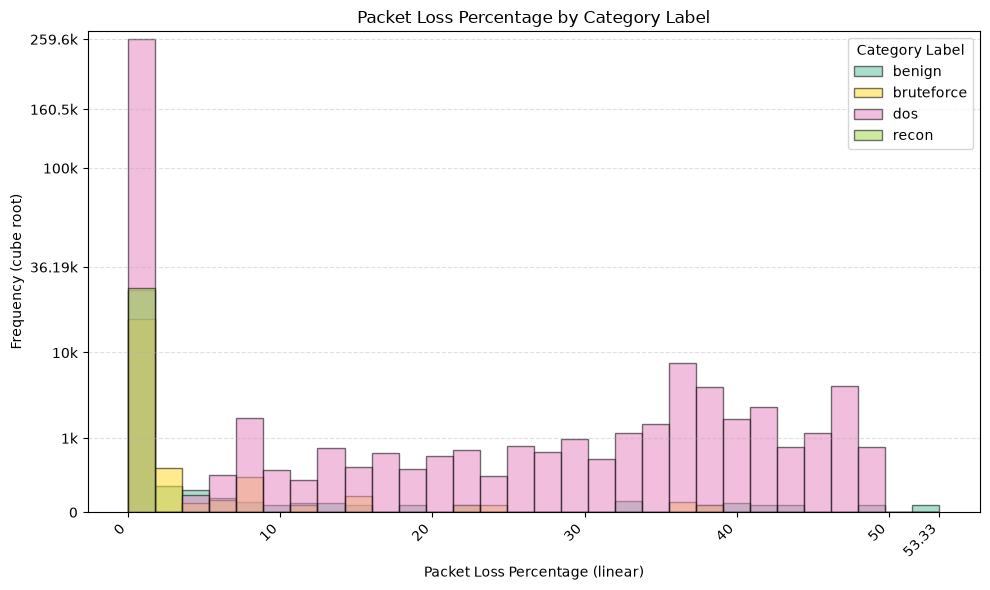

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("packet_loss_percentage"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Source Jitter,source_jitter,numeric,predictor,Source jitter in milliseconds.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 1.26258e+06]"
3,minimum,0.0
4,maximum,1262583.388931
5,mean,19745.300069
6,standard_deviation,77158.00962
7,percentile_05,0.0
8,percentile_25,86.180744
9,percentile_50,101.820715


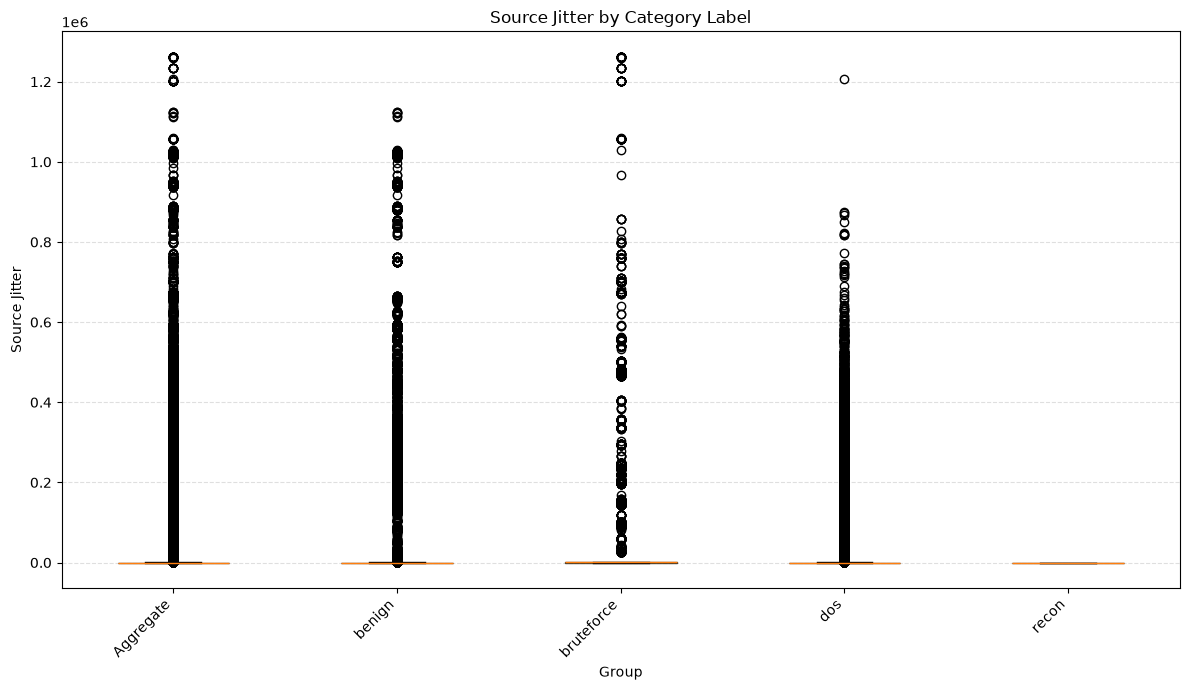

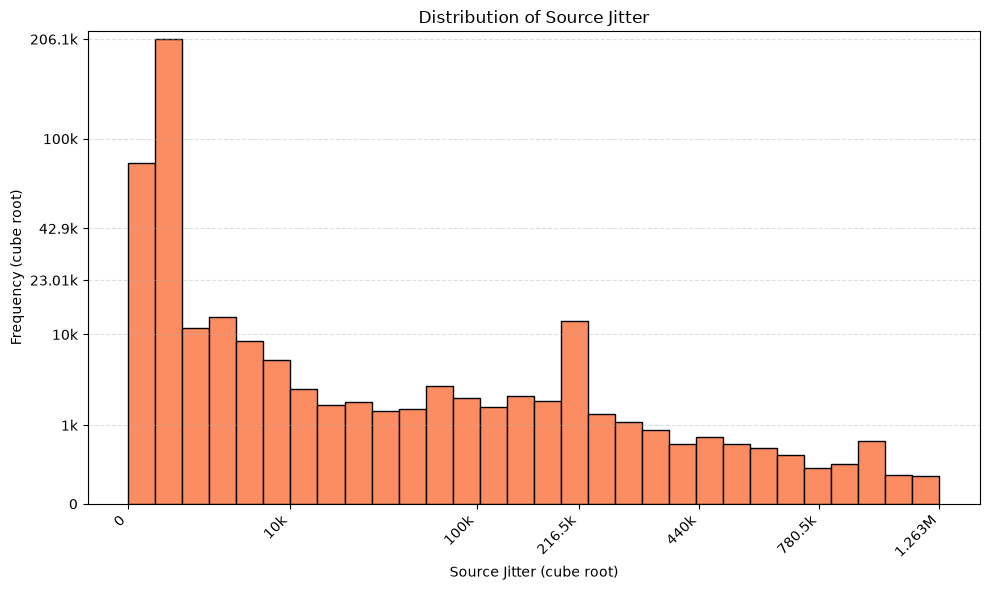

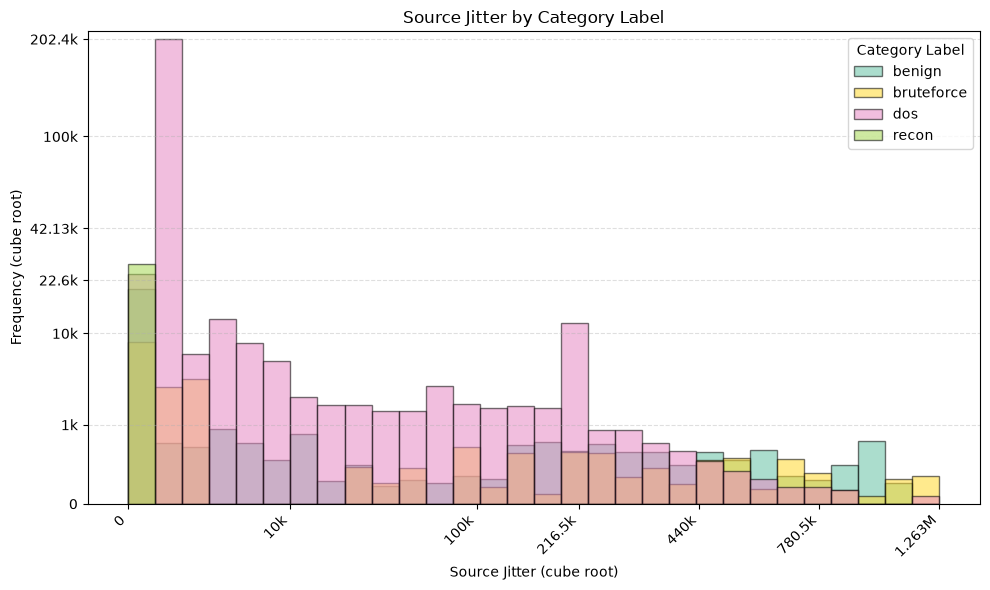

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_jitter"),
)

,name,label,semantic_type,role,description
0,Record Duration,duration,numeric,predictor,Total duration of the record.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 59.9993]"
3,minimum,0.0
4,maximum,59.999279
5,mean,40.15565
6,standard_deviation,26.030945
7,percentile_05,0.0
8,percentile_25,5.415242
9,percentile_50,59.357697


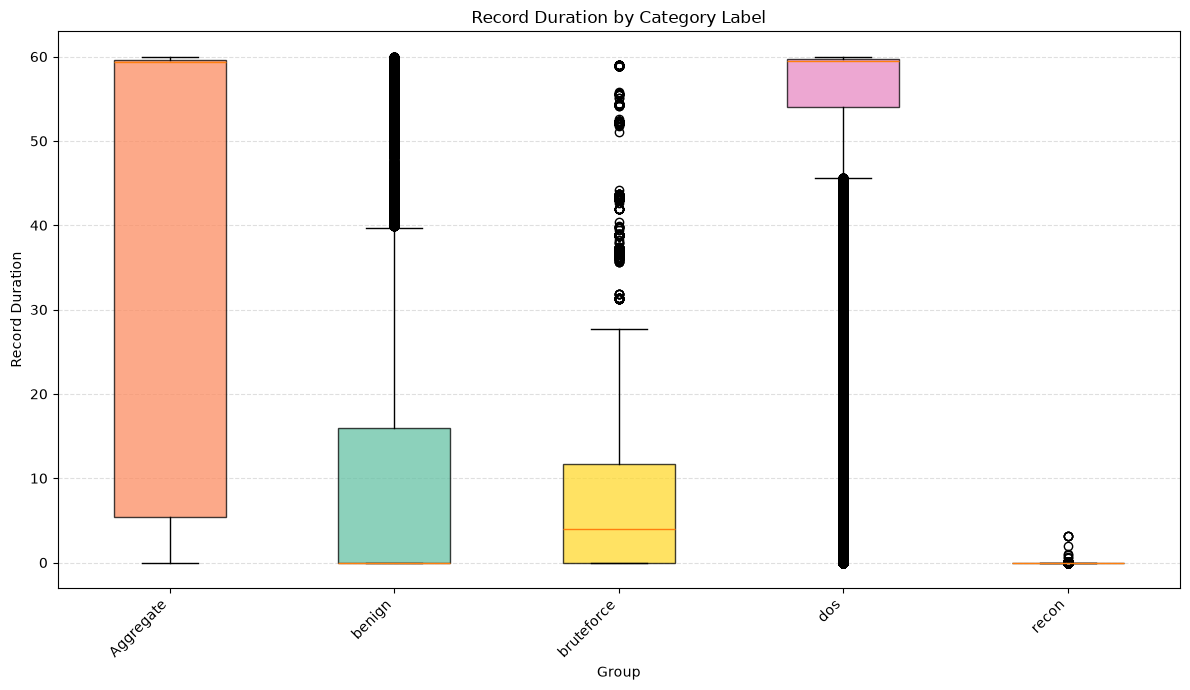

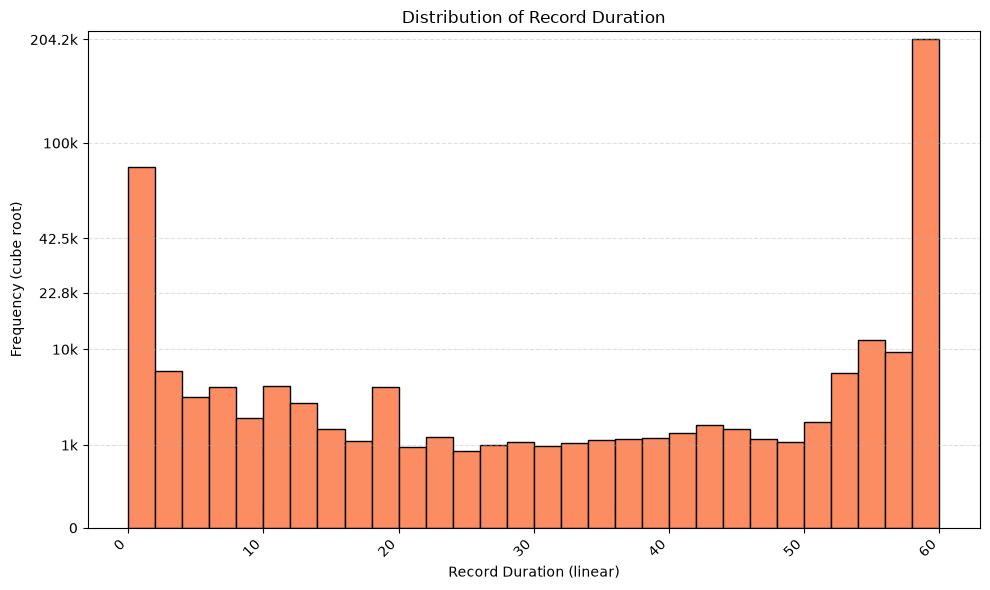

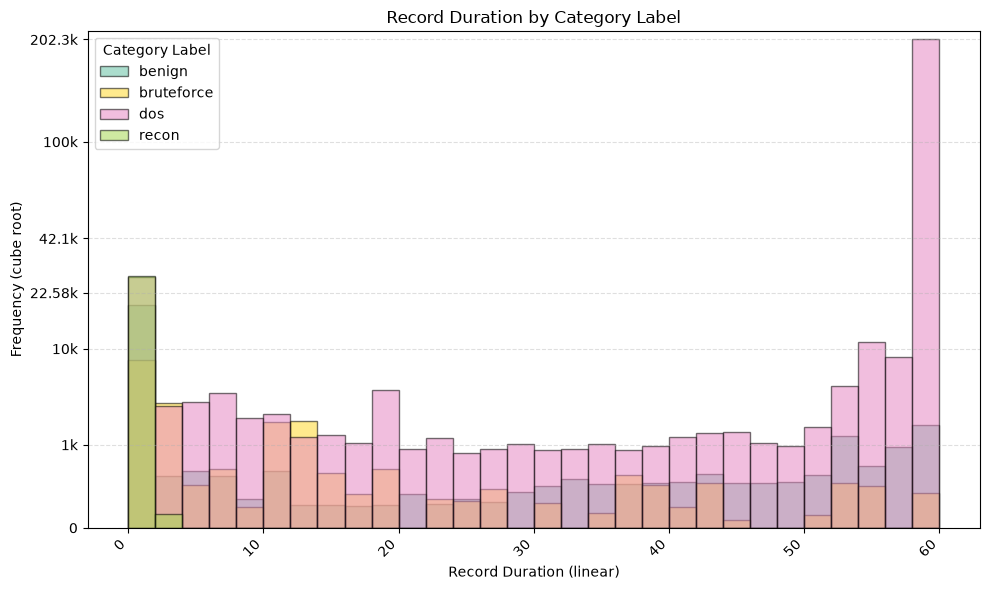

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("duration"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Load,load,numeric,predictor,Traffic load in bits per second.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 3.14424e+08]"
3,minimum,0.0
4,maximum,314423936.0
5,mean,149326.43414
6,standard_deviation,2455773.085263
7,percentile_05,0.0
8,percentile_25,244.912312
9,percentile_50,1242.695435


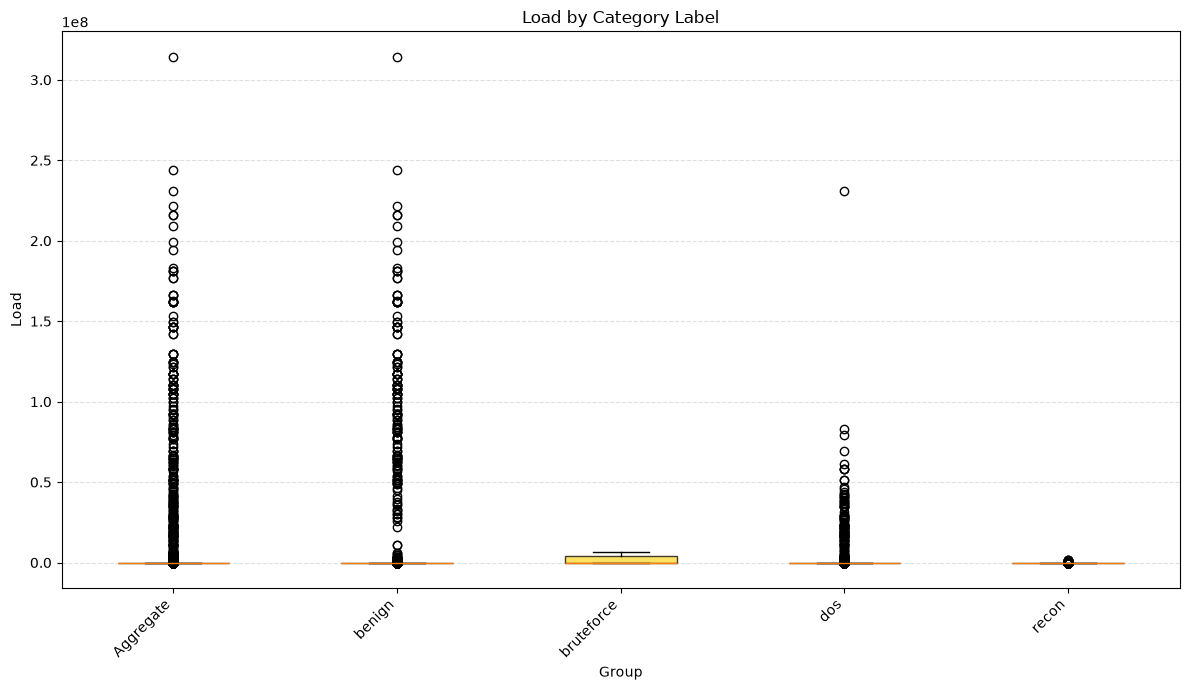

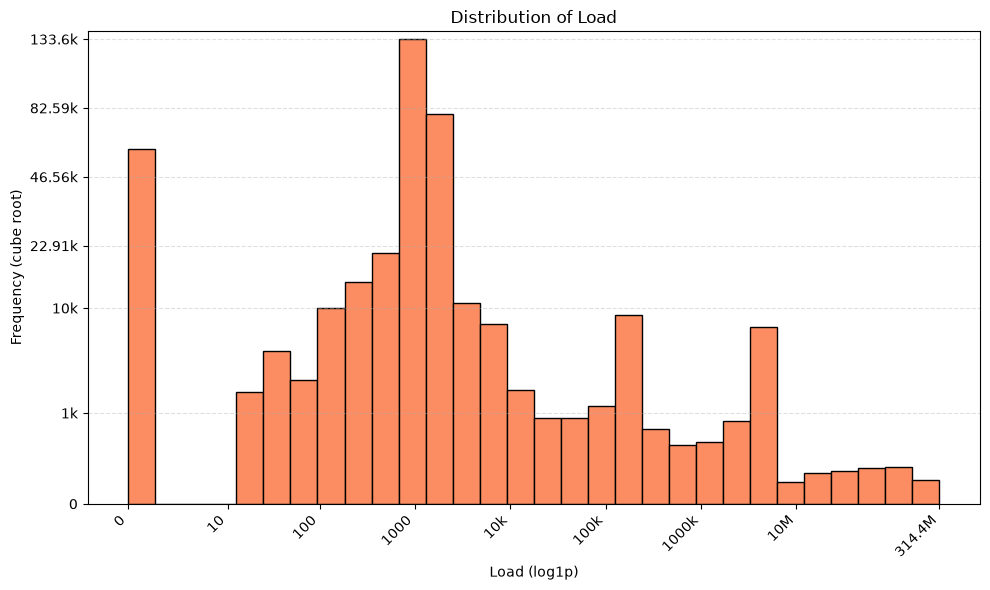

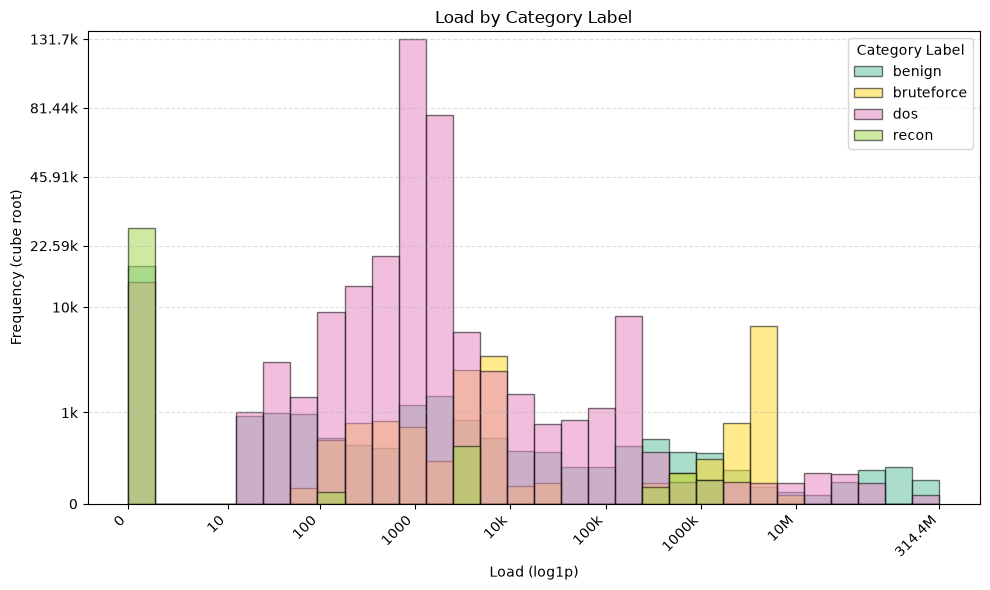

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("load"),
    numerical_axis_scale=NumericalAxisScale.LOG1P,
)

,name,label,semantic_type,role,description
0,Active Flow Runtime,run_time,numeric,predictor,"Total active flow runtime, equal to the sum of..."


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 59.9993]"
3,minimum,0.0
4,maximum,59.999279
5,mean,40.15565
6,standard_deviation,26.030945
7,percentile_05,0.0
8,percentile_25,5.415242
9,percentile_50,59.357697


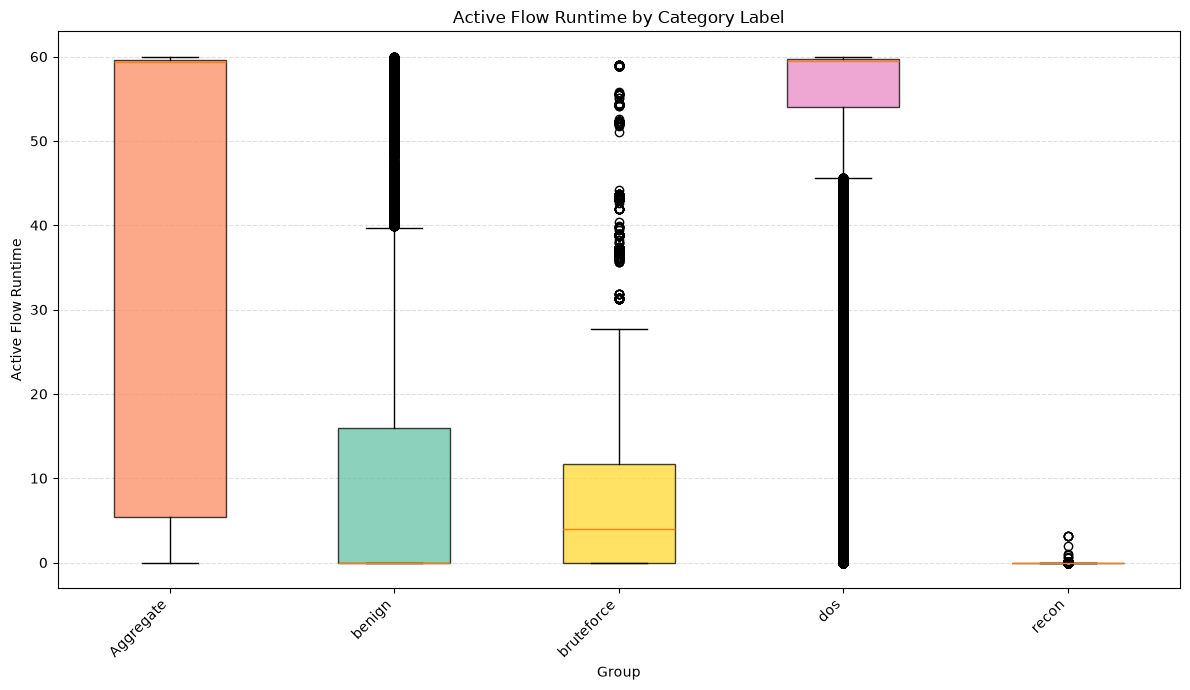

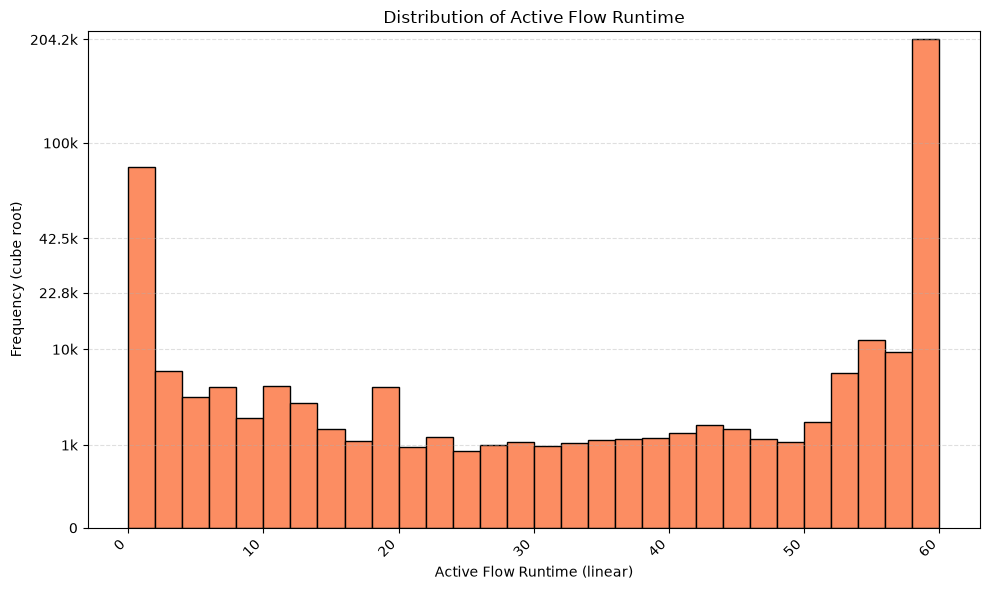

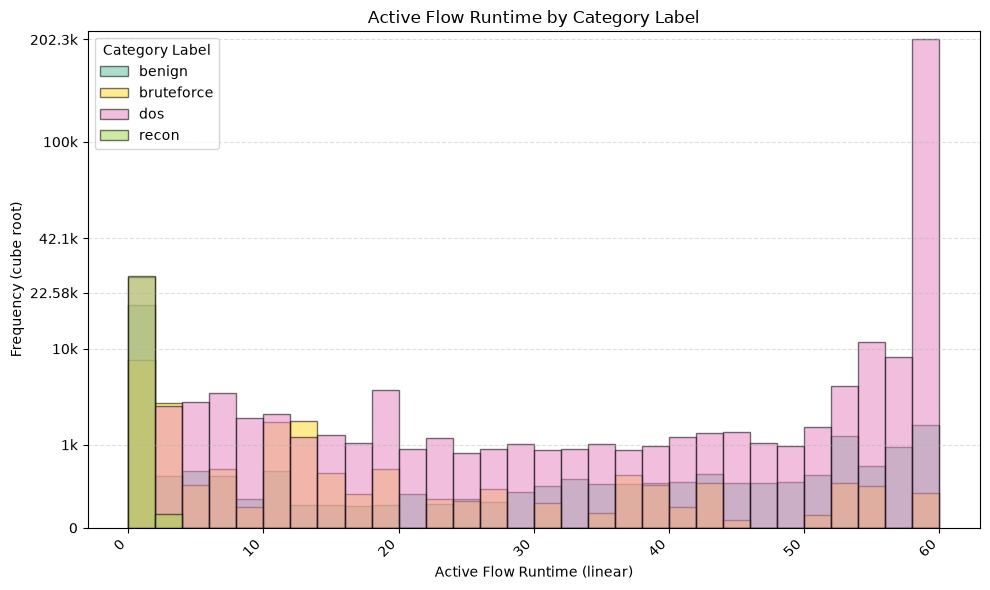

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("run_time"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Destination Active Jitter,destination_active_jitter,numeric,predictor,Destination active jitter in milliseconds.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 38560.1]"
3,minimum,0.0
4,maximum,38560.08
5,mean,113.852042
6,standard_deviation,399.164304
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


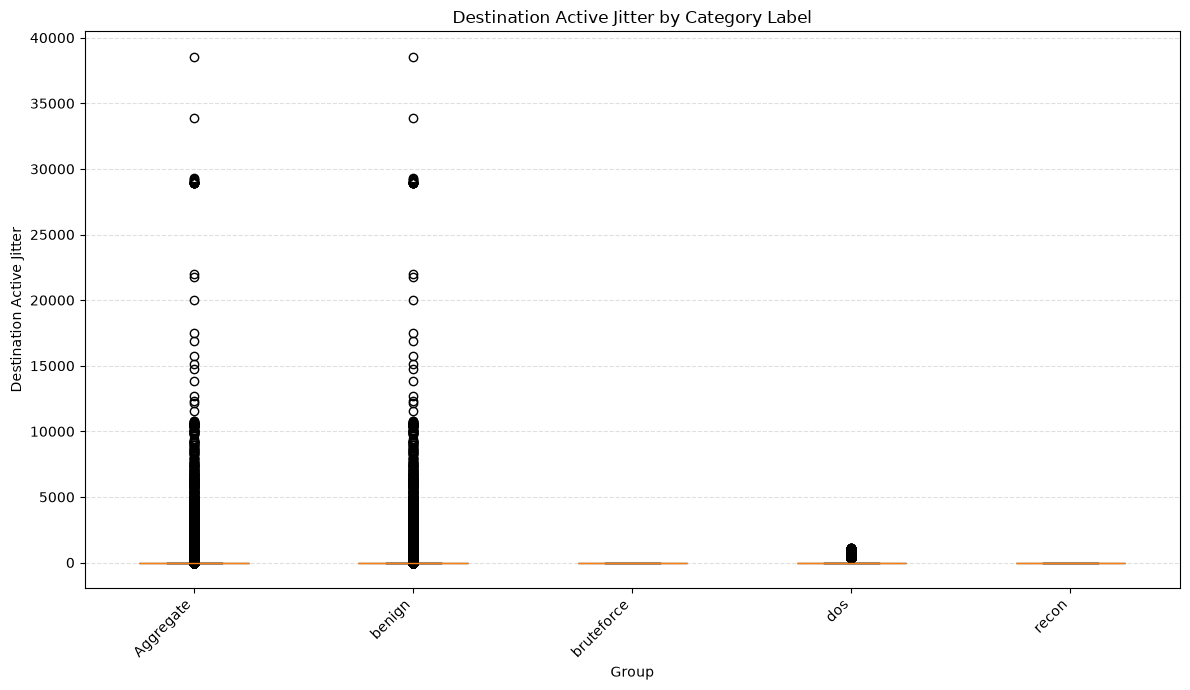

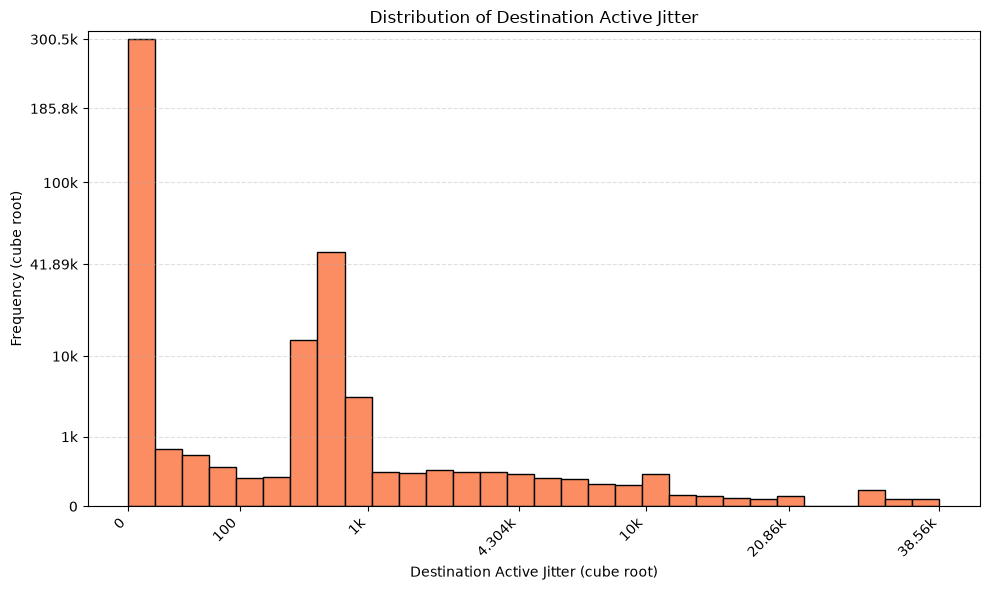

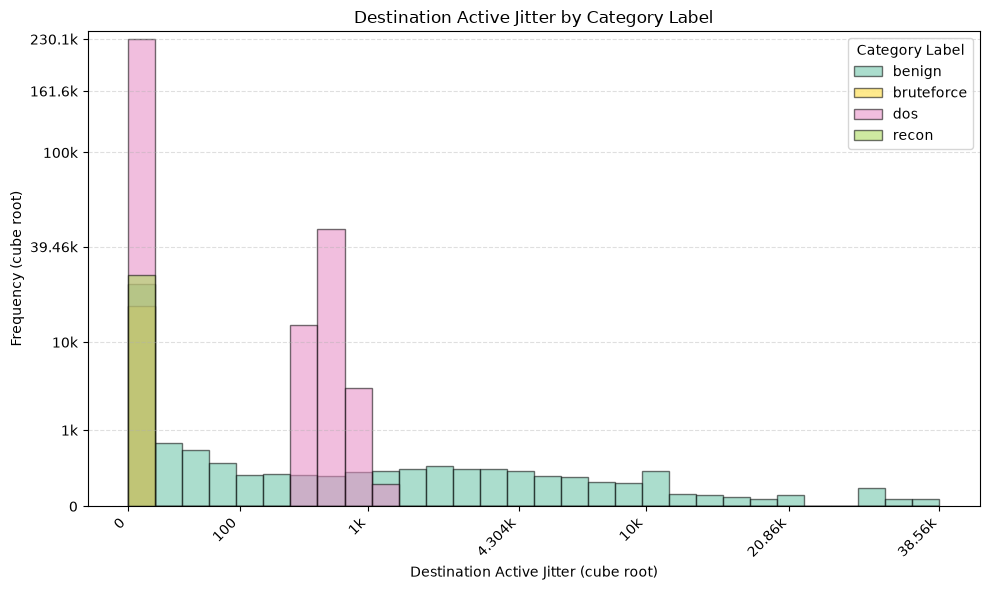

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("destination_active_jitter"),
)

,name,label,semantic_type,role,description
0,Idle Source Inter-Packet Time,source_interpacket_time_idle,numeric,predictor,Source idle inter-packet arrival time in milli...


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 113002]"
3,minimum,0.0
4,maximum,113001.592
5,mean,3443.76096
6,standard_deviation,11866.78343
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


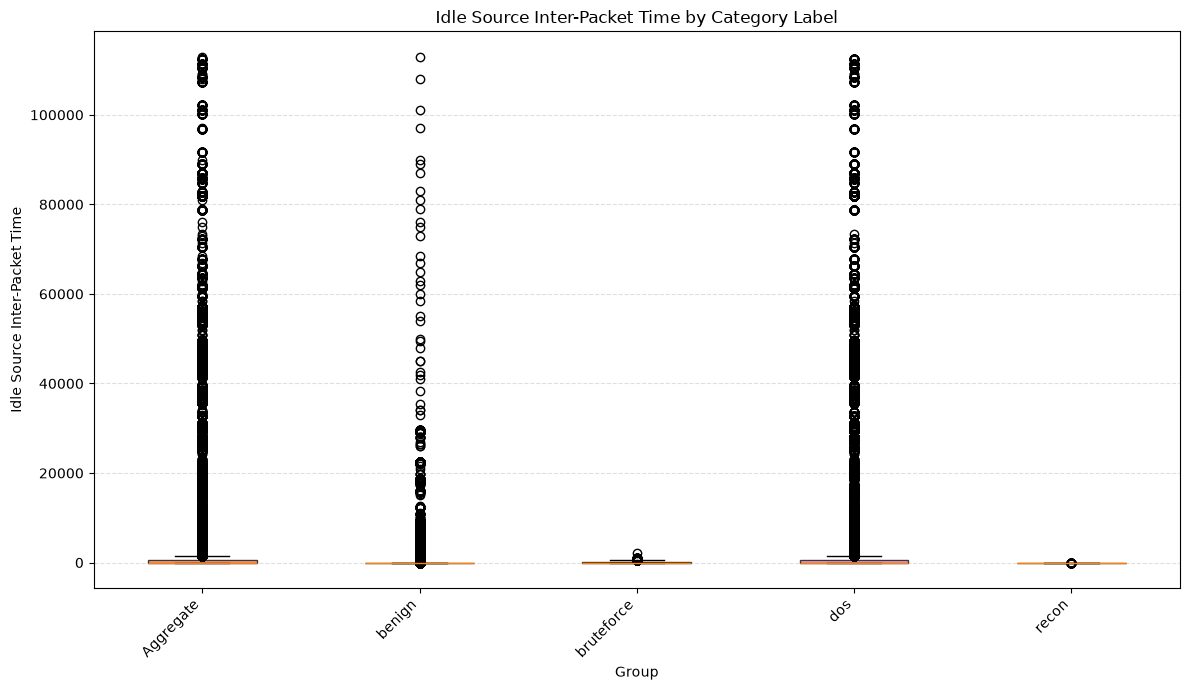

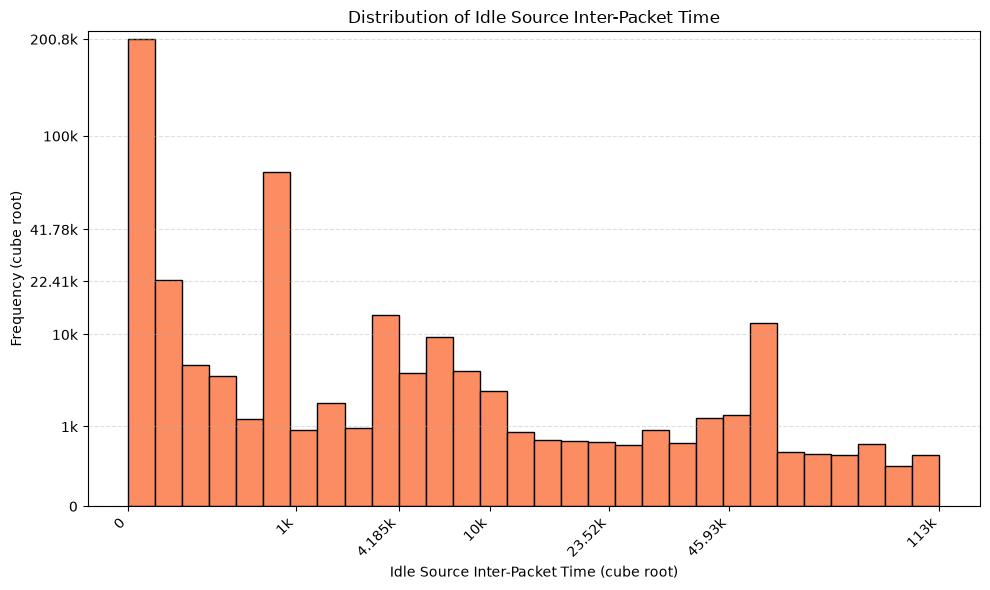

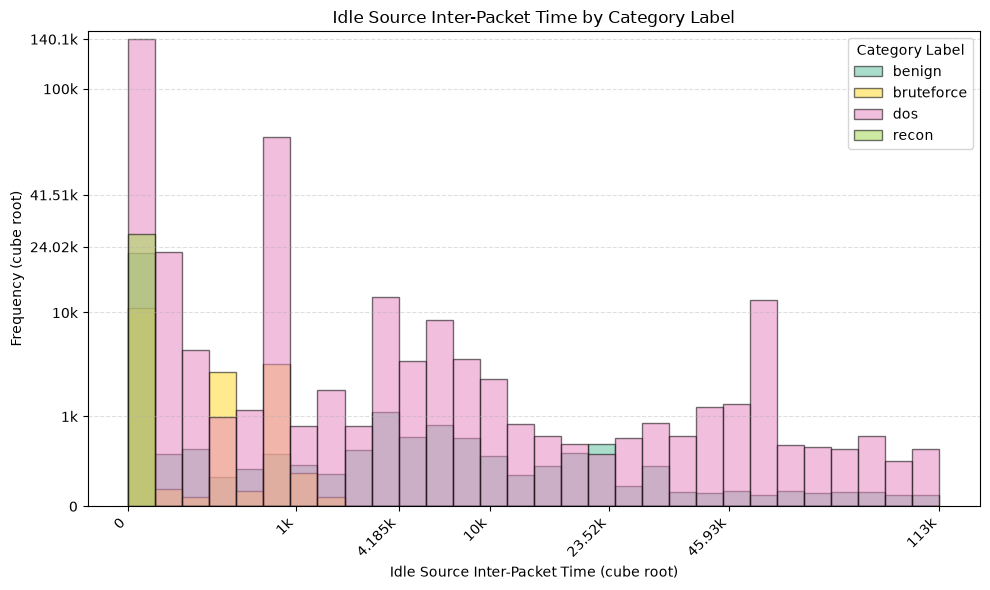

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("source_interpacket_time_idle")
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("amount_of_source_packets_loss"),
    numerical_axis_scale=NumericalAxisScale.LINEAR,
)

,name,label,semantic_type,role,description
0,Source Loss,amount_of_source_packets_loss,numeric,predictor,Source packets retransmitted or dropped.


,statistic,value
0,missing_values,0
1,infinite_values,0
2,range,"[0, 22]"
3,minimum,0.0
4,maximum,22.0
5,mean,0.755964
6,standard_deviation,2.515341
7,percentile_05,0.0
8,percentile_25,0.0
9,percentile_50,0.0


In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("protocol_arp"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("protocol_icmp"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("protocol_tcp"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("protocol_udp"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("flags_e"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("flags_e_star"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("flags_e_s"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("state_con"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("state_eco"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("state_fin"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("state_int"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("state_req"),
)

In [ ]:
display_genis_feature(
    TRANSFORMED_GENIS_SCHEMA.get_feature("state_rst"),
)